# Figure 3 — Where the combinatorial code came from

432 reconstructed ancestral receptors, each scored against the same 754 odorants as the
living ones. That turns a question about history into one that can be counted: what did the
ancestor bind, and what happened at each duplication after it?

The answer is that the code was not invented. One receptor cannot produce a combinatorial
code; two can, and immediately do. It appears at the first duplication — the class I /
class II split in the gnathostome ancestor — and is never lost.

**What is built here**

| Manuscript item | Part |
|---|---|
| Fig. 3b,c — the three founding repertoires | 1 |
| Extended Data Fig. 5a,b — repertoire sizes and turnover | 1, 2 |
| Fig. 3f — parent-child decay and functional half-life | 2 |
| Extended Data Fig. 5c,d — reconstruction-depth controls | 2 |
| Fig. 3d,e — gains, losses and chemistry along the earliest branches | 3 |
| Extended Data Fig. 6, Table 1 — the two founding duplications | 3 |
| Fig. 3g,h,i — the trajectory through time | 4 |

**Conventions**

All ancestral analysis uses the density fill with **no experimental overlay**, so ancestors
and tips are compared prediction against prediction. The ancestral cut lands at 0.8875 and
the extant one at 0.8947. `node_1` is the common ancestor, `node_2` class I, `node_3`
class II.

Repertoire sizes are relative. Read them node against node, never as absolute counts.

Needs the prediction matrices: `python scripts/download_zenodo_data.py`.

In [1]:
import warnings
warnings.filterwarnings("ignore")   # library deprecation notices only; keeps stored output clean
%config InlineBackend.figure_format = 'png'
import matplotlib as _mpl
_mpl.rcParams["figure.dpi"] = 100

---
# Part 1 — The three founding nodes

The common ancestor and the two class ancestors that descend from it. Of the 39 odorants
bound by at least one of the three, 19 end up retained by class I only, 6 by class II only,
2 by both and 12 by neither.

*Builds Fig. 3b,c and Extended Data Fig. 5b.*

# Ancestral node repertoires

Three reconstructed nodes: the common ancestor of the human OR repertoire and the
two class ancestors that descend from it.

Ligands are called by density fill (`../../scripts/calibration.py`), not by a chosen
cut; on the ASR matrix it falls at 0.8875. Repertoire sizes are relative — read them
node against node.

In [2]:
import sys
sys.path.append("../../scripts")
sys.path.append("../../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, odor_tags, \
                           decay_table, edge_table, node_topology, node_sets, \
                           save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, TEN_NODES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

anc = load_ancestral()
print(f"mode           : {anc.mode}")
print(f"ancestral cut  : median probability > {list(anc.per_node_cut.values())[0]:.2f}")
for node in anc.per_node_cut:
    print(f"  {node:<18} {int(anc.node_presence[node].sum())} ligands")
print(f"\nligands active in at least one node: {len(anc.all_smiles)}")

mode           : density
ancestral cut  : median probability > 0.89
  common_ancestor    21 ligands
  class1_ancestor    21 ligands
  class2_ancestor    8 ligands

ligands active in at least one node: 39


## Repertoire sizes and overlap

In [3]:
sizes = pd.DataFrame({
    "node": list(anc.per_node_cut),
    "probability_cut": [anc.per_node_cut[n] for n in anc.per_node_cut],
    "n_ligands": [int(anc.node_presence[n].sum()) for n in anc.per_node_cut],
})
print(sizes.to_string(index=False))

overlap = pd.Series({k: len(v) for k, v in anc.sets.items()})
print("\n" + overlap.to_string())
save_table(sizes, "01_node_sizes")

           node  probability_cut  n_ligands
common_ancestor         0.887473         21
class1_ancestor         0.887473         21
class2_ancestor         0.887473          8

common           21
class1           21
class2            8
shared_all        2
class1_gains     17
class2_gains      1
class1_losses    17
class2_losses    14


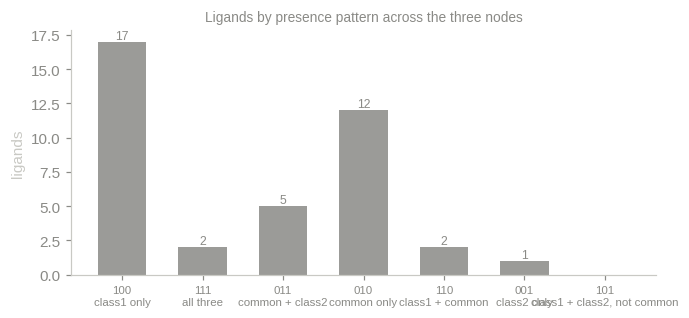

In [4]:
counts = [len(anc.pattern_sets[p]) for p in PATTERN_ORDER]

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.6, FIGSIZE[1]))
bars = ax.bar(range(len(PATTERN_ORDER)), counts, color="#8a8a86", alpha=0.85, width=0.6)
for i, (p, c) in enumerate(zip(PATTERN_ORDER, counts)):
    if c: ax.text(i, c, str(c), ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(PATTERN_ORDER)))
ax.set_xticklabels([f"{p}\n{PATTERN_LABELS[p]}" for p in PATTERN_ORDER], fontsize=7.5)
ax.set_ylabel("ligands")
ax.set_title("Ligands by presence pattern across the three nodes", fontsize=9)
plt.tight_layout(); save_fig(fig, "01_pattern_counts"); plt.show()

## Gains and losses along each edge

Relative to the common ancestor.

            edge  retained  lost  gained
common -> class1         4    17      17
common -> class2         7    14       1


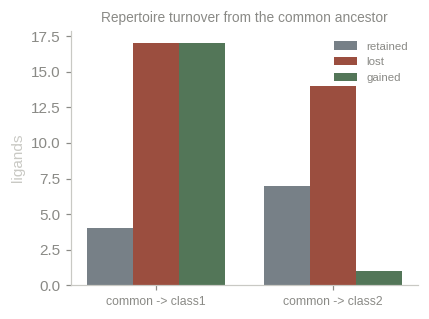


Repertoire sizes differ between nodes here, so gains and losses are free to
be asymmetric — unlike a rank call, which would force them to balance.


In [5]:
edges = pd.DataFrame({
    "edge": ["common -> class1", "common -> class2"],
    "retained": [len(anc.sets["common"] & anc.sets["class1"]),
                 len(anc.sets["common"] & anc.sets["class2"])],
    "lost":     [len(anc.sets["class1_losses"]), len(anc.sets["class2_losses"])],
    "gained":   [len(anc.sets["class1_gains"]),  len(anc.sets["class2_gains"])],
})
print(edges.to_string(index=False))
save_table(edges, "01_repertoire_turnover")

fig, ax = plt.subplots(figsize=FIGSIZE)
x = np.arange(2); w = 0.26
for i, (col, colr) in enumerate([("retained", "#5F6A72"), ("lost", "#8A2F1D"), ("gained", "#355E3B")]):
    ax.bar(x + (i - 1) * w, edges[col], w, label=col, color=colr, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(edges["edge"], fontsize=8)
ax.set_ylabel("ligands"); ax.legend(frameon=False, fontsize=7.5)
ax.set_title("Repertoire turnover from the common ancestor", fontsize=9)
plt.tight_layout(); save_fig(fig, "01_repertoire_turnover"); plt.show()

print("\nRepertoire sizes differ between nodes here, so gains and losses are free to")
print("be asymmetric — unlike a rank call, which would force them to balance.")

## Chemistry of each node's ligand set

In [6]:
chem = descriptors(anc.all_smiles).merge(functional_groups(anc.all_smiles), on="SMILES")
FG_COLS = list(FG_SMARTS)
chem.head()

,SMILES,logP,TPSA,MW,HBD,HBA,carboxylic_acid,alcohol,aldehyde,ketone,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene
0,C(CCCC(=O)O)CCCBr,2.8065,37.30,223.110,1,1,1,0,0,0,0,0,0,0,0,0,0,0
1,C(CCCCC(=O)O)CCCCBr,3.5867,37.30,251.164,1,1,1,0,0,0,0,0,0,0,0,0,0,0
2,C(CCCCCBr)CCCCC(=O)O,3.9768,37.30,265.191,1,1,1,0,0,0,0,0,0,0,0,0,0,0
3,C(CCCCCC(=O)O)CCCCCBr,4.3669,37.30,279.218,1,1,1,0,0,0,0,0,0,0,0,0,0,0
4,C/C=C/C(=O)C1=C(C=CCC1(C)C)C,3.4342,17.07,190.286,0,1,0,0,0,1,0,0,0,0,0,0,0,1


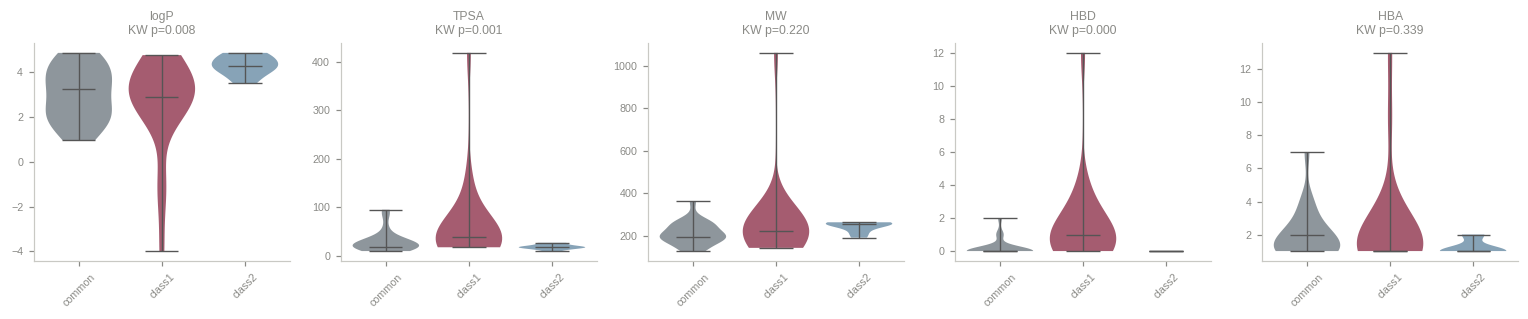

In [7]:
node_chem = []
for node in anc.per_node_cut:
    smi = set(anc.node_presence.loc[anc.node_presence[node] == 1, "SMILES"])
    sub = chem[chem.SMILES.isin(smi)]
    node_chem.append(sub.assign(node=node))
node_chem = pd.concat(node_chem)

fig, axes = plt.subplots(1, len(DESCRIPTORS), figsize=(FIGSIZE[0] * len(DESCRIPTORS) * 0.7, FIGSIZE[1]))
for ax, desc in zip(axes, DESCRIPTORS):
    data = [node_chem.loc[node_chem.node == n, desc].dropna().values for n in anc.per_node_cut]
    parts = ax.violinplot(data, showmedians=True, widths=0.8)
    for pc, n in zip(parts["bodies"], anc.per_node_cut):
        pc.set_facecolor(NODE_COL[n]); pc.set_alpha(0.7); pc.set_edgecolor("none")
    for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
        parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
    h, p = kruskal(*data)
    ax.set_title(f"{desc}\nKW p={p:.3f}", fontsize=8)
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(["common", "class1", "class2"], fontsize=7, rotation=45)
    ax.tick_params(labelsize=7)
plt.tight_layout(); save_fig(fig, "01_node_descriptors"); plt.show()

## Functional groups per node

The common ancestor is the baseline: it shows whether a group was inherited or acquired.

                 common  class1  class2  fisher_p_class1_vs_class2
carboxylic_acid    0.00   47.62     0.0                       0.03
alkene            57.14   33.33    25.0                       1.00
aromatic_ring     61.90   33.33    50.0                       0.43
ether             52.38   23.81    37.5                       0.65
phenol             4.76   14.29     0.0                       0.54
ketone            42.86   14.29    62.5                       0.02
alcohol            4.76   14.29     0.0                       0.54
amine              0.00   14.29     0.0                       0.54
aldehyde           4.76    9.52     0.0                       1.00
ester             28.57    9.52    25.0                       0.30
amide              4.76    4.76     0.0                       1.00
nitrile            0.00    0.00     0.0                       1.00


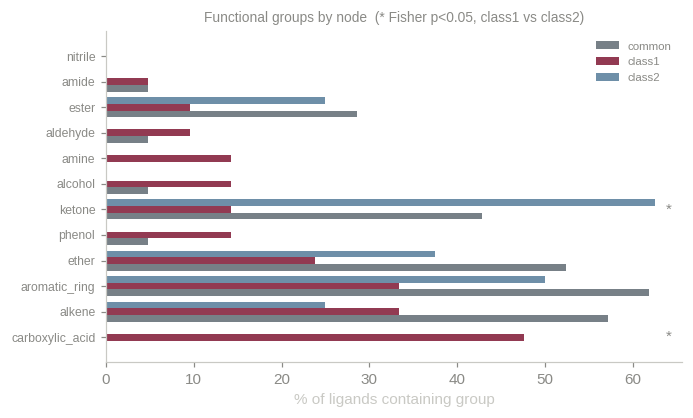

In [8]:
set_of = {"common": anc.sets["common"], "class1": anc.sets["class1"], "class2": anc.sets["class2"]}
prev = pd.DataFrame({g: chem[chem.SMILES.isin(v)][FG_COLS].mean() * 100 for g, v in set_of.items()})
pv = []
for fg in FG_COLS:
    a = chem[chem.SMILES.isin(set_of["class1"])][fg]
    b = chem[chem.SMILES.isin(set_of["class2"])][fg]
    pv.append(fisher_exact([[int(a.sum()), len(a) - int(a.sum())],
                            [int(b.sum()), len(b) - int(b.sum())]])[1])
prev["fisher_p_class1_vs_class2"] = pv
prev = prev.sort_values("class1", ascending=False)
print(prev.round(2).to_string())
save_table(prev.reset_index().rename(columns={"index": "functional_group"}),
           "01_functional_groups")

show = prev.drop(columns="fisher_p_class1_vs_class2")
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.6, FIGSIZE[1] * 1.3))
y = np.arange(len(show)); w = 0.26
for i, (g, c) in enumerate(zip(set_of, [COMMON_COL, CLASS1_COL, CLASS2_COL])):
    ax.barh(y + (i - 1) * w, show[g], w, color=c, alpha=0.85, label=g)
for yi, pval in zip(y, prev["fisher_p_class1_vs_class2"]):
    if pval < 0.05: ax.text(show.values.max() * 1.02, yi, "*", va="center", fontsize=10, color="#8a8a86")
ax.set_yticks(y); ax.set_yticklabels(show.index, fontsize=8)
ax.set_xlabel("% of ligands containing group"); ax.legend(frameon=False, fontsize=7.5)
ax.set_title("Functional groups by node  (* Fisher p<0.05, class1 vs class2)", fontsize=9)
plt.tight_layout(); save_fig(fig, "01_node_functional_groups"); plt.show()

## Odour descriptors per node

In [9]:
tags = odor_tags()
tag_map = dict(zip(tags.SMILES, tags.tags))

rows = []
for node in anc.per_node_cut:
    smi = set(anc.node_presence.loc[anc.node_presence[node] == 1, "SMILES"])
    flat = [t for s in smi for t in tag_map.get(s, [])]
    for t, c in pd.Series(flat).value_counts().head(8).items():
        rows.append({"node": node, "tag": t, "n": c})
top_tags = pd.DataFrame(rows)
wide = top_tags.pivot(index="tag", columns="node", values="n").fillna(0).astype(int)
print(wide.to_string())
save_table(wide.reset_index(), "01_top_odour_tags")

node     class1_ancestor  class2_ancestor  common_ancestor
tag                                                       
amber                  0                3                0
cheesy                 4                0                0
citrus                 3                0                0
dairy                  2                0                0
dry                    0                2                0
fatty                  4                0                0
floral                 2                2                9
fruity                 2                3                9
green                  0                0                3
musk                   0                4                4
powdery                0                2                0
rose                   0                0                4
spicy                  0                0                4
sweet                  4                6               17
waxy                   4                0               

---
## The same ligands, grouped by which nodes bind them

Each odorant carries a three-bit pattern over the common, class I and class II ancestors.
Grouping by that pattern asks whether the chemistry follows the split — and it does:
carboxylic acids go one way, aromatics the other.

# Activation-pattern contrasts

Each ligand carries a three-bit pattern over [class1, common, class2]. Grouping those
patterns gives the sets contrasted here:

- **class1 side** — `100` + `110`, bound by the class 1 ancestor but not class 2
- **class2 side** — `011`, bound by class 2 and the common ancestor but not class 1
- **shared** — `111`, bound by all three
- **common only** — `010`, held by the common ancestor and dropped by both

In [10]:
import sys
sys.path.append("../../scripts")
sys.path.append("../../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, \
                           decay_table, edge_table, node_topology, node_sets, \
                           save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, TEN_NODES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

anc = load_ancestral()
print(f"mode           : {anc.mode}")
print(f"ancestral cut  : median probability > {list(anc.per_node_cut.values())[0]:.2f}")
for node in anc.per_node_cut:
    print(f"  {node:<18} {int(anc.node_presence[node].sum())} ligands")
print(f"\nligands active in at least one node: {len(anc.all_smiles)}")

mode           : density
ancestral cut  : median probability > 0.89
  common_ancestor    21 ligands
  class1_ancestor    21 ligands
  class2_ancestor    8 ligands

ligands active in at least one node: 39


In [11]:
chem = descriptors(anc.all_smiles).merge(functional_groups(anc.all_smiles), on="SMILES")
FG_COLS = list(FG_SMARTS)
chem.head()

,SMILES,logP,TPSA,MW,HBD,HBA,carboxylic_acid,alcohol,aldehyde,ketone,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene
0,C(CCCC(=O)O)CCCBr,2.8065,37.30,223.110,1,1,1,0,0,0,0,0,0,0,0,0,0,0
1,C(CCCCC(=O)O)CCCCBr,3.5867,37.30,251.164,1,1,1,0,0,0,0,0,0,0,0,0,0,0
2,C(CCCCCBr)CCCCC(=O)O,3.9768,37.30,265.191,1,1,1,0,0,0,0,0,0,0,0,0,0,0
3,C(CCCCCC(=O)O)CCCCCBr,4.3669,37.30,279.218,1,1,1,0,0,0,0,0,0,0,0,0,0,0
4,C/C=C/C(=O)C1=C(C=CCC1(C)C)C,3.4342,17.07,190.286,0,1,0,0,0,1,0,0,0,0,0,0,0,1


## Group sizes

In [12]:
groups = {k: v for k, v in anc.code_sets.items()}
sizes = pd.Series({k: len(v) for k, v in groups.items()})
print(sizes.to_string())
save_table(sizes.rename("n_ligands").reset_index().rename(columns={"index": "group"}),
           "02_group_sizes")

class1_side    19
class2_side     6
shared          2
common_only    12


## The five presence patterns

Each ligand is a column; the three rows are the ancestral nodes. Columns are grouped by
pattern, and the strip above marks which group each column belongs to.

patterns kept for testing (n >= 5): {'100': 17, '011': 5, '010': 12}


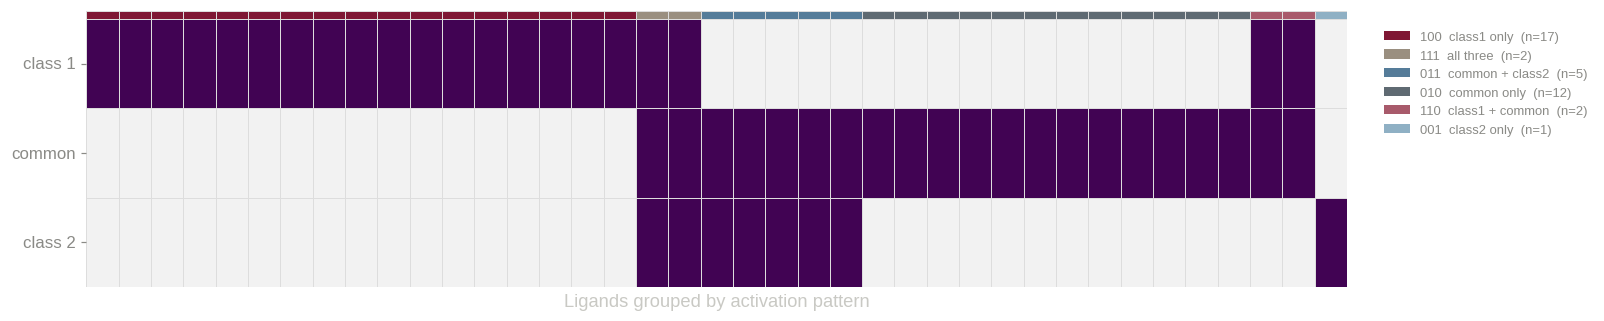

In [13]:
PAT_COL = {"100": CLASS1_COL, "110": "#a85a6b", "111": "#9a8f80",
           "010": COMMON_COL, "011": CLASS2_COL, "001": "#8fb0c4", "101": "#c9c9c4"}
KEEP = [p for p in PATTERN_ORDER if len(anc.pattern_sets[p]) >= 5]
print("patterns kept for testing (n >= 5):", {p: len(anc.pattern_sets[p]) for p in KEEP})

X = anc.node_presence.set_index("SMILES")[
    ["class1_ancestor", "common_ancestor", "class2_ancestor"]].T
X.index = ["class 1", "common", "class 2"]
X = X.loc[:, X.sum(axis=0) > 0]

patterns = X.apply(lambda col: "".join(col.astype(int).astype(str).values), axis=0).astype(str)
col_order = sorted(X.columns, key=lambda c: (PATTERN_ORDER.index(patterns.loc[c]), c))
Xo = X[col_order]
col_colors = patterns.loc[col_order].map(PAT_COL).tolist()
present = [p for p in PATTERN_ORDER if len(anc.pattern_sets[p])]

cg = sns.clustermap(
    Xo,
    row_cluster=False,
    col_cluster=False,
    cmap=ListedColormap(["#f2f2f2", "#410353"]),
    vmin=0, vmax=1,
    cbar_pos=None,
    xticklabels=False,
    yticklabels=True,
    col_colors=col_colors,
    linewidths=0.4, linecolor="#dddddd",
    figsize=(12, 3),
    dendrogram_ratio=(0.001, 0.001),
    colors_ratio=(0.03, 0.03),
)

ax = cg.ax_heatmap
ax.set_yticklabels(ax.get_ymajorticklabels(), rotation=0, fontsize=11)
ax.yaxis.tick_left()
ax.tick_params(axis="y", left=True, right=False, labelleft=True, labelright=False)
ax.set_xlabel("Ligands grouped by activation pattern", fontsize=12)
ax.set_ylabel("")
ax.legend(handles=[Patch(facecolor=PAT_COL[p],
                         label=f"{p}  {PATTERN_LABELS[p]}  (n={len(anc.pattern_sets[p])})")
                   for p in present],
          bbox_to_anchor=(1.02, 1.0), loc="upper left", frameon=False, fontsize=8.5)
save_fig(cg.figure, "02_pattern_heatmap")
save_table(anc.pattern_df, "02_ligand_patterns")
plt.show()

## class1 side versus class2 side

In [14]:
A = chem[chem.SMILES.isin(groups["class1_side"])]
B = chem[chem.SMILES.isin(groups["class2_side"])]

def cliffs(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    return float(np.sign(x[:, None] - y[None, :]).mean())

rows = []
for d in DESCRIPTORS:
    a, b = A[d].dropna(), B[d].dropna()
    p = mannwhitneyu(a, b).pvalue
    rows.append({"descriptor": d, "class1_side": round(a.median(), 2),
                 "class2_side": round(b.median(), 2),
                 "cliffs_delta": round(cliffs(a, b), 2), "p": p})
res = pd.DataFrame(rows)
print(res.to_string(index=False))
save_table(res, "02_side_descriptors")

descriptor  class1_side  class2_side  cliffs_delta        p
      logP         2.88         4.46         -0.82 0.003083
      TPSA        37.30        17.07          0.84 0.001889
        MW       223.11       258.40         -0.11 0.726118
       HBD         1.00         0.00          0.74 0.004613
       HBA         1.00         1.00          0.31 0.207175


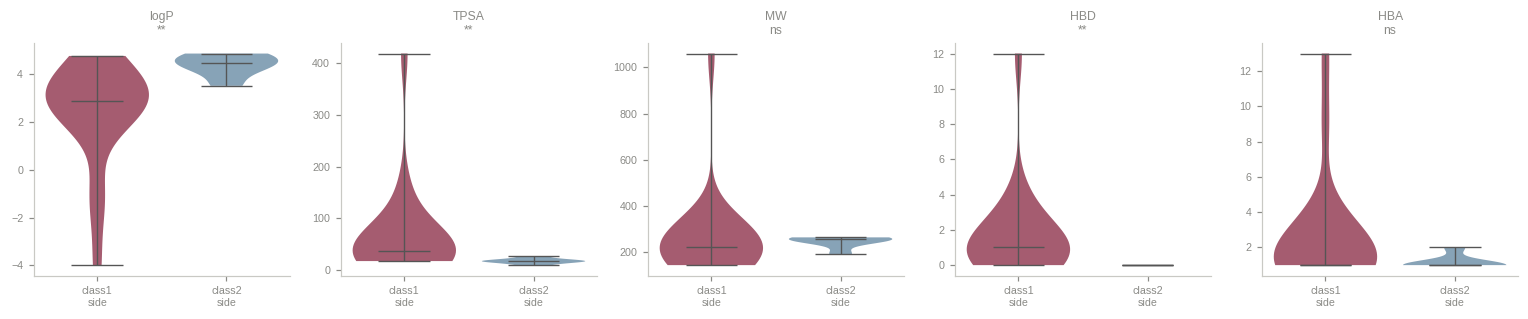

In [15]:
fig, axes = plt.subplots(1, len(DESCRIPTORS), figsize=(FIGSIZE[0] * len(DESCRIPTORS) * 0.7, FIGSIZE[1]))
for ax, d in zip(axes, DESCRIPTORS):
    data = [A[d].dropna().values, B[d].dropna().values]
    parts = ax.violinplot(data, showmedians=True, widths=0.8)
    for pc, c in zip(parts["bodies"], [CLASS1_COL, CLASS2_COL]):
        pc.set_facecolor(c); pc.set_alpha(0.7); pc.set_edgecolor("none")
    for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
        parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
    p = float(res.loc[res.descriptor == d, "p"].iloc[0])
    s = "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "ns"
    ax.set_title(f"{d}\n{s}", fontsize=8)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["class1\nside", "class2\nside"], fontsize=7)
    ax.tick_params(labelsize=7)
plt.tight_layout(); save_fig(fig, "02_side_descriptors"); plt.show()

## Functional groups in the two sides

          group  class1_side_%  class2_side_%        p
carboxylic_acid           52.6            0.0 0.050791
  aromatic_ring           36.8           66.7 0.350000
         alkene           31.6           16.7 0.637154
          ether           21.1           33.3 0.606053
         phenol           15.8            0.0 0.553913
          amine           15.8            0.0 0.553913
        alcohol           15.8            0.0 0.553913
       aldehyde           10.5            0.0 1.000000
         ketone           10.5           66.7 0.015133
          ester            5.3           16.7 0.430000
          amide            5.3            0.0 1.000000
        nitrile            0.0            0.0 1.000000


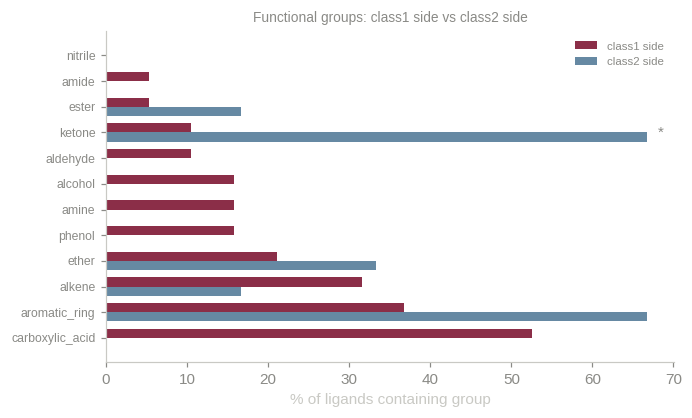

In [16]:
rows = []
for fg in FG_COLS:
    a, b = A[fg], B[fg]
    p = fisher_exact([[int(a.sum()), len(a) - int(a.sum())],
                      [int(b.sum()), len(b) - int(b.sum())]])[1]
    rows.append({"group": fg, "class1_side_%": round(100 * a.mean(), 1),
                 "class2_side_%": round(100 * b.mean(), 1), "p": p})
fg_res = pd.DataFrame(rows).sort_values("class1_side_%", ascending=False)
print(fg_res.to_string(index=False))
save_table(fg_res, "02_side_functional_groups")

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.6, FIGSIZE[1] * 1.3))
y = np.arange(len(fg_res)); w = 0.36
ax.barh(y + w / 2, fg_res["class1_side_%"], w, color=CLASS1_COL, alpha=0.9, label="class1 side")
ax.barh(y - w / 2, fg_res["class2_side_%"], w, color=CLASS2_COL, alpha=0.9, label="class2 side")
xm = max(fg_res["class1_side_%"].max(), fg_res["class2_side_%"].max())
for yi, p in zip(y, fg_res["p"]):
    if p < 0.05: ax.text(xm * 1.02, yi, "*", va="center", fontsize=10, color="#8a8a86")
ax.set_yticks(y); ax.set_yticklabels(fg_res["group"], fontsize=8)
ax.set_xlabel("% of ligands containing group"); ax.legend(frameon=False, fontsize=7.5)
ax.set_title("Functional groups: class1 side vs class2 side", fontsize=9)
plt.tight_layout(); save_fig(fig, "02_side_functional_groups"); plt.show()

## Chemistry across the patterns

Kruskal-Wallis across the patterns for the descriptors, then the functional groups that
differ most.

descriptor    H        p    100    011    010
      logP 11.1 0.003941   2.88   4.53   2.13
      TPSA 10.8 0.004405  37.30  17.07  26.30
        MW  2.6 0.273130 251.16 258.40 193.24
       HBD 13.3 0.001275   1.00   0.00   0.00
       HBA  5.1 0.077078   1.00   1.00   2.00


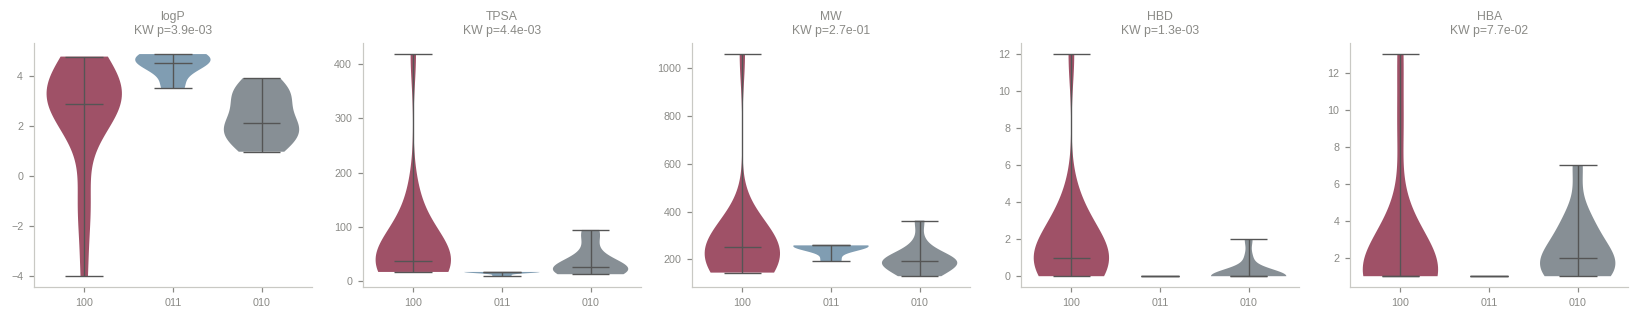

In [17]:
pat_chem = pd.concat([chem[chem.SMILES.isin(anc.pattern_sets[p])].assign(pattern=p)
                      for p in KEEP])

rows = []
for d in DESCRIPTORS:
    data = [pat_chem.loc[pat_chem.pattern == p, d].dropna().values for p in KEEP]
    h, pv = kruskal(*data)
    rows.append({"descriptor": d, "H": round(h, 1), "p": pv,
                 **{p: round(np.median(x), 2) for p, x in zip(KEEP, data)}})
print(pd.DataFrame(rows).to_string(index=False))
save_table(pd.DataFrame(rows), "02_pattern_descriptors")

fig, axes = plt.subplots(1, len(DESCRIPTORS), figsize=(FIGSIZE[0] * len(DESCRIPTORS) * 0.75, FIGSIZE[1]))
for ax, d in zip(axes, DESCRIPTORS):
    data = [pat_chem.loc[pat_chem.pattern == p, d].dropna().values for p in KEEP]
    parts = ax.violinplot(data, showmedians=True, widths=0.85)
    for pc, p in zip(parts["bodies"], KEEP):
        pc.set_facecolor(PAT_COL[p]); pc.set_alpha(0.75); pc.set_edgecolor("none")
    for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
        parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
    pv = float([r["p"] for r in rows if r["descriptor"] == d][0])
    ax.set_title(f"{d}\nKW p={pv:.1e}", fontsize=8)
    ax.set_xticks(range(1, len(KEEP) + 1)); ax.set_xticklabels(KEEP, fontsize=7)
    ax.tick_params(labelsize=7)
plt.tight_layout(); save_fig(fig, "02_pattern_descriptors"); plt.show()

                  100   011   010  spread
ketone           11.8  80.0  33.3    68.2
carboxylic_acid  58.8   0.0   0.0    58.8
aromatic_ring    29.4  80.0  58.3    50.6
alkene           23.5  20.0  66.7    46.7
ether            11.8  20.0  58.3    46.6
ester             0.0   0.0  33.3    33.3
amine            17.6   0.0   0.0    17.6
alcohol          17.6   0.0   8.3    17.6
aldehyde         11.8   0.0   8.3    11.8
phenol           11.8   0.0   0.0    11.8
amide             5.9   0.0   8.3     8.3
nitrile           0.0   0.0   0.0     0.0


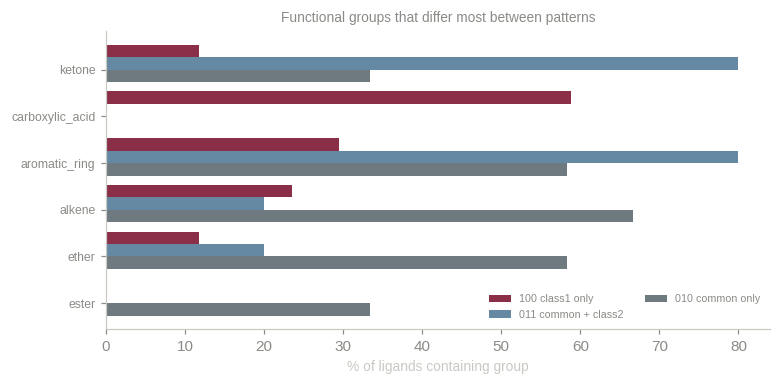

In [18]:
fg_pat = pd.DataFrame({p: chem[chem.SMILES.isin(anc.pattern_sets[p])][FG_COLS].mean() * 100
                       for p in KEEP})
fg_pat["spread"] = fg_pat.max(axis=1) - fg_pat.min(axis=1)
fg_pat = fg_pat.sort_values("spread", ascending=False)
print(fg_pat.round(1).to_string())
save_table(fg_pat.reset_index().rename(columns={"index": "functional_group"}),
           "02_pattern_functional_groups")

show = fg_pat.drop(columns="spread").head(6)
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.8, FIGSIZE[1] * 1.2))
y = np.arange(len(show)); w = 0.8 / len(KEEP)
for i, p in enumerate(KEEP):
    ax.barh(y + (i - len(KEEP) / 2) * w, show[p], w, color=PAT_COL[p], alpha=0.9,
            label=f"{p} {PATTERN_LABELS[p]}")
ax.set_yticks(y); ax.set_yticklabels(show.index, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("% of ligands containing group", fontsize=9)
ax.legend(frameon=False, fontsize=7, ncol=2)
ax.set_title("Functional groups that differ most between patterns", fontsize=9)
plt.tight_layout(); save_fig(fig, "02_pattern_functional_groups"); plt.show()

---
# Part 2 — How fast does a repertoire turn over?

Two questions. Does a reconstructed ancestor look artificially broad (it is modestly
broader — medians 7 against 4)? And how quickly do parent and child repertoires diverge?

*Builds Fig. 3f and Extended Data Fig. 5a,c,d.*

# Functional decay along the tree

Does a receptor's position in the phylogeny predict how many odorants it binds?

Every node — 432 reconstructed ancestors and 433 extant human receptors — is placed on
the rooted human tree, and its ligand count is plotted against its patristic distance
from the root. Ancestors and extant receptors share one axis, so a decay with depth
would show as a trend across both.

In [19]:
import sys
sys.path.append("../../scripts")
sys.path.append("../../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, odor_tags, \
                           decay_table, edge_table, node_topology, node_sets, \
                           save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, TEN_NODES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

anc = load_ancestral()
print(f"mode           : {anc.mode}")
print(f"ancestral cut  : median probability > {list(anc.per_node_cut.values())[0]:.2f}")
for node in anc.per_node_cut:
    print(f"  {node:<18} {int(anc.node_presence[node].sum())} ligands")
print(f"\nligands active in at least one node: {len(anc.all_smiles)}")

mode           : density
ancestral cut  : median probability > 0.89
  common_ancestor    21 ligands
  class1_ancestor    21 ligands
  class2_ancestor    8 ligands

ligands active in at least one node: 39


## Ligand count against distance from the root

In [20]:
decay = decay_table()          # None default = shared density fill
print(decay.groupby("kind").agg(n=("name", "size"),
                                median_ligands=("n_ligands", "median"),
                                median_distance=("distance", "median")).round(2).to_string())
save_table(decay, "03_ligands_vs_root_distance")

from scipy.stats import pearsonr, spearmanr
x, y = decay["distance"].to_numpy(), decay["n_ligands"].to_numpy()
r_p, p_p = pearsonr(x, y)
r_s, p_s = spearmanr(x, y)
print(f"\nall nodes   Pearson r = {r_p:+.3f}  p = {p_p:.3g}")
print(f"            Spearman r = {r_s:+.3f}  p = {p_s:.3g}")
for kind in ("ancestor", "extant"):
    sub = decay[decay.kind == kind]
    rp, pp = pearsonr(sub.distance, sub.n_ligands)
    print(f"{kind:<11} Pearson r = {rp:+.3f}  p = {pp:.3g}   (n={len(sub)})")

            n  median_ligands  median_distance
kind                                          
ancestor  432             7.0             3.68
extant    433             4.0             4.13

all nodes   Pearson r = +0.058  p = 0.0884
            Spearman r = -0.121  p = 0.000377
ancestor    Pearson r = +0.127  p = 0.00811   (n=432)
extant      Pearson r = -0.016  p = 0.743   (n=433)


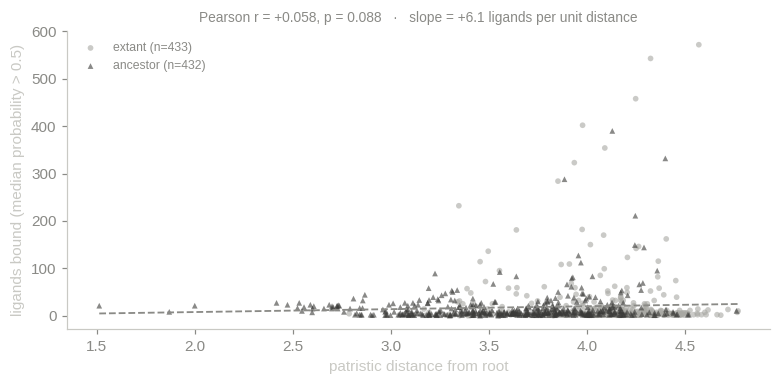

In [21]:
# Neutral greys, deliberately NOT the Class I/II palette: on these panels the split is
# ancestor vs extant, not receptor class, and reusing the class colours here read as a
# class contrast. The two groups are told apart by marker shape (triangle vs circle).
ANC_COL, EXT_COL = "#3a3a38", "#a8a8a3"

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.8, FIGSIZE[1] * 1.2))
for kind, colr, marker in [("extant", EXT_COL, "o"), ("ancestor", ANC_COL, "^")]:
    sub = decay[decay.kind == kind]
    ax.scatter(sub.distance, sub.n_ligands, s=14, alpha=0.6, color=colr,
               marker=marker, edgecolor="none", label=f"{kind} (n={len(sub)})")

slope, intercept = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, slope * xs + intercept, color="#8a8a86", lw=1.2, ls="--")
ax.set_xlabel("patristic distance from root")
ax.set_ylabel("ligands bound (median probability > 0.5)")
ax.set_title(f"Pearson r = {r_p:+.3f}, p = {p_p:.2g}   ·   slope = {slope:+.1f} ligands per unit distance",
             fontsize=9)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); save_fig(fig, "03_ligands_vs_root_distance"); plt.show()

## Repertoire size, ancestors against extant receptors

The same counts without the distance axis, since the two groups sit at different depths
by construction.

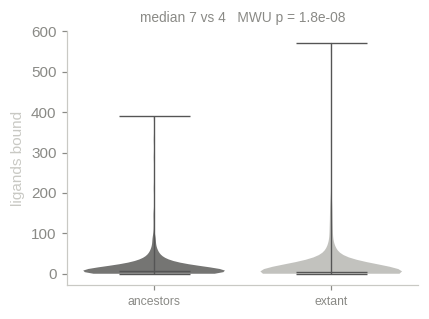

In [22]:
fig, ax = plt.subplots(figsize=FIGSIZE)
data = [decay.loc[decay.kind == k, "n_ligands"].values for k in ("ancestor", "extant")]
parts = ax.violinplot(data, showmedians=True, widths=0.8)
for pc, c in zip(parts["bodies"], [ANC_COL, EXT_COL]):
    pc.set_facecolor(c); pc.set_alpha(0.7); pc.set_edgecolor("none")
for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
    parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
u = mannwhitneyu(*data)
ax.set_xticks([1, 2]); ax.set_xticklabels(["ancestors", "extant"], fontsize=8)
ax.set_ylabel("ligands bound")
ax.set_title(f"median {np.median(data[0]):.0f} vs {np.median(data[1]):.0f}   MWU p = {u.pvalue:.2g}", fontsize=9)
plt.tight_layout(); save_fig(fig, "03_ancestor_vs_extant"); plt.show()

# Parent-child repertoire decay

How fast does binding function change along a branch?

Every parent-child edge of the human tree — 864 of them, joining ancestors to
ancestors and ancestors to extant receptors — is scored by how much of the parent's
ligand repertoire the child retains, against the branch length separating them.

In [23]:
import sys
sys.path.append("../../scripts")
sys.path.append("../../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, odor_tags, \
                           decay_table, edge_table, node_topology, node_sets, \
                           save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, TEN_NODES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

anc = load_ancestral()
print(f"mode           : {anc.mode}")
print(f"ancestral cut  : median probability > {list(anc.per_node_cut.values())[0]:.2f}")
for node in anc.per_node_cut:
    print(f"  {node:<18} {int(anc.node_presence[node].sum())} ligands")
print(f"\nligands active in at least one node: {len(anc.all_smiles)}")

mode           : density
ancestral cut  : median probability > 0.89
  common_ancestor    21 ligands
  class1_ancestor    21 ligands
  class2_ancestor    8 ligands

ligands active in at least one node: 39


## Edges

In [24]:
edges = edge_table()           # None default = shared density fill
print(f"{len(edges)} edges  " + str(edges.kind.value_counts().to_dict()))
print(edges[["similarity", "weighted", "retention", "gained", "lost", "branch_len"]]
      .describe().round(3).to_string())
save_table(edges, "04_edge_table")

861 edges  {'ancestor': 431, 'extant': 430}
       similarity  weighted  retention   gained     lost  branch_len
count     861.000   861.000    858.000  861.000  861.000     861.000
mean        0.487     0.580      0.655    9.447    7.620       0.237
std         0.295     0.221      0.326   37.424   21.122       0.228
min         0.000     0.045      0.000    0.000    0.000       0.000
25%         0.250     0.416      0.400    0.000    0.000       0.064
50%         0.500     0.612      0.722    1.000    2.000       0.150
75%         0.690     0.762      1.000    5.000    6.000       0.355
max         1.000     1.000      1.000  532.000  321.000       1.382


## Similarity against branch length

Binary Jaccard between parent and child repertoires, against the child's branch
length.

In [25]:
from scipy.stats import pearsonr, spearmanr

x, y = edges.branch_len.to_numpy(), edges.similarity.to_numpy()
r_p, p_p = pearsonr(x, y)
r_s, p_s = spearmanr(x, y)
print(f"Pearson  r = {r_p:+.3f}  p = {p_p:.2e}")
print(f"Spearman r = {r_s:+.3f}  p = {p_s:.2e}")

edges["tertile"] = pd.qcut(edges.branch_len, 3, labels=["short", "mid", "long"])
print("\n" + edges.groupby("tertile", observed=True)["similarity"]
      .agg(["size", "median"]).round(3).to_string())

Pearson  r = -0.404  p = 4.72e-35
Spearman r = -0.455  p = 3.64e-45

         size  median
tertile              
short     287   0.667
mid       287   0.500
long      287   0.281


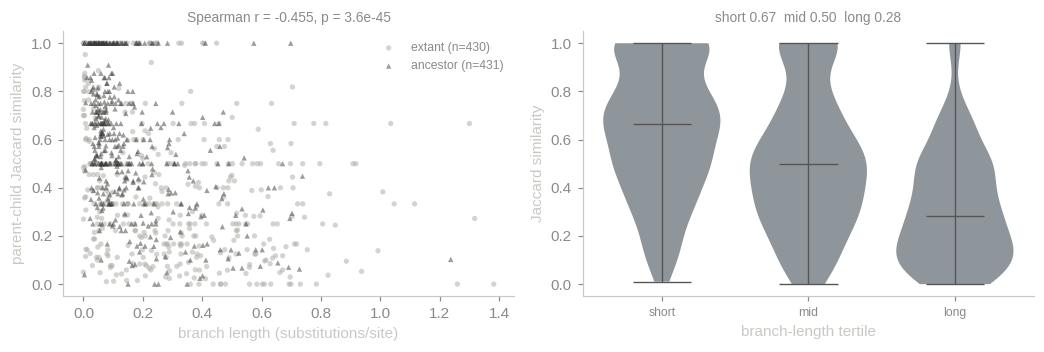

In [26]:
# Neutral greys, deliberately NOT the Class I/II palette: on these panels the split is
# ancestor vs extant, not receptor class, and reusing the class colours here read as a
# class contrast. The two groups are told apart by marker shape (triangle vs circle).
ANC_COL, EXT_COL = "#3a3a38", "#a8a8a3"

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.4, FIGSIZE[1] * 1.1))

ax = axes[0]
for kind, colr, mk in [("extant", EXT_COL, "o"), ("ancestor", ANC_COL, "^")]:
    sub = edges[edges.kind == kind]
    ax.scatter(sub.branch_len, sub.similarity, s=12, alpha=0.5, color=colr,
               marker=mk, edgecolor="none", label=f"{kind} (n={len(sub)})")
ax.set_xlabel("branch length (substitutions/site)")
ax.set_ylabel("parent-child Jaccard similarity")
ax.set_title(f"Spearman r = {r_s:+.3f}, p = {p_s:.1e}", fontsize=9)
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
data = [edges.loc[edges.tertile == t, "similarity"].values for t in ["short", "mid", "long"]]
parts = ax.violinplot(data, showmedians=True, widths=0.8)
for pc in parts["bodies"]:
    pc.set_facecolor("#5F6A72"); pc.set_alpha(0.7); pc.set_edgecolor("none")
for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
    parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(["short", "mid", "long"], fontsize=8)
ax.set_ylabel("Jaccard similarity"); ax.set_xlabel("branch-length tertile")
ax.set_title("  ".join(f"{t} {np.median(d):.2f}" for t, d in zip(["short","mid","long"], data)), fontsize=9)
plt.tight_layout(); save_fig(fig, "04_similarity_vs_branch"); plt.show()

## Exponential decay and functional half-life

Fitting `similarity = a·exp(-b·d) + c` gives the divergence at which half the
retainable overlap is gone.

a = 0.456 +/- 0.034
b = 4.283 +/- 0.927
c = 0.260 +/- 0.036   (asymptote)
R2 = 0.205   n edges = 861

functional half-life = 0.162 +/- 0.035 substitutions/site


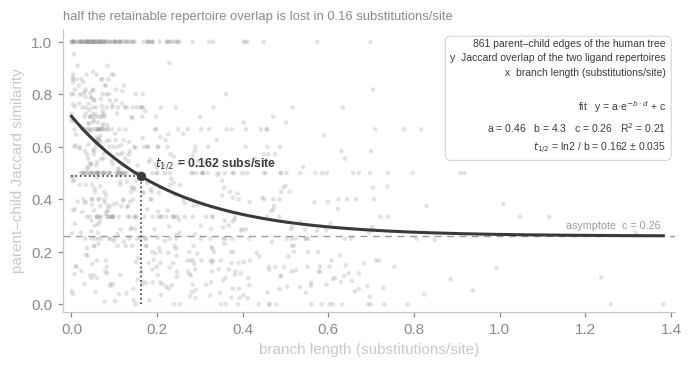

In [27]:
from scipy.optimize import curve_fit

def exp_decay(d, a, b, c):
    return a * np.exp(-b * d) + c

popt, pcov = curve_fit(exp_decay, x, y, p0=[0.5, 5.0, 0.3],
                       bounds=([0, 0, 0], [1.5, 1e3, 1.0]))
a, b, c = popt
err = np.sqrt(np.diag(pcov))
half_life = np.log(2) / b
half_err = np.log(2) * err[1] / b ** 2
resid = y - exp_decay(x, *popt)
r2 = 1 - resid.var() / y.var()

print(f"a = {a:.3f} +/- {err[0]:.3f}")
print(f"b = {b:.3f} +/- {err[1]:.3f}")
print(f"c = {c:.3f} +/- {err[2]:.3f}   (asymptote)")
print(f"R2 = {r2:.3f}   n edges = {len(x)}")
print(f"\nfunctional half-life = {half_life:.3f} +/- {half_err:.3f} substitutions/site")

# Deliberately monochrome. Crimson and blue are the Class I / Class II colours everywhere
# else in the figure, and nothing here is class-resolved -- every parent-child edge of the
# tree is pooled -- so using them would imply a split that this panel does not make.
INK, MID, PALE = "#3a3a38", "#9a9a95", "#cfcfc9"

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.6, FIGSIZE[1] * 1.15))
ax.scatter(x, y, s=9, alpha=0.28, color=MID, edgecolor="none", zorder=2)

xs = np.linspace(x.min(), x.max(), 300)
ax.plot(xs, exp_decay(xs, *popt), color=INK, lw=2.0, zorder=4)

# asymptote: the overlap that never decays away
ax.axhline(c, color=MID, ls=(0, (5, 4)), lw=0.9, zorder=3)
ax.annotate(f"asymptote  c = {c:.2f}", xy=(x.max(), c), xytext=(-2, 5),
            textcoords="offset points", fontsize=7, color=MID, ha="right")

# half-life: where half the decaying part of the overlap is gone
y_half = c + a / 2
ax.plot([half_life, half_life], [0, y_half], color=INK, ls=":", lw=1.1, zorder=3)
ax.plot([0, half_life], [y_half, y_half], color=INK, ls=":", lw=1.1, zorder=3)
ax.scatter([half_life], [y_half], s=26, color=INK, zorder=5)
ax.annotate(f"$t_{{1/2}}$ = {half_life:.3f} subs/site",
            xy=(half_life, y_half), xytext=(9, 7), textcoords="offset points",
            fontsize=8, color=INK, fontweight="bold")

info = (f"{len(x)} parent\u2013child edges of the human tree\n"
        f"y  Jaccard overlap of the two ligand repertoires\n"
        f"x  branch length (substitutions/site)\n\n"
        f"fit   y = a\u00b7e$^{{-b\cdot d}}$ + c\n"
        f"a = {a:.2f}   b = {b:.1f}   c = {c:.2f}   R$^2$ = {r2:.2f}\n"
        f"$t_{{1/2}}$ = ln2 / b = {half_life:.3f} \u00b1 {half_err:.3f}")
ax.text(0.985, 0.965, info, transform=ax.transAxes, ha="right", va="top",
        fontsize=6.8, color=INK, linespacing=1.55,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=PALE, linewidth=0.6))

ax.set_xlabel("branch length (substitutions/site)")
ax.set_ylabel("parent\u2013child Jaccard similarity")
ax.set_title("half the retainable repertoire overlap is lost in "
             f"{half_life:.2f} substitutions/site", fontsize=8.5, loc="left")
ax.set_ylim(-0.03, 1.05)
ax.set_xlim(-0.02, x.max() * 1.02)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); save_fig(fig, "04_functional_half_life"); plt.show()


## Is the binarisation driving this?

The cut is an output rather than a choice now, but these three checks still earn their place.

**Weighted Jaccard** runs on the raw probabilities and never binarises, so a ligand drifting
from 0.51 to 0.49 costs it almost nothing while it costs the binary version a whole ligand.

**Sweeping the cut** shows whether the answer depends on where the line falls.

**Splitting by child type** addresses the other story: that longer branches give worse
reconstructions and an apparent loss of overlap with no real change in function. The 433
extant children carry no reconstruction uncertainty at all.

In [28]:
rho, pv = spearmanr(edges.similarity, edges.weighted)
rw, pw = spearmanr(edges.branch_len, edges.weighted)
print(f"binary vs weighted Jaccard   Spearman r = {rho:+.3f}  p = {pv:.2e}")
print(f"weighted vs branch length    Spearman r = {rw:+.3f}  p = {pw:.2e}")

sweep = []
for t in [None, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.915]:   # None = the density fill actually used
    s = edge_table(threshold=t)
    fit, _ = curve_fit(exp_decay, s.branch_len, s.similarity, p0=[0.5, 5.0, 0.3],
                       bounds=([0, 0, 0], [1.5, 1e3, 1.0]))
    sweep.append({"cut": "density" if t is None else f"{t:.3f}", "edges": len(s),
                  "spearman": round(spearmanr(s.branch_len, s.similarity).statistic, 3),
                  "half_life": round(np.log(2) / fit[1], 3)})
sweep = pd.DataFrame(sweep)
print("\n" + sweep.to_string(index=False))
save_table(sweep, "04_threshold_sweep")

print()
for kind in ["extant", "ancestor"]:
    s = edges[edges.kind == kind]
    rb = spearmanr(s.branch_len, s.similarity)
    rww = spearmanr(s.branch_len, s.weighted)
    print(f"{kind:9s} n={len(s):3d}  binary r={rb.statistic:+.3f} p={rb.pvalue:.1e}"
          f"   weighted r={rww.statistic:+.3f} p={rww.pvalue:.1e}")

binary vs weighted Jaccard   Spearman r = +0.694  p = 8.77e-125
weighted vs branch length    Spearman r = -0.582  p = 3.43e-79



    cut  edges  spearman  half_life
density    861    -0.455      0.162
  0.300    864    -0.534      0.135
  0.400    864    -0.542      0.133
  0.500    864    -0.542      0.135
  0.600    864    -0.547      0.139
  0.700    864    -0.550      0.140
  0.800    864    -0.524      0.151
  0.915    806    -0.348      0.141

extant    n=430  binary r=-0.328 p=3.1e-12   weighted r=-0.452 p=5.4e-23
ancestor  n=431  binary r=-0.470 p=4.7e-25   weighted r=-0.605 p=2.4e-44


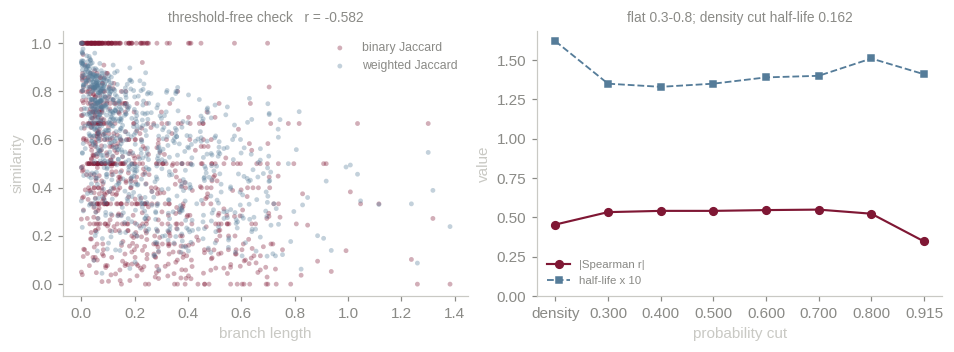

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1] * 1.1))

ax = axes[0]
ax.scatter(edges.branch_len, edges.similarity, s=10, alpha=0.35,
           color="#7f1734", edgecolor="none", label="binary Jaccard")
ax.scatter(edges.branch_len, edges.weighted, s=10, alpha=0.35,
           color="#557c99", edgecolor="none", label="weighted Jaccard")
ax.set_xlabel("branch length"); ax.set_ylabel("similarity")
ax.legend(frameon=False, fontsize=8)
ax.set_title(f"threshold-free check   r = {rw:+.3f}", fontsize=9)

ax = axes[1]
ax.plot(sweep.cut, -sweep.spearman, "o-", color="#7f1734", lw=1.4, ms=5, label="|Spearman r|")
ax.plot(sweep.cut, sweep.half_life * 10, "s--", color="#557c99", lw=1.2, ms=4,
        label="half-life x 10")
ax.set_xlabel("probability cut"); ax.set_ylabel("value")
ax.set_ylim(0, None); ax.legend(frameon=False, fontsize=7.5)
_d = sweep[sweep.cut == "density"].iloc[0]
ax.set_title(f"flat 0.3-0.8; density cut half-life {_d.half_life:.3f}", fontsize=9)
plt.tight_layout(); save_fig(fig, "04_threshold_check"); plt.show()

---
# Part 3 — The two founding duplications

`node_1 → node_2` and `node_3 → node_6`. For each, the *gain set* is what the child binds
that the parent did not, and the *shift vector* is the centroid of that gain set minus the
centroid of the parent's repertoire.

The two shifts are close to perpendicular in a standardised 13-descriptor chemical space —
97°, against a null median of 33°. The sections below work through the statistic, the null,
and four controls, and compare several ways of drawing it. **Panels D and E are the ones
published**, as Extended Data Fig. 6c and 6e.

*Builds Fig. 3d,e, Extended Data Fig. 6 and both blocks of Table 1.*

# Ten internal nodes along the human tree

`01`-`04` use three nodes. This one widens to ten reconstructed nodes that were picked
for a reason: after the class 1 / class 2 split, `node_6 -> 12 -> 21 -> 32 -> 44` is a
nested chain descending the class 2 trunk, so the repertoire can be followed step by
step down a single lineage rather than compared across a fork.

Same density fill as the rest of the folder. Only reconstructed nodes appear here;
extant receptors enter in `03` and `04`.

In [30]:
import sys
sys.path.append("../../scripts")
sys.path.append("../../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, \
                           decay_table, edge_table, node_topology, node_sets, \
                           asr_tree, density_grid, save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, \
                           TEN_NODES, CLASSES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

# ten CVD-safe categorical colours, fixed order
PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7",
       "#e34948", "#e87ba4", "#eb6834", "#0098c7", "#9c4d00"]
NCOL = {n: PAL[i] for i, n in enumerate(TEN_NODES)}
THRESH = None   # None = shared density fill; a number restores an absolute cut

topo = node_topology(TEN_NODES, threshold=THRESH)
sets = node_sets(TEN_NODES, threshold=THRESH)
print(topo.to_string(index=False))
save_table(topo, "05_topology")

 node  parent  depth  branch_len  n_leaves  frac_class_I OR_class  n_ligands  n_retained  n_gained  n_lost ancestors_in_set
    1  node_0      1    1.512110       433         0.143    mixed         21         NaN       NaN     NaN                 
    2  node_1      2    0.487478        62         1.000  Class_I         21         4.0      17.0    17.0                1
    3  node_1      2    0.357385       371         0.000 Class_II          8         7.0       1.0    14.0                1
    4  node_2      3    0.473190        55         1.000  Class_I         23        12.0      11.0     9.0              1;2
    5  node_2      3    0.737785         7         1.000  Class_I         21        13.0       8.0     8.0              1;2
    6  node_3      3    0.547405       370         0.000 Class_II         27         7.0      20.0     1.0              1;3
   12  node_6      4    0.129691       365         0.000 Class_II         10        10.0       0.0    17.0            1;3;6
   21 no

## Where the nodes sit

Depth from the root against repertoire size. The chain is drawn by joining each node to
its nearest ancestor that is also in the set.

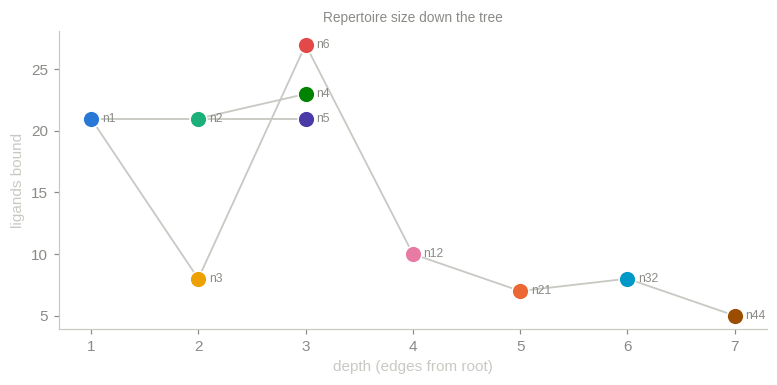

In [31]:
nearest = {}
for r in topo.itertuples():
    within = [int(a) for a in r.ancestors_in_set.split(";") if a]
    nearest[r.node] = max(within, key=lambda m: int(topo.loc[topo.node == m, "depth"].iloc[0])) \
                      if within else None

depth = dict(zip(topo.node, topo.depth))
nlig = dict(zip(topo.node, topo.n_ligands))

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.8, FIGSIZE[1] * 1.2))
for n, p in nearest.items():
    if p is not None:
        ax.plot([depth[p], depth[n]], [nlig[p], nlig[n]], color="#c9c9c4", lw=1.2, zorder=1)
for r in topo.itertuples():
    ax.scatter(r.depth, r.n_ligands, s=120, color=NCOL[r.node], zorder=3,
               edgecolor="white", lw=1.0)
    ax.annotate(f"n{r.node}", (r.depth, r.n_ligands), xytext=(7, 0),
                textcoords="offset points", va="center", fontsize=8)
ax.set_xlabel("depth (edges from root)"); ax.set_ylabel("ligands bound")
ax.set_title("Repertoire size down the tree", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_lineage"); plt.show()

## OR class of each node

Assigned from the classes of the descendant human leaves: >=90% class I is class I,
<=10% is class II, anything between is mixed.

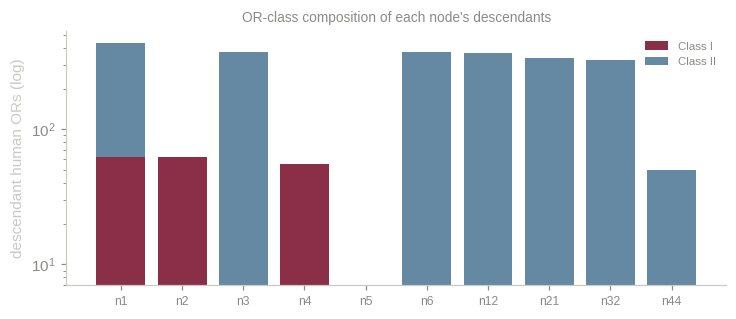

 node OR_class  n_leaves  frac_class_I  n_ligands
    1    mixed       433         0.143         21
    2  Class_I        62         1.000         21
    3 Class_II       371         0.000          8
    4  Class_I        55         1.000         23
    5  Class_I         7         1.000         21
    6 Class_II       370         0.000         27
   12 Class_II       365         0.000         10
   21 Class_II       337         0.000          7
   32 Class_II       328         0.000          8
   44 Class_II        50         0.000          5


In [32]:
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.7, FIGSIZE[1]))
x = np.arange(len(topo))
n_i = topo.frac_class_I * topo.n_leaves
n_ii = (1 - topo.frac_class_I) * topo.n_leaves
ax.bar(x, n_i, color=CLASS1_COL, label="Class I", alpha=0.9)
ax.bar(x, n_ii, bottom=n_i, color=CLASS2_COL, label="Class II", alpha=0.9)
ax.set_yscale("log"); ax.set_ylabel("descendant human ORs (log)")
ax.set_xticks(x); ax.set_xticklabels([f"n{n}" for n in topo.node], fontsize=8)
ax.legend(frameon=False, fontsize=7.5)
ax.set_title("OR-class composition of each node's descendants", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_node_or_class"); plt.show()

print(topo[["node", "OR_class", "n_leaves", "frac_class_I", "n_ligands"]].to_string(index=False))

## Overlap between the ten repertoires

union of the ten: 61 ligands
bound by all ten: 1 ligands


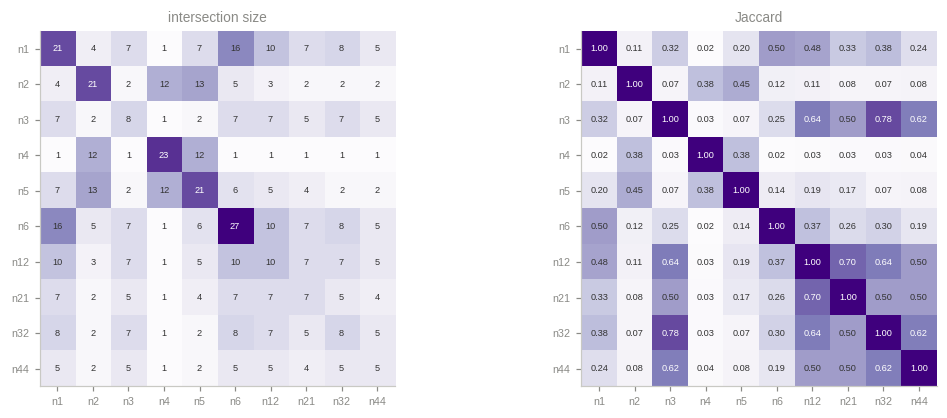

In [33]:
J = pd.DataFrame(index=TEN_NODES, columns=TEN_NODES, dtype=float)
I = pd.DataFrame(index=TEN_NODES, columns=TEN_NODES, dtype=int)
for a in TEN_NODES:
    for b in TEN_NODES:
        inter = len(sets[a] & sets[b]); union = len(sets[a] | sets[b])
        I.loc[a, b] = inter
        J.loc[a, b] = inter / union if union else 0.0
save_table(J.round(4).reset_index().rename(columns={"index": "node"}), "05_pairwise_jaccard")

union_all = set().union(*sets.values())
print(f"union of the ten: {len(union_all)} ligands")
print(f"bound by all ten: {len(set.intersection(*sets.values()))} ligands")

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.6, FIGSIZE[1] * 1.3))
for ax, M, title, fmt in [(axes[0], I.astype(float), "intersection size", ".0f"),
                          (axes[1], J.astype(float), "Jaccard", ".2f")]:
    im = ax.imshow(M.values, cmap="Purples")
    ax.set_xticks(range(len(TEN_NODES))); ax.set_yticks(range(len(TEN_NODES)))
    ax.set_xticklabels([f"n{n}" for n in TEN_NODES], fontsize=7)
    ax.set_yticklabels([f"n{n}" for n in TEN_NODES], fontsize=7)
    cut = M.values.max() * 0.6
    for i in range(len(TEN_NODES)):
        for j in range(len(TEN_NODES)):
            ax.text(j, i, format(M.values[i, j], fmt), ha="center", va="center",
                    fontsize=6, color="white" if M.values[i, j] > cut else "#333")
    ax.set_title(title, fontsize=9)
plt.tight_layout(); save_fig(fig, "05_pairwise_overlap"); plt.show()

## Intersection structure

Which combinations of nodes share a ligand. Because the nodes are nested, most ligands
fall into a small number of patterns.

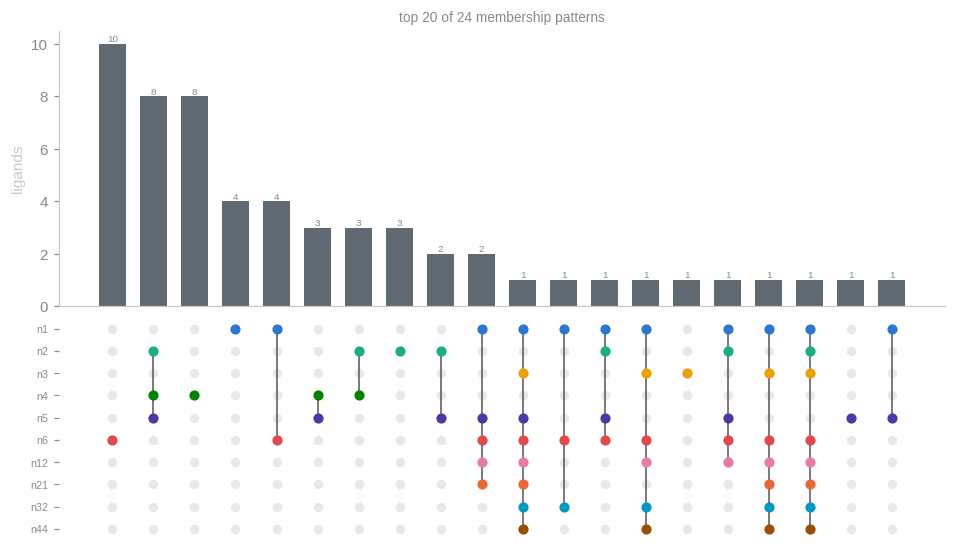

In [34]:
member = {s: tuple(s in sets[n] for n in TEN_NODES) for s in union_all}
counts = pd.Series(list(member.values())).value_counts()
top = counts.head(20)

fig = plt.figure(figsize=(FIGSIZE[0] * 2.6, FIGSIZE[1] * 2.0))
gs = fig.add_gridspec(2, 1, height_ratios=[2.0, 1.6], hspace=0.05)
axb = fig.add_subplot(gs[0]); axm = fig.add_subplot(gs[1], sharex=axb)

xs = np.arange(len(top))
axb.bar(xs, top.values, color="#5F6A72", width=0.65)
for xi, v in zip(xs, top.values):
    axb.text(xi, v, str(v), ha="center", va="bottom", fontsize=6.5)
axb.set_ylabel("ligands"); axb.tick_params(labelbottom=False)

for yi, n in enumerate(TEN_NODES):
    axm.scatter(xs, [yi] * len(xs), s=26, color="#e8e8e6", zorder=1)
    on = [xi for xi, m in zip(xs, top.index) if m[yi]]
    axm.scatter(on, [yi] * len(on), s=32, color=NCOL[n], zorder=3)
for xi, m in zip(xs, top.index):
    idx = [yi for yi in range(len(TEN_NODES)) if m[yi]]
    if len(idx) > 1:
        axm.plot([xi, xi], [min(idx), max(idx)], color="#555", lw=1.0, zorder=2)
axm.set_yticks(range(len(TEN_NODES)))
axm.set_yticklabels([f"n{n}" for n in TEN_NODES], fontsize=7)
axm.set_xticks([]); axm.invert_yaxis()
for sp in ["top", "right", "bottom", "left"]: axm.spines[sp].set_visible(False)
axb.set_title(f"top {len(top)} of {len(counts)} membership patterns", fontsize=9)
save_fig(fig, "05_upset"); plt.show()

## Gains and losses against the immediate parent

The parent comes from the full ASR matrix, so it need not itself be one of the ten.

 node  parent  n_ligands  n_retained  n_gained  n_lost
    2  node_1         21         4.0      17.0    17.0
    3  node_1          8         7.0       1.0    14.0
    4  node_2         23        12.0      11.0     9.0
    5  node_2         21        13.0       8.0     8.0
    6  node_3         27         7.0      20.0     1.0
   12  node_6         10        10.0       0.0    17.0
   21 node_12          7         7.0       0.0     3.0
   32 node_21          8         5.0       3.0     2.0
   44 node_32          5         5.0       0.0     3.0


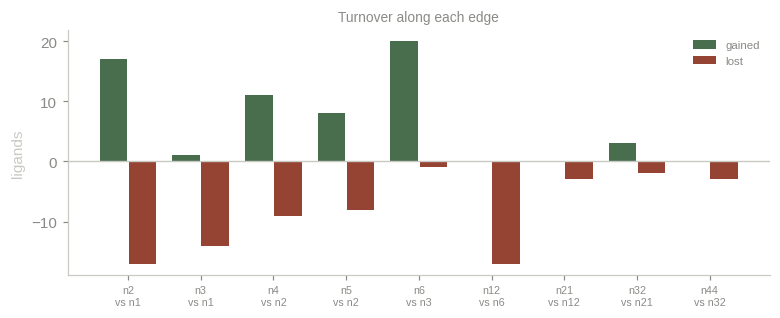

In [35]:
gl = topo.dropna(subset=["n_gained"])
print(gl[["node", "parent", "n_ligands", "n_retained", "n_gained", "n_lost"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.8, FIGSIZE[1]))
x = np.arange(len(gl))
ax.bar(x - 0.2, gl.n_gained, 0.38, color="#355E3B", label="gained", alpha=0.9)
ax.bar(x + 0.2, -gl.n_lost, 0.38, color="#8A2F1D", label="lost", alpha=0.9)
ax.axhline(0, color="#c9c9c4", lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels([f"n{r.node}\nvs {r.parent.replace('node_', 'n')}" for r in gl.itertuples()],
                   fontsize=7)
ax.set_ylabel("ligands"); ax.legend(frameon=False, fontsize=7.5)
ax.set_title("Turnover along each edge", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_gain_loss"); plt.show()

## Chemistry of each node's repertoire

Descriptors first, then functional-group prevalence as a heatmap across all ten.

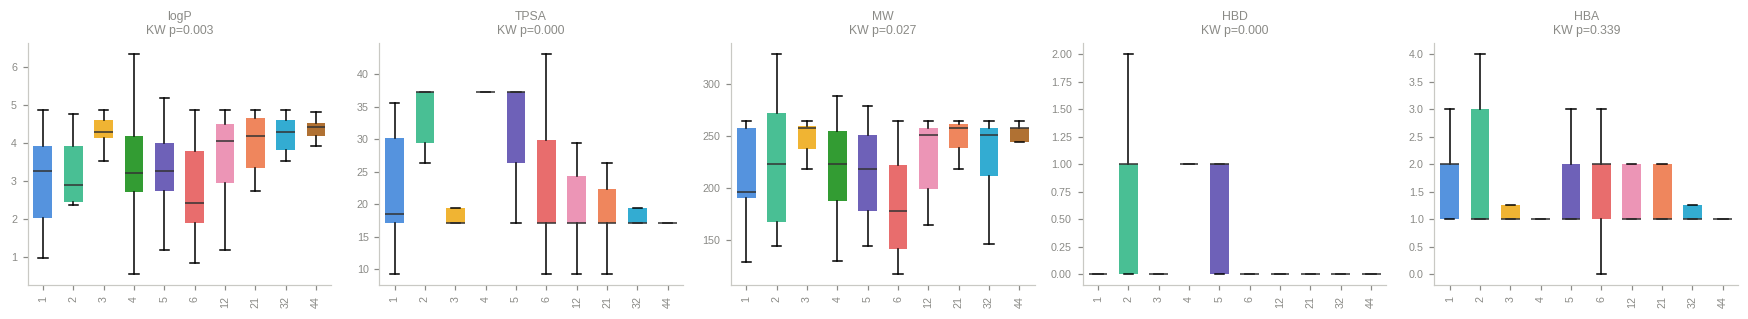

In [36]:
chem = descriptors(sorted(union_all)).merge(functional_groups(sorted(union_all)), on="SMILES")
FG_COLS = list(FG_SMARTS)

fig, axes = plt.subplots(1, len(DESCRIPTORS),
                         figsize=(FIGSIZE[0] * len(DESCRIPTORS) * 0.8, FIGSIZE[1]))
for ax, d in zip(axes, DESCRIPTORS):
    data = [chem[chem.SMILES.isin(sets[n])][d].dropna().values for n in TEN_NODES]
    bp = ax.boxplot(data, widths=0.62, patch_artist=True, showfliers=False,
                    medianprops=dict(color="#333"))
    for patch, n in zip(bp["boxes"], TEN_NODES):
        patch.set_facecolor(NCOL[n]); patch.set_alpha(0.8); patch.set_edgecolor("none")
    h, p = kruskal(*data)
    ax.set_title(f"{d}\nKW p={p:.3f}", fontsize=8)
    ax.set_xticks(range(1, len(TEN_NODES) + 1))
    ax.set_xticklabels([str(n) for n in TEN_NODES], fontsize=6, rotation=90)
    ax.tick_params(labelsize=7)
plt.tight_layout(); save_fig(fig, "05_node_descriptors"); plt.show()

                   1     2     3     4     5     6     12    21    32    44
carboxylic_acid   0.0  47.6   0.0  82.6  57.1   0.0   0.0   0.0   0.0   0.0
alcohol           4.8  14.3   0.0   4.3  14.3   3.7  10.0  14.3   0.0   0.0
aldehyde          4.8   9.5   0.0   4.3   4.8   3.7   0.0   0.0   0.0   0.0
ketone           42.9  14.3  62.5   8.7   4.8  37.0  50.0  42.9  62.5  60.0
ester            28.6   9.5  25.0   0.0  14.3  18.5  20.0  28.6  12.5  20.0
ether            52.4  23.8  37.5   4.3  28.6  37.0  50.0  57.1  25.0  40.0
amine             0.0  14.3   0.0   4.3   4.8   7.4   0.0   0.0   0.0   0.0
amide             4.8   4.8   0.0   4.3   4.8   0.0   0.0   0.0   0.0   0.0
aromatic_ring    61.9  33.3  50.0   8.7  23.8  70.4  60.0  57.1  62.5  60.0
phenol            4.8  14.3   0.0   8.7   4.8   3.7  10.0   0.0   0.0   0.0
nitrile           0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
alkene           57.1  33.3  25.0  13.0  38.1  33.3  50.0  42.9  25.0  20.0


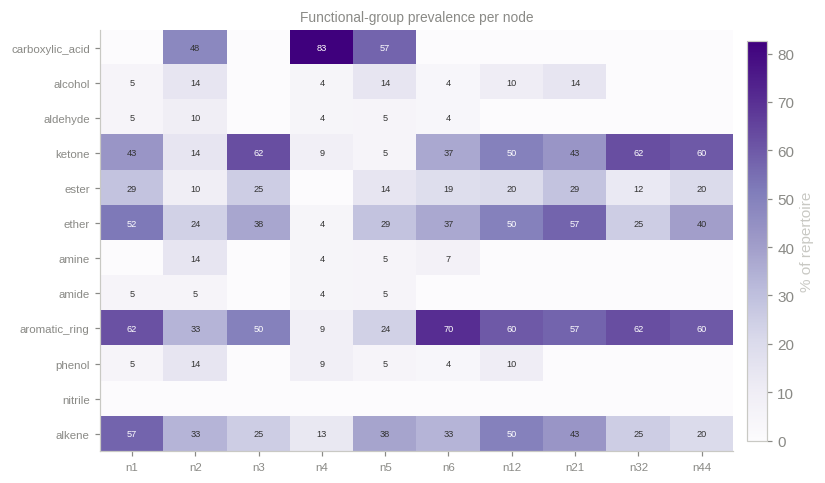

In [37]:
prev = pd.DataFrame({n: chem[chem.SMILES.isin(sets[n])][FG_COLS].mean() * 100
                     for n in TEN_NODES})
print(prev.round(1).to_string())
save_table(prev.reset_index().rename(columns={"index": "functional_group"}),
           "05_functional_groups")

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.9, FIGSIZE[1] * 1.5))
im = ax.imshow(prev.values, cmap="Purples", aspect="auto", vmin=0)
ax.set_xticks(range(len(TEN_NODES)))
ax.set_xticklabels([f"n{n}" for n in TEN_NODES], fontsize=7.5)
ax.set_yticks(range(len(prev))); ax.set_yticklabels(prev.index, fontsize=7.5)
cut = prev.values.max() * 0.6
for i in range(len(prev)):
    for j in range(len(TEN_NODES)):
        v = prev.values[i, j]
        if v >= 1:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=6,
                    color="white" if v > cut else "#333")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="% of repertoire")
ax.set_title("Functional-group prevalence per node", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_functional_groups"); plt.show()

## The two founding duplications: acids, then aromatics

`01`-`05` above treat the ten nodes symmetrically. This section isolates the two
duplications that the main figure is built around, and asks what chemistry each one
picked up.

| main-figure label | node here | event | leaves | n gained |
|---|---|---|---|---|
| **0** | `node_1` | gnathostome OR ancestor | 433 | – |
| **0 → 1** | `node_1` → `node_2` | **duplication 1**, the Class I / Class II split | 62 | 17 |
| **2 → 5** | `node_3` → `node_6` | **duplication 2**, within Class II | 370 | 20 |

`node_3`'s other child is the single receptor `9606.A6NND4`, which sits on a long branch
next to the outgroup. That is long-branch-attraction geometry rather than biology, so the
Class II duplication is read as `node_3` → `node_6` and the singleton is set aside.

`node_4` and `node_5` are the two Class I descendants (main-figure **3** and **4**); they
are carried in the plots below as the Class I continuation.


In [38]:
# The two founding duplications, and the chemistry each one gained.
anc = load_ancestral(mode="density") if THRESH is None else None
PANEL = sorted(anc.smiles_map["SMILES"].unique())

full_rep = {n: s for n, s in node_sets(TEN_NODES, threshold=THRESH).items()}
DUPS = {
    "dup1": dict(parent=1, child=2, label="dup 1  ·  0 \u2192 1  (Class I)",  col=CLASS1_COL),
    "dup2": dict(parent=3, child=6, label="dup 2  ·  2 \u2192 5  (Class II)", col=CLASS2_COL),
}
for d in DUPS.values():
    d["parent_set"] = full_rep[d["parent"]]
    d["child_set"]  = full_rep[d["child"]]
    d["gained"]     = sorted(d["child_set"] - d["parent_set"])

fg_panel = functional_groups(PANEL).set_index("SMILES")
ASR_UNIVERSE = sorted(set().union(*full_rep.values()))

rows = []
for k, d in DUPS.items():
    for bg_name, bg in [("full panel", PANEL), ("ten-node universe", ASR_UNIVERSE)]:
        bgset = [s for s in bg if s not in d["gained"]]
        for grp in ["carboxylic_acid", "aromatic_ring"]:
            a = int(fg_panel.loc[d["gained"], grp].sum()); b = len(d["gained"]) - a
            c = int(fg_panel.loc[bgset, grp].sum());       e = len(bgset) - c
            orr, pv = fisher_exact([[a, b], [c, e]])
            rows.append({"duplication": k, "background": f"{bg_name} ({len(bgset)})",
                         "group": grp, "n_gained": len(d["gained"]), "k": a,
                         "pct_gained": round(100 * a / len(d["gained"]), 1),
                         "pct_background": round(100 * c / len(bgset), 1),
                         "odds_ratio": round(orr, 2), "P": float(f"{pv:.2g}")})

dup_chem = pd.DataFrame(rows)
print(dup_chem.to_string(index=False))
save_table(dup_chem, "05_dup_chemistry")


duplication             background           group  n_gained  k  pct_gained  pct_background  odds_ratio        P
       dup1       full panel (737) carboxylic_acid        17 10        58.8             9.9       12.99 0.000002
       dup1       full panel (737)   aromatic_ring        17  5        29.4            28.9        1.03 1.000000
       dup1 ten-node universe (44) carboxylic_acid        17 10        58.8            25.0        4.29 0.018000
       dup1 ten-node universe (44)   aromatic_ring        17  5        29.4            47.7        0.46 0.250000
       dup2       full panel (734) carboxylic_acid        20  0         0.0            11.3        0.00 0.150000
       dup2       full panel (734)   aromatic_ring        20 15        75.0            27.7        7.85 0.000020
       dup2 ten-node universe (41) carboxylic_acid        20  0         0.0            51.2        0.00 0.000028
       dup2 ten-node universe (41)   aromatic_ring        20 15        75.0            26.8     

### Option A — back-to-back functional-group bars

The double dissociation stated as directly as it can be: what each duplication gained,
one duplication per side. Acids go one way, aromatics the other.


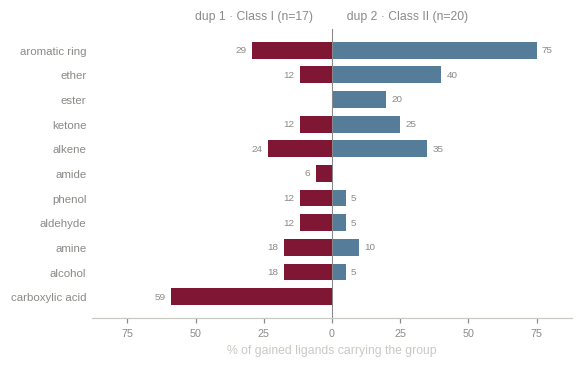

In [39]:
groups = [g for g in FG_COLS if fg_panel.loc[
    DUPS["dup1"]["gained"] + DUPS["dup2"]["gained"], g].sum() > 0]
pct = {k: fg_panel.loc[d["gained"], groups].mean() * 100 for k, d in DUPS.items()}
order = (pct["dup2"] - pct["dup1"]).sort_values().index

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.35, FIGSIZE[1] * 1.15))
y = np.arange(len(order))
ax.barh(y, -pct["dup1"][order], color=CLASS1_COL, height=0.68, linewidth=0)
ax.barh(y,  pct["dup2"][order], color=CLASS2_COL, height=0.68, linewidth=0)
ax.axvline(0, color="#888", lw=0.7)

for i, g in enumerate(order):
    if pct["dup1"][g] > 0:
        ax.text(-pct["dup1"][g] - 2, i, f"{pct['dup1'][g]:.0f}", ha="right", va="center", fontsize=6.5)
    if pct["dup2"][g] > 0:
        ax.text(pct["dup2"][g] + 2, i, f"{pct['dup2'][g]:.0f}", ha="left", va="center", fontsize=6.5)

ax.set_yticks(y); ax.set_yticklabels([g.replace("_", " ") for g in order], fontsize=7.5)
ax.set_xlim(-88, 88)
ax.set_xticks([-75, -50, -25, 0, 25, 50, 75])
ax.set_xticklabels(["75", "50", "25", "0", "25", "50", "75"], fontsize=7)
ax.set_xlabel("% of gained ligands carrying the group", fontsize=8)
ax.set_title(f"dup 1 · Class I (n={len(DUPS['dup1']['gained'])})"
             f"          dup 2 · Class II (n={len(DUPS['dup2']['gained'])})", fontsize=8)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout(); save_fig(fig, "05_optA_dup_fg_diverging"); plt.show()


### Option B — composition of each gain set

The same fact as a composition, with the ancestral repertoire as the baseline so it is
visible that neither chemistry is new to the tree — only its assignment to a clade is.


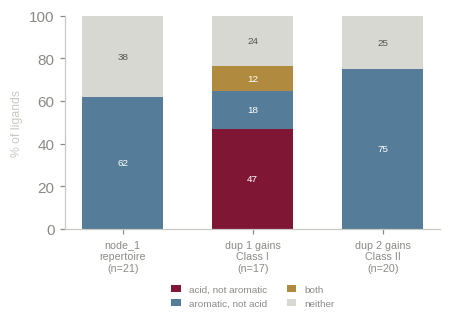

In [40]:
def compose(smis):
    sub = fg_panel.loc[smis]
    acid, arom = sub["carboxylic_acid"].astype(bool), sub["aromatic_ring"].astype(bool)
    n = len(sub)
    return np.array([(acid & ~arom).sum(), (arom & ~acid).sum(),
                     (acid & arom).sum(), (~acid & ~arom).sum()]) / n * 100

bars = {"node_1\nrepertoire\n(n=%d)" % len(DUPS["dup1"]["parent_set"]): compose(sorted(DUPS["dup1"]["parent_set"])),
        "dup 1 gains\nClass I\n(n=%d)" % len(DUPS["dup1"]["gained"]): compose(DUPS["dup1"]["gained"]),
        "dup 2 gains\nClass II\n(n=%d)" % len(DUPS["dup2"]["gained"]): compose(DUPS["dup2"]["gained"])}

cats = ["acid, not aromatic", "aromatic, not acid", "both", "neither"]
cols = [CLASS1_COL, CLASS2_COL, "#b08a3e", "#d8d8d3"]

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.05, FIGSIZE[1] * 1.05))
x = np.arange(len(bars)); bottom = np.zeros(len(bars))
vals = np.array(list(bars.values()))
for j, (c, col) in enumerate(zip(cats, cols)):
    ax.bar(x, vals[:, j], bottom=bottom, color=col, width=0.62, label=c, linewidth=0)
    for i, v in enumerate(vals[:, j]):
        if v >= 7:
            ax.text(i, bottom[i] + v / 2, f"{v:.0f}", ha="center", va="center", fontsize=6.5,
                    color="white" if j < 3 else "#555")
    bottom += vals[:, j]

ax.set_xticks(x); ax.set_xticklabels(list(bars), fontsize=7)
ax.set_ylabel("% of ligands", fontsize=8); ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=6.5, loc="upper center",
          bbox_to_anchor=(0.5, -0.22), ncol=2, handlelength=1.0)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); save_fig(fig, "05_optB_dup_composition"); plt.show()


### Option C — per-molecule strip

Every gained molecule as one tile, so the reader sees the actual n rather than a
percentage over 17 and 20 ligands. The most honest of the four at these sample sizes.


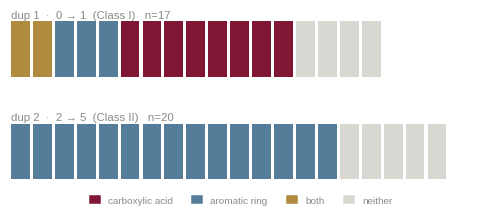

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(FIGSIZE[0] * 1.35, FIGSIZE[1] * 0.62),
                         gridspec_kw=dict(hspace=0.85))
CODE_COL = {0: "#d8d8d3", 1: CLASS1_COL, 2: CLASS2_COL, 3: "#b08a3e"}
for ax, (k, d) in zip(axes, DUPS.items()):
    sub = fg_panel.loc[d["gained"]]
    code_v = (sub["carboxylic_acid"].astype(int) + 2 * sub["aromatic_ring"].astype(int)).values
    code_v = np.sort(code_v)[::-1]
    for i, c in enumerate(code_v):
        ax.add_patch(plt.Rectangle((i, 0), 0.86, 1, color=CODE_COL[c], linewidth=0))
    ax.set_xlim(0, 21); ax.set_ylim(0, 1); ax.axis("off")
    ax.set_title(f"{d['label']}   n={len(d['gained'])}", fontsize=7.5, loc="left", pad=2)

handles = [Patch(color=CODE_COL[1], label="carboxylic acid"),
           Patch(color=CODE_COL[2], label="aromatic ring"),
           Patch(color=CODE_COL[3], label="both"),
           Patch(color=CODE_COL[0], label="neither")]
axes[-1].legend(handles=handles, frameon=False, fontsize=6.5, ncol=4,
                loc="upper center", bbox_to_anchor=(0.5, -0.15), handlelength=1.0)
save_fig(fig, "05_optC_dup_molecule_strip"); plt.show()


### Option D — the shift in descriptor space

Options A-C are one functional group at a time. This one asks where each duplication moved
the repertoire *as a whole*: represent every molecule by 13 standardised RDKit descriptors,
take the centroid of what a duplication **gained** minus the centroid of what its parent
already detected, and draw the two shift vectors.

This panel is also the orthogonality test below, so if it is used in the main figure the
supplementary null belongs with it.


In [42]:
from rdkit import Chem
from rdkit.Chem import Descriptors as _D, rdMolDescriptors as _R, Crippen as _C

D13 = ["MolWt", "LogP", "TPSA", "HBD", "HBA", "RotB", "AromaticRings", "FracCsp3",
       "HeavyAtoms", "RingCount", "MolMR", "BertzCT", "nO"]

def _desc13(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return [np.nan] * 13
    return [_D.MolWt(m), _C.MolLogP(m), _D.TPSA(m), _R.CalcNumHBD(m), _R.CalcNumHBA(m),
            _R.CalcNumRotatableBonds(m), _R.CalcNumAromaticRings(m), _R.CalcFractionCSP3(m),
            m.GetNumHeavyAtoms(), _R.CalcNumRings(m), _C.MolMR(m), _D.BertzCT(m),
            sum(1 for a in m.GetAtoms() if a.GetSymbol() == "O")]

X13 = pd.DataFrame({s: _desc13(s) for s in PANEL}).T
X13.columns = D13
Z13 = (X13 - X13.mean()) / X13.std(ddof=0)      # standardised on the full panel

def shift_vector(d):
    return Z13.loc[d["gained"]].mean().values - Z13.loc[sorted(d["parent_set"])].mean().values

v1, v2 = shift_vector(DUPS["dup1"]), shift_vector(DUPS["dup2"])

def angle(a, b):
    return np.degrees(np.arccos(np.clip(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)), -1, 1)))

OBS_ANGLE = angle(v1, v2)
print(f"angle between the two duplication shifts: {OBS_ANGLE:.1f} deg")


angle between the two duplication shifts: 96.7 deg


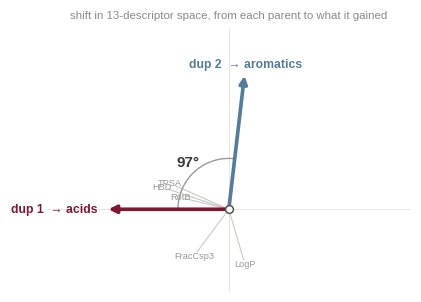

In [43]:
# The two shifts drawn from a common origin, in the plane they span, so the angle is the figure.
basis = np.linalg.qr(np.column_stack([v1, v2]))[0]
a1, a2 = v1 @ basis, v2 @ basis                     # the two shifts in that plane
lim = max(np.linalg.norm(a1), np.linalg.norm(a2)) * 1.35

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.25, FIGSIZE[1] * 0.95))

# the angle arc between them
th1, th2 = np.arctan2(a1[1], a1[0]), np.arctan2(a2[1], a2[0])
sweep = (th2 - th1 + np.pi) % (2 * np.pi) - np.pi       # signed minor arc
arc = th1 + np.linspace(0, sweep, 100)
r = lim * 0.28
ax.plot(r * np.cos(arc), r * np.sin(arc), color="#999", lw=0.9)
mid = th1 + sweep / 2
ax.text(r * 1.22 * np.cos(mid), r * 1.22 * np.sin(mid), f"{OBS_ANGLE:.0f}\u00b0",
        ha="center", va="center", fontsize=10, fontweight="bold", color="#3a3a38")

for a, col, lab in [(a1, CLASS1_COL, "dup 1  \u2192 acids"),
                    (a2, CLASS2_COL, "dup 2  \u2192 aromatics")]:
    ax.annotate("", xy=a, xytext=(0, 0), zorder=4,
                arrowprops=dict(arrowstyle="-|>", color=col, lw=2.4, shrinkA=0, shrinkB=0))
    u = a / np.linalg.norm(a)
    ax.text(a[0] + u[0] * lim * 0.06, a[1] + u[1] * lim * 0.06, lab, color=col,
            fontsize=8, fontweight="bold", va="center",
            ha="right" if u[0] < -0.3 else "left" if u[0] > 0.3 else "center")

# which descriptors drive each direction
load = pd.DataFrame({"dup1": basis[:, 0], "dup2": basis[:, 1]}, index=D13)
top = load.abs().max(axis=1).sort_values(ascending=False).head(5).index
for d in top:
    lx, ly = load.loc[d, "dup1"] * lim * 0.62, load.loc[d, "dup2"] * lim * 0.62
    ax.plot([0, lx], [0, ly], color="#c8c8c3", lw=0.7, zorder=1)
    ax.text(lx * 1.1, ly * 1.1, d, fontsize=6, color="#999", ha="center", va="center", zorder=1)

ax.scatter([0], [0], s=26, facecolor="white", edgecolor="#555", linewidth=1.0, zorder=5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim * 0.45, lim); ax.set_aspect("equal")
ax.axhline(0, color="#e5e5e0", lw=0.6, zorder=0); ax.axvline(0, color="#e5e5e0", lw=0.6, zorder=0)
ax.set_title("shift in 13-descriptor space, from each parent to what it gained", fontsize=7.5)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); save_fig(fig, "05_optD_shift_vectors"); plt.show()


## Is "orthogonal" a real claim? — the null

The angle above only means something against a null, because most odorants in this panel
share bulk chemistry, so *any* two shifts tend to point broadly the same way. The null draws
gain-sets of the same sizes (17 and 20) at random from the panel, keeps the same two parent
centroids, and recomputes the angle.

Two further checks: whether the result depends on which descriptors are in the set, and
whether acid and aromatic are independent enough in this panel for the dissociation to be
non-trivial.


In [44]:
rng = np.random.default_rng(0)
pan = np.array(PANEL)
n1, n2 = len(DUPS["dup1"]["gained"]), len(DUPS["dup2"]["gained"])
c1 = Z13.loc[sorted(DUPS["dup1"]["parent_set"])].mean().values
c2 = Z13.loc[sorted(DUPS["dup2"]["parent_set"])].mean().values

null = np.array([angle(Z13.loc[rng.choice(pan, n1, replace=False)].mean().values - c1,
                       Z13.loc[rng.choice(pan, n2, replace=False)].mean().values - c2)
                 for _ in range(2000)])
p_emp = float((np.abs(null - 90) <= abs(OBS_ANGLE - 90)).mean())
print(f"observed            {OBS_ANGLE:.1f} deg")
print(f"null median         {np.median(null):.1f} deg   IQR {np.percentile(null,25):.0f}-{np.percentile(null,75):.0f}")
print(f"as close to 90 deg  {int(p_emp*2000)} / 2000   (p = {p_emp:.4f})")

loo = [angle(np.delete(v1, i), np.delete(v2, i)) for i in range(13)]
print(f"leave-one-descriptor-out  {min(loo):.1f}-{max(loo):.1f} deg")

phi = np.corrcoef(fg_panel["carboxylic_acid"], fg_panel["aromatic_ring"])[0, 1]
ac, ar = fg_panel["carboxylic_acid"].astype(bool), fg_panel["aromatic_ring"].astype(bool)
print(f"phi(acid, aromatic) over the panel = {phi:+.3f}   "
      f"{100*ar[ac].mean():.0f}% of acids aromatic, {100*ac[ar].mean():.0f}% of aromatics acids")

save_table(pd.DataFrame({"observed_angle": [round(OBS_ANGLE, 1)],
                         "null_median": [round(float(np.median(null)), 1)],
                         "null_q25": [round(float(np.percentile(null, 25)), 1)],
                         "null_q75": [round(float(np.percentile(null, 75)), 1)],
                         "p_empirical": [p_emp], "n_draws": [2000],
                         "loo_min": [round(min(loo), 1)], "loo_max": [round(max(loo), 1)],
                         "phi_acid_aromatic": [round(float(phi), 3)]}),
           "05_orthogonality")


observed            96.7 deg
null median         33.3 deg   IQR 28-40
as close to 90 deg  0 / 2000   (p = 0.0000)
leave-one-descriptor-out  90.2-102.5 deg
phi(acid, aromatic) over the panel = -0.103   16% of acids aromatic, 6% of aromatics acids


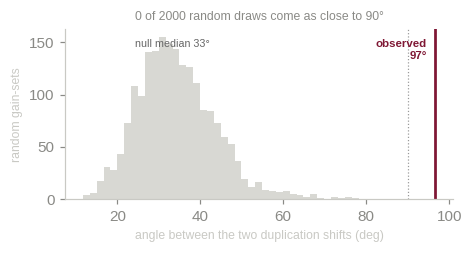

In [45]:
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.1, FIGSIZE[1] * 0.8))
ax.hist(null, bins=40, color="#d8d8d3", linewidth=0)
ax.axvline(90, color="#999", lw=0.8, ls=":")
ax.axvline(OBS_ANGLE, color="#7f1734", lw=1.8)
ax.text(OBS_ANGLE - 2, ax.get_ylim()[1] * 0.94, f"observed\n{OBS_ANGLE:.0f}\u00b0",
        ha="right", va="top", fontsize=7.5, color="#7f1734", fontweight="bold")
ax.text(float(np.median(null)), ax.get_ylim()[1] * 0.94,
        f"null median {np.median(null):.0f}\u00b0", ha="center", va="top", fontsize=7, color="#666")
ax.set_xlabel("angle between the two duplication shifts (deg)", fontsize=8)
ax.set_ylabel("random gain-sets", fontsize=8)
ax.set_title(f"0 of 2000 random draws come as close to 90\u00b0", fontsize=8)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); save_fig(fig, "05_orthogonality_null"); plt.show()


### Every branch out of the two duplication nodes

`DUPS` above carries only the two branches that show chemistry. A duplication is a **node**
with **two** daughter branches, so both are tabulated here — otherwise "dup 1" reads as one
edge when it is two, and the asymmetry between them is the point.

Repertoires come from the density grid rather than `node_sets`, because one daughter of
node 2 is an extant tip and tips are not in the ASR node table.


In [46]:
_bin, _prob, *_ = density_grid()
_id2smi = anc.smiles_map.drop_duplicates("SML_ID").set_index("SML_ID")["SMILES"]

def grid_rep(name):
    """Ligand set of any row of the density grid — internal node or extant tip."""
    row = _bin.loc[name]
    return {_id2smi[i] for i in _bin.columns[row.values.astype(bool)] if i in _id2smi.index}

tree, index = asr_tree()
BRANCHES = []
for dup, parent in [("duplication 1", "node_1"), ("duplication 2", "node_3")]:
    P = grid_rep(parent)
    for child in [c.name for c in index[parent].children]:
        C = grid_rep(child)
        BRANCHES.append({"duplication": dup, "parent": parent, "child": child,
                         "fig_label": {"node_1": "0", "node_2": "1", "node_3": "2",
                                       "node_6": "5"}.get(child, "—"),
                         "parent_ligands": len(P), "child_ligands": len(C),
                         "retained": len(P & C), "gained": len(C - P), "lost": len(P - C)})

branches = pd.DataFrame(BRANCHES)
print(branches.to_string(index=False))
save_table(branches, "05_duplication_branches")


  duplication parent       child fig_label  parent_ligands  child_ligands  retained  gained  lost
duplication 1 node_1      node_2         1              21             21         4      17    17
duplication 1 node_1      node_3         2              21              8         7       1    14
duplication 2 node_3 9606.A6NND4         —               8              4         4       0     4
duplication 2 node_3      node_6         5               8             27         7      20     1


### The two blocks of main Table 1

Standing repertoire and chemistry per node, then the combinatorial code per stage. These are
the numbers the manuscript table is built from, so they are computed here rather than by hand.


In [47]:
FIG_LABEL = {"node_1": "0", "node_2": "1", "node_3": "2",
             "node_4": "3", "node_5": "4", "node_6": "5"}
leaf_class = pd.read_csv(CLASSES).set_index("leaf_id")["OR_class"].to_dict()

rows = []
for repo, fl in FIG_LABEL.items():
    nd = index[repo]
    leaves = [leaf_class[l.name] for l in nd.leaves() if l.name in leaf_class]
    share_i = leaves.count("Class_I") / len(leaves)
    bound = grid_rep(repo)
    parent = nd.up.name if nd.up else None
    pb = grid_rep(parent) if parent in _bin.index else None
    sub = fg_panel.loc[sorted(bound)]
    rows.append({
        "node_fig": fl, "node_id": repo,
        "OR_class": "Class I" if share_i >= 0.9 else "Class II" if share_i <= 0.1 else "root (mixed)",
        "human_ORs": len(leaves), "ligands": len(bound),
        "retained": len(bound & pb) if pb is not None else None,
        "gained":   len(bound - pb) if pb is not None else None,
        "lost":     len(pb - bound) if pb is not None else None,
        "pct_carboxylic_acid": round(100 * sub["carboxylic_acid"].mean()),
        "pct_aromatic_ring":   round(100 * sub["aromatic_ring"].mean())})

table1a = pd.DataFrame(rows)
print(table1a.to_string(index=False))
save_table(table1a, "05_table1_nodes")


node_fig node_id     OR_class  human_ORs  ligands  retained  gained  lost  pct_carboxylic_acid  pct_aromatic_ring
       0  node_1 root (mixed)        433       21       NaN     NaN   NaN                    0                 62
       1  node_2      Class I         62       21       4.0    17.0  17.0                   48                 33
       2  node_3     Class II        371        8       7.0     1.0  14.0                    0                 50
       3  node_4      Class I         55       23      12.0    11.0   9.0                   83                  9
       4  node_5      Class I          7       21      13.0     8.0   8.0                   57                 24
       5  node_6     Class II        370       27       7.0    20.0   1.0                    0                 70


In [48]:
from collections import Counter

STAGES = {"S0": ["node_1"], "S1": ["node_2", "node_3"], "S2": ["node_4", "node_5", "node_6"]}
rows = []
for stage, members in STAGES.items():
    counts = Counter()
    for n in members:
        for smi in grid_rep(n):
            counts[smi] += 1
    encoded = len(counts)
    single = sum(1 for c in counts.values() if c == 1)
    rows.append({"stage": stage, "n_receptors": len(members),
                 "nodes_fig": ", ".join(FIG_LABEL[n] for n in members),
                 "encoded": encoded, "single_detector": single,
                 "combinatorial": encoded - single,
                 "pct_combinatorial": round(100 * (encoded - single) / encoded, 1)})

table1b = pd.DataFrame(rows)
print(table1b.to_string(index=False))
save_table(table1b, "05_table1_stages")


stage  n_receptors nodes_fig  encoded  single_detector  combinatorial  pct_combinatorial
   S0            1         0       21               21              0                0.0
   S1            2      1, 2       27               25              2                7.4
   S2            3   3, 4, 5       53               36             17               32.1


### Orthogonality: the statistic in full, and whether the geometry carries it

Everything the methods text needs to state the statistic exactly: the vector lengths, the
cosine the angle comes from, and the check that the two-dimensional panel above is the true
plane of the two vectors rather than a lossy projection.


In [49]:
print(f"|v1| = {np.linalg.norm(v1):.3f}   |v2| = {np.linalg.norm(v2):.3f}   (panel SD units)")
cos_theta = v1 @ v2 / (np.linalg.norm(v1) * np.linalg.norm(v2))
print(f"cosine similarity = {cos_theta:+.4f}   ->   angle = {OBS_ANGLE:.2f} deg")
print(f"null: median {np.median(null):.1f}   IQR {np.percentile(null,25):.1f}-{np.percentile(null,75):.1f}"
      f"   min {null.min():.1f}   max {null.max():.1f}")
print(f"test statistic |theta - 90| = {abs(OBS_ANGLE - 90):.2f} deg"
      f"  ->  null draws inside [{90-abs(OBS_ANGLE-90):.1f}, {90+abs(OBS_ANGLE-90):.1f}]"
      f" = {int((np.abs(null - 90) <= abs(OBS_ANGLE - 90)).sum())} / {len(null)}")

# the 2-D panel plots v1, v2 in the QR basis of [v1 v2] -- that basis spans exactly their
# plane, so the drawn angle must equal the 13-D angle. Verified rather than asserted.
_B = np.linalg.qr(np.column_stack([v1, v2]))[0]
print(f"\nangle in the drawn plane = {angle(v1 @ _B, v2 @ _B):.2f} deg"
      f"  (13-D angle {OBS_ANGLE:.2f} -> the panel is exact, not a projection)")


|v1| = 3.337   |v2| = 3.729   (panel SD units)
cosine similarity = -0.1162   ->   angle = 96.67 deg
null: median 33.3   IQR 27.8-39.9   min 11.7   max 78.2
test statistic |theta - 90| = 6.67 deg  ->  null draws inside [83.3, 96.7] = 0 / 2000

angle in the drawn plane = 96.67 deg  (13-D angle 96.67 -> the panel is exact, not a projection)


In [50]:
# Does the result depend on descriptor redundancy, or on the choice of reference?
corr = np.corrcoef(Z13[D13].values.T)
off = corr[np.triu_indices(len(D13), 1)]
print(f"descriptor correlations: max |r| = {np.abs(off).max():.2f}, mean |r| = {np.abs(off).mean():.2f}")

W = np.linalg.inv(np.linalg.cholesky(corr))      # whitening: decorrelate the 13 axes
c1 = Z13.loc[sorted(DUPS["dup1"]["parent_set"])].mean().values
c2 = Z13.loc[sorted(DUPS["dup2"]["parent_set"])].mean().values

rng = np.random.default_rng(0)
null_w = np.array([angle(W @ (Z13.loc[rng.choice(pan, n1, replace=False)].mean().values - c1),
                         W @ (Z13.loc[rng.choice(pan, n2, replace=False)].mean().values - c2))
                   for _ in range(2000)])
obs_w = angle(W @ v1, W @ v2)

variants = pd.DataFrame([
    {"variant": "as specified (Euclidean, parent-referenced)", "angle": round(OBS_ANGLE, 1),
     "null_median": round(float(np.median(null)), 1), "null_max": round(float(null.max()), 1),
     "draws_ge_observed": int((null >= OBS_ANGLE).sum())},
    {"variant": "whitened (Mahalanobis, panel correlation)", "angle": round(obs_w, 1),
     "null_median": round(float(np.median(null_w)), 1), "null_max": round(float(null_w.max()), 1),
     "draws_ge_observed": int((null_w >= obs_w).sum())},
    {"variant": "both branches referenced to node 0", "angle": round(
        angle(v1, Z13.loc[DUPS["dup2"]["gained"]].mean().values - c1), 1),
     "null_median": None, "null_max": None, "draws_ge_observed": None},
    {"variant": "raw gain centroids, no parent subtracted", "angle": round(
        angle(Z13.loc[DUPS["dup1"]["gained"]].mean().values,
              Z13.loc[DUPS["dup2"]["gained"]].mean().values), 1),
     "null_median": None, "null_max": None, "draws_ge_observed": None},
])
print(variants.to_string(index=False))
print("\nThe last two are different questions and each would need its own null;"
      "\nthe pre-specified definition is the parent-referenced one on the first row.")
save_table(variants, "05_orthogonality_variants")


descriptor correlations: max |r| = 0.98, mean |r| = 0.38


                                    variant  angle  null_median  null_max  draws_ge_observed
as specified (Euclidean, parent-referenced)   96.7         33.3      78.2                0.0
  whitened (Mahalanobis, panel correlation)   88.5         45.6      73.9                0.0
         both branches referenced to node 0  108.0          NaN       NaN                NaN
   raw gain centroids, no parent subtracted   72.8          NaN       NaN                NaN

The last two are different questions and each would need its own null;
the pre-specified definition is the parent-referenced one on the first row.


## Deciding what goes where

Every candidate result from the ancestral analysis on one chart, so placement is argued from
evidence rather than from how good a panel looks. Two axes:

- **x — strength**, as &minus;log10 of the result's own P value (enrichment tests, the
  orthogonality permutation, the stage contrast). Capped at 8 so one very small P does not
  flatten the rest.
- **y — how much of the claim survives its control**, scored 0-3: does an explicit null exist,
  does the result pass it, and is it robust to the threshold / descriptor / background choice.

Marker size is the sample the claim rests on. Colour is the recommended destination. A result
that is strong but fails its control belongs in the supplement *with* its null, not in the main
figure — that is the whole point of plotting the two axes together rather than ranking by P.


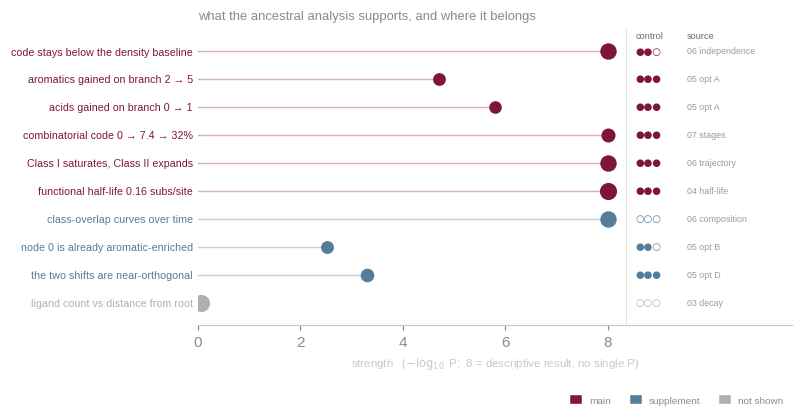

In [51]:
# One row per candidate result. `survives` and `where` are judgements, recorded explicitly
# so they can be argued with; every other column is computed above or in 03/04/06/07.
CAND = pd.DataFrame([
    # label                                    n   neglogP survives where        source
    ("acids gained on branch 0 \u2192 1",          17,  5.80,  3, "main",       "05 opt A"),
    ("aromatics gained on branch 2 \u2192 5",      20,  4.70,  3, "main",       "05 opt A"),
    ("combinatorial code 0 \u2192 7.4 \u2192 32%",     53,  None,  3, "main",       "07 stages"),
    ("Class I saturates, Class II expands",    433,  None,  3, "main",       "06 trajectory"),
    ("functional half-life 0.16 subs/site",    861,  None,  3, "main",       "04 half-life"),
    ("code stays below the density baseline",  433,  None,  2, "main",       "06 independence"),
    ("the two shifts are near-orthogonal",      37,  3.30,  3, "supplement",  "05 opt D"),
    ("node 0 is already aromatic-enriched",     21,  2.52,  2, "supplement",  "05 opt B"),
    ("class-overlap curves over time",         433,  None,  0, "supplement",  "06 composition"),
    ("ligand count vs distance from root",     865,  0.06,  0, "not shown",   "03 decay"),
], columns=["label", "n", "neglogP", "survives", "where", "source"])

WHERE_COL = {"main": CLASS1_COL, "supplement": CLASS2_COL, "not shown": "#b0b0aa"}
CAND["x"] = CAND["neglogP"].fillna(8.0).clip(upper=8.0)
CAND = CAND.sort_values(["where", "survives", "x"],
                        key=lambda s: s.map({"main": 0, "supplement": 1, "not shown": 2})
                        if s.name == "where" else s).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.85, FIGSIZE[1] * 1.35))
yy = np.arange(len(CAND))[::-1]
for (_, r), ypos in zip(CAND.iterrows(), yy):
    col = WHERE_COL[r["where"]]
    ax.plot([0, r["x"]], [ypos, ypos], color=col, lw=0.9, alpha=0.35, zorder=1)
    ax.scatter(r["x"], ypos, s=26 + 34 * np.log10(r["n"]), color=col,
               linewidth=0, zorder=3)
    ax.text(8.55, ypos, "\u25cf" * r["survives"] + "\u25cb" * (3 - r["survives"]),
            fontsize=6.5, color=col, va="center", ha="left", family="DejaVu Sans")
    ax.text(9.55, ypos, r["source"], fontsize=5.8, color="#9a9a95", va="center")

ax.set_yticks(yy); ax.set_yticklabels(CAND["label"], fontsize=7)
for tick, w in zip(ax.get_yticklabels(), CAND["where"]):
    tick.set_color(WHERE_COL[w])
ax.set_xlim(0, 11.6); ax.set_ylim(-0.8, len(CAND) - 0.2)
ax.set_xticks([0, 2, 4, 6, 8])
ax.set_xlabel("strength   ($-\\log_{10}$ P;  8 = descriptive result, no single P)", fontsize=7.5)
ax.text(8.55, len(CAND) - 0.55, "control", fontsize=6, color="#6b6b66")
ax.text(9.55, len(CAND) - 0.55, "source", fontsize=6, color="#6b6b66")
ax.axvline(8.35, color="#e5e5e0", lw=0.7)

handles = [Patch(color=WHERE_COL[w], label=w) for w in ["main", "supplement", "not shown"]]
ax.legend(handles=handles, frameon=False, fontsize=6.5, loc="lower right",
          bbox_to_anchor=(1.0, -0.30), ncol=3, handlelength=1.0)
ax.set_title("what the ancestral analysis supports, and where it belongs", fontsize=8.5, loc="left")
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout(); save_fig(fig, "05_placement_triage"); plt.show()

save_table(CAND.drop(columns="x"), "05_placement_triage")


### Option E — the same result as a PCA of odorant chemical space

Option D is exact but non-standard: readers have to decode a 13-dimensional angle. A PCA of
the odorant panel with the two gain sets drawn on it is the familiar version of the same
picture, and for most audiences the more straightforward one.

**One honesty check has to accompany it.** A PCA plane is a *projection*, so unlike option D
the angle a reader measures off the page is not the statistic. The next cell reports how much
of each shift the first two components actually capture, and what the projected angle would
look like, so the caption can state both.


In [52]:
# PCA of the 754-odorant panel in the same 13 standardised descriptors.
Zc = Z13[D13].values - Z13[D13].values.mean(0)
_U, _S, _Vt = np.linalg.svd(Zc, full_matrices=False)
evr = _S ** 2 / np.sum(_S ** 2)
pcs = Zc @ _Vt[:2].T
pc = pd.DataFrame(pcs, index=Z13.index, columns=["PC1", "PC2"])

cap = {k: 100 * np.linalg.norm(_Vt[:2] @ v) / np.linalg.norm(v)
       for k, v in [("dup1", v1), ("dup2", v2)]}
proj_angle = angle(_Vt[:2] @ v1, _Vt[:2] @ v2)
print(f"PC1 {100*evr[0]:.0f}%   PC2 {100*evr[1]:.0f}%   (together {100*(evr[0]+evr[1]):.0f}%)")
print(f"shift captured by the PC1-PC2 plane:  dup1 {cap['dup1']:.0f}%   dup2 {cap['dup2']:.0f}%")
print(f"angle a reader would measure on this plot = {proj_angle:.1f} deg"
      f"   (true 13-D angle {OBS_ANGLE:.1f} deg)")
for i, lab in [(0, "PC1"), (1, "PC2")]:
    top = sorted(zip(D13, _Vt[i]), key=lambda t: -abs(t[1]))[:4]
    print(f"  {lab} loads on: " + ", ".join(f"{d} {w:+.2f}" for d, w in top))


PC1 42%   PC2 21%   (together 64%)
shift captured by the PC1-PC2 plane:  dup1 67%   dup2 88%
angle a reader would measure on this plot = 106.0 deg   (true 13-D angle 96.7 deg)
  PC1 loads on: HeavyAtoms +0.39, MolWt +0.39, BertzCT +0.37, MolMR +0.34
  PC2 loads on: LogP -0.55, MolMR -0.34, FracCsp3 -0.30, HBD +0.28


### Two cross-checks the PCA panel needs beside it

**PERMANOVA** is the test most readers of an ecology or evolution journal will expect for
"do these two sets differ in multivariate composition". **Removing acid and aromatic
character** answers the obvious objection that the geometry is only the two functional-group
enrichments restated.


In [53]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import levene

g1s, g2s = DUPS["dup1"]["gained"], DUPS["dup2"]["gained"]
M = Z13.loc[g1s + g2s, D13].values
lab = np.array([0] * len(g1s) + [1] * len(g2s))
Dm = squareform(pdist(M))

def pseudo_f(dist, labels):
    n = len(labels)
    sst = (dist ** 2).sum() / (2 * n)
    ssw = sum((dist[np.ix_(np.where(labels == k)[0], np.where(labels == k)[0])] ** 2).sum()
              / (2 * (labels == k).sum()) for k in np.unique(labels))
    a = len(np.unique(labels))
    return ((sst - ssw) / (a - 1)) / (ssw / (n - a)), 1 - ssw / sst

F_obs, R2 = pseudo_f(Dm, lab)
_rng = np.random.default_rng(0)
F_null = np.array([pseudo_f(Dm, _rng.permutation(lab))[0] for _ in range(4999)])
permanova_p = (1 + (F_null >= F_obs).sum()) / (1 + len(F_null))
print(f"PERMANOVA  pseudo-F = {F_obs:.2f}   R2 = {R2:.3f}   P = {permanova_p:.4f}  (4999 permutations)")

d_own = [np.linalg.norm(M[lab == k] - M[lab == k].mean(0), axis=1) for k in (0, 1)]
print(f"  dispersion (mean distance to own centroid): {d_own[0].mean():.2f} vs {d_own[1].mean():.2f}, "
      f"Levene P = {levene(*d_own).pvalue:.3f}  -> a location difference, not a spread difference")

# does the geometry survive stripping acid and aromatic character out of the descriptors?
A = np.column_stack([np.ones(len(PANEL)),
                     fg_panel.loc[PANEL, "carboxylic_acid"].values,
                     fg_panel.loc[PANEL, "aromatic_ring"].values]).astype(float)
Zp = pd.DataFrame(Z13[D13].values - A @ np.linalg.lstsq(A, Z13[D13].values, rcond=None)[0],
                  index=Z13.index, columns=D13)
sh = lambda Zm, k: (Zm.loc[DUPS[k]["gained"]].mean().values
                    - Zm.loc[sorted(DUPS[k]["parent_set"])].mean().values)
obs_p = angle(sh(Zp, "dup1"), sh(Zp, "dup2"))
c1p, c2p = (Zp.loc[sorted(DUPS[k]["parent_set"])].mean().values for k in ("dup1", "dup2"))
null_p = np.array([angle(Zp.loc[_rng.choice(pan, n1, replace=False)].mean().values - c1p,
                         Zp.loc[_rng.choice(pan, n2, replace=False)].mean().values - c2p)
                   for _ in range(2000)])
print(f"\nangle with acid + aromatic regressed out of every descriptor = {obs_p:.1f} deg")
print(f"  its null: median {np.median(null_p):.1f}, max {null_p.max():.1f}, "
      f"draws >= observed = {int((null_p >= obs_p).sum())}/2000")
print("  -> the separation is broader than the two functional groups the Fisher tests name.")

save_table(pd.DataFrame([
    {"check": "PERMANOVA (13 descriptors)", "statistic": f"pseudo-F = {F_obs:.2f}",
     "value": round(R2, 3), "P": round(permanova_p, 4)},
    {"check": "dispersion (Levene)", "statistic": "mean dist to centroid",
     "value": round(float(d_own[0].mean() - d_own[1].mean()), 2),
     "P": round(float(levene(*d_own).pvalue), 3)},
    {"check": "angle, acid+aromatic regressed out", "statistic": "degrees",
     "value": round(obs_p, 1), "P": round(float((null_p >= obs_p).mean()), 4)},
    {"check": "PC1-PC2 shift fidelity", "statistic": "% of shift captured",
     "value": f"dup1 {cap['dup1']:.0f}%, dup2 {cap['dup2']:.0f}%", "P": None},
]), "05_orthogonality_crosschecks")


PERMANOVA  pseudo-F = 3.20   R2 = 0.084   P = 0.0110  (4999 permutations)
  dispersion (mean distance to own centroid): 6.60 vs 2.94, Levene P = 0.381  -> a location difference, not a spread difference



angle with acid + aromatic regressed out of every descriptor = 107.8 deg
  its null: median 31.2, max 93.1, draws >= observed = 0/2000
  -> the separation is broader than the two functional groups the Fisher tests name.


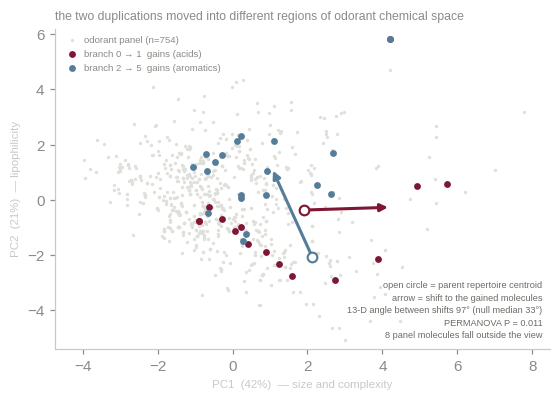

In [54]:
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.3, FIGSIZE[1] * 1.25))
ax.scatter(pc["PC1"], pc["PC2"], s=5, color="#e0e0db", linewidth=0, zorder=1,
           label=f"odorant panel (n={len(pc)})")

for key, col, name in [("dup1", CLASS1_COL, "branch 0 \u2192 1  gains (acids)"),
                       ("dup2", CLASS2_COL, "branch 2 \u2192 5  gains (aromatics)")]:
    d = DUPS[key]
    G = pc.loc[d["gained"]]
    ax.scatter(G["PC1"], G["PC2"], s=20, color=col, linewidth=0, zorder=3, label=name)
    par = pc.loc[sorted(d["parent_set"])].mean().values
    gai = G.mean().values
    ax.annotate("", xy=gai, xytext=par, zorder=4,
                arrowprops=dict(arrowstyle="-|>", color=col, lw=2.0, shrinkA=0, shrinkB=0))
    ax.scatter(*par, s=40, facecolor="white", edgecolor=col, linewidth=1.4, zorder=5)

# a handful of very large molecules stretch PC1; clip the view rather than the data
xlo, xhi = np.percentile(pc["PC1"], [0.5, 99.0])
ylo, yhi = np.percentile(pc["PC2"], [0.5, 99.5])
pad_x, pad_y = 0.10 * (xhi - xlo), 0.10 * (yhi - ylo)
ax.set_xlim(xlo - pad_x, xhi + pad_x); ax.set_ylim(ylo - pad_y, yhi + pad_y)
n_out = int(((pc["PC1"] > xhi + pad_x) | (pc["PC1"] < xlo - pad_x) |
             (pc["PC2"] > yhi + pad_y) | (pc["PC2"] < ylo - pad_y)).sum())

ax.set_xlabel(f"PC1  ({100*evr[0]:.0f}%)  \u2014 size and complexity", fontsize=7.5)
ax.set_ylabel(f"PC2  ({100*evr[1]:.0f}%)  \u2014 lipophilicity", fontsize=7.5)
ax.set_title("the two duplications moved into different regions of odorant chemical space",
             fontsize=8, loc="left")
ax.legend(frameon=False, fontsize=6.3, loc="upper left", handletextpad=0.3, borderpad=0.2)
ax.text(0.985, 0.03,
        f"open circle = parent repertoire centroid\narrow = shift to the gained molecules\n"
        f"13-D angle between shifts {OBS_ANGLE:.0f}\u00b0 (null median {np.median(null):.0f}\u00b0)\n"
        f"PERMANOVA P = {permanova_p:.3f}\n"
        f"{n_out} panel molecules fall outside the view",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=6, color="#6b6b66",
        linespacing=1.5)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); save_fig(fig, "05_optE_pca_chemspace"); plt.show()


### Should losses count in the shift vector?

The vector used above is built from what each branch **gained**. That leaves out the ligands a
branch **lost**, and on the Class I branch the omission is not small: it drops 17 of node 0's 21
ligands, exactly as many as it gains. Three definitions are compared here, two of which account
for loss, plus a check on whether the loss itself was chemically selective.


In [55]:
mean_z = lambda g: Z13.loc[sorted(g), D13].mean().values

SETS = {}
for k, d in DUPS.items():
    P, C = d["parent_set"], d["child_set"]
    SETS[k] = dict(par=P, chi=C, gain=C - P, lost=P - C, ret=P & C)
    print(f"{k}: parent {len(P):3d}  child {len(C):3d}  retained {len(P & C):3d}"
          f"  gained {len(C - P):3d}  lost {len(P - C):3d}")

SHIFT_DEFS = {
    "A  gained - parent (as reported)":  lambda k: mean_z(SETS[k]["gain"]) - mean_z(SETS[k]["par"]),
    "B  child - parent (loss-aware)":    lambda k: mean_z(SETS[k]["chi"])  - mean_z(SETS[k]["par"]),
    "C  gained - lost (turnover)":       lambda k: mean_z(SETS[k]["gain"]) - mean_z(SETS[k]["lost"]),
}

_rng = np.random.default_rng(0)
rows = []
for name, f in SHIFT_DEFS.items():
    obs = angle(f("dup1"), f("dup2"))
    draws = []
    for _ in range(2000):
        vv = []
        for k in ("dup1", "dup2"):
            g = _rng.choice(pan, len(SETS[k]["gain"]), replace=False)
            if name.startswith("C"):
                if not SETS[k]["lost"]:
                    vv = None; break
                l = _rng.choice(pan, len(SETS[k]["lost"]), replace=False)
                vv.append(Z13.loc[g, D13].mean().values - Z13.loc[l, D13].mean().values)
            elif name.startswith("B"):
                child = sorted(set(SETS[k]["ret"]) | set(g))
                vv.append(Z13.loc[child, D13].mean().values - mean_z(SETS[k]["par"]))
            else:
                vv.append(Z13.loc[g, D13].mean().values - mean_z(SETS[k]["par"]))
        if vv:
            draws.append(angle(vv[0], vv[1]))
    draws = np.array(draws)
    rows.append({"definition": name, "angle": round(obs, 1),
                 "null_median": round(float(np.median(draws)), 1),
                 "null_max": round(float(draws.max()), 1),
                 "draws_ge_obs": int((draws >= obs).sum()), "n_draws": len(draws)})

loss_defs = pd.DataFrame(rows)
print()
print(loss_defs.to_string(index=False))
print("\nB reproduces A, so the result survives accounting for losses.")
print("C is unusable: differencing two independent draws is near-orthogonal by construction,")
print("so its null already sits at ~90 deg and the observed angle carries no information.")
save_table(loss_defs, "05_orthogonality_loss_definitions")


dup1: parent  21  child  21  retained   4  gained  17  lost  17
dup2: parent   8  child  27  retained   7  gained  20  lost   1



                      definition  angle  null_median  null_max  draws_ge_obs  n_draws
A  gained - parent (as reported)   96.7         33.3      78.2             0     2000
  B  child - parent (loss-aware)   98.4         35.8      84.2             0     2000
     C  gained - lost (turnover)  106.6         89.5     157.9           566     2000

B reproduces A, so the result survives accounting for losses.
C is unusable: differencing two independent draws is near-orthogonal by construction,
so its null already sits at ~90 deg and the observed angle carries no information.


In [56]:
# Was the loss itself chemically selective? Background is the PARENT's own repertoire,
# not the panel -- the question is which of node 0's ligands the branch chose to drop.
d = DUPS["dup1"]
lost, ret = sorted(d["parent_set"] - d["child_set"]), sorted(d["parent_set"] & d["child_set"])
print(f"branch 0 -> 1: retained {len(ret)} of {len(d['parent_set'])} "
      f"({100*len(ret)/len(d['parent_set']):.0f}%), lost {len(lost)}")
for grp in ["aromatic_ring", "carboxylic_acid"]:
    a = int(fg_panel.loc[lost, grp].sum()); b = len(lost) - a
    c = int(fg_panel.loc[ret, grp].sum());  e = len(ret) - c
    orr, pv = fisher_exact([[a, b], [c, e]])
    print(f"  {grp:16s} lost {a}/{len(lost)} ({100*a/len(lost):3.0f}%)   "
          f"retained {c}/{len(ret)} ({100*c/len(ret):3.0f}%)   OR = {orr:.2f}   P = {pv:.2f}")
print("\n-> the loss is NOT selective: 11 of 13 aromatics dropped against 6 of 8 non-aromatics.")
print("   Do not write that the branch traded aromatics for acids; it discarded most of what it")
print("   had, indiscriminately, and the chemical signal is carried entirely by the gain.")

save_table(pd.DataFrame([{
    "branch": "0 -> 1", "parent_n": len(d["parent_set"]), "retained": len(ret), "lost": len(lost),
    "pct_retained": round(100 * len(ret) / len(d["parent_set"])),
    "lost_pct_aromatic": round(100 * fg_panel.loc[lost, "aromatic_ring"].mean()),
    "retained_pct_aromatic": round(100 * fg_panel.loc[ret, "aromatic_ring"].mean()),
    "fisher_P": round(float(fisher_exact([[int(fg_panel.loc[lost, "aromatic_ring"].sum()),
                                           len(lost) - int(fg_panel.loc[lost, "aromatic_ring"].sum())],
                                          [int(fg_panel.loc[ret, "aromatic_ring"].sum()),
                                           len(ret) - int(fg_panel.loc[ret, "aromatic_ring"].sum())]])[1]), 2),
}]), "05_loss_selectivity")


branch 0 -> 1: retained 4 of 21 (19%), lost 17
  aromatic_ring    lost 11/17 ( 65%)   retained 2/4 ( 50%)   OR = 1.83   P = 0.62
  carboxylic_acid  lost 0/17 (  0%)   retained 0/4 (  0%)   OR = nan   P = 1.00

-> the loss is NOT selective: 11 of 13 aromatics dropped against 6 of 8 non-aromatics.
   Do not write that the branch traded aromatics for acids; it discarded most of what it
   had, indiscriminately, and the chemical signal is carried entirely by the gain.


---
# Part 4 — The trajectory, root to present

Parts 1-3 compare named nodes. This part puts every node on one time axis and asks how the
code fills in between the single gnathostome ancestor and the 433-receptor human repertoire.

The tree is made ultrametric by mean path length, so the axis is a proxy for time, not a
dated scale. The repertoire at time *t* is the set of lineages crossing *t* — a **standing**
repertoire, not a cumulative one.

Read the controls at the end of this part before quoting any number from it. One of the
three nulls substantially weakens the class-level reading, and it is reported here rather
than buried.

*Builds Fig. 3g,h,i.*

# How the combinatorial code emerged, root to extant

`01`-`05` compare repertoires at named nodes. This notebook puts every node on one
axis and asks how the code fills in between the single gnathostome ancestor
(`node_1`) and the 433-receptor human repertoire — and in particular how the Class I
side, the Class II side, and the ligands both classes share arrive relative to one
another.

It follows an analysis plan agreed in advance, written to be checked rather than copied. It has been
checked. Two of its three acceptance tests reproduce here, one does not, and the
reason it does not is a real methodological fork rather than a bug — see
**The endpoint disagreement** below. Everything the plan flags in its own §4 is
carried through, and one further issue it does not raise is added in
**Standing is not cumulative**.

| section | question |
|---|---|
| The axis | why relative time, and what ultrametricising costs |
| The tree | the ultrametric tree itself, which is the x axis of everything after |
| The trajectory | receptors, odorants by detecting class, detector counts |
| Founder ligands | what happens to `node_1`'s 21 ligands |
| Controls | is the shape history, or composition, or arithmetic? |
| Sensitivity | hyper-broad rows, and the endpoint disagreement |

Same density fill as the rest of the folder, no experimental overlay anywhere —
which is exactly the point at issue in the endpoint disagreement.

In [57]:
import sys
sys.path.append("../../scripts")
sys.path.append("../../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import (mpl_times, raw_times, lineage_slice, class_clades,
                            trajectory, asr_tree, density_grid, save_fig, save_table,
                            CLASSES)
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
BOTH_COL = "#b08a3e"          # ligands seen by both classes
NULL_COL = "#c9c9c4"

RNG = np.random.default_rng(0)

tree, index = asr_tree()
binary, prob, fills, ancestral = density_grid()
clades = class_clades()
classes = pd.read_csv(CLASSES)
leaf_class = dict(zip(classes.leaf_id, classes.OR_class))
extant_I = [k for k, v in leaf_class.items() if v == "Class_I"]
extant_II = [k for k, v in leaf_class.items() if v == "Class_II"]

print(f"grid           {binary.shape[0]} rows x {binary.shape[1]} ligands")
print(f"ASR fill       cut {fills['asr'].cut:.4f}   density {fills['asr'].density:.4%}")
print(f"extant fill    cut {fills['extant'].cut:.4f}   density {fills['extant'].density:.4%}")
print(f"class split    node_2 -> {len(clades['Class_I'] & set(leaf_class))} tips, "
      f"node_3 -> {len(clades['Class_II'] & set(leaf_class))} tips")

grid           865 rows x 754 ligands
ASR fill       cut 0.8875   density 2.2623%
extant fill    cut 0.8947   density 2.7453%
class split    node_2 -> 62 tips, node_3 -> 371 tips


## The axis

Repertoire size cannot be the x axis. Using it requires choosing an order in which
receptors appear, and the tree does not supply one — a node with two descendant
clades says nothing about which side fills first. The plan measures how much that
choice matters (§4.1): across 200 random resolution orders on the same topology,
"Class I only" at twenty receptors spans [28, 238]. The span reproduces here at
[13, 267] — not the same interval, since a random resolution order is only defined
up to how ties are broken, but the same verdict, and a wider one. See **Controls**.

So the axis is time, and the tree has to be made ultrametric to provide it. All 433
tips are present-day human genes, so the tree *should* be ultrametric in time and
its non-ultrametricity is rate variation — ultrametricising is a correction, not an
assumption. `mpl_times` applies mean path length (Britton et al. 2002) on the
ingroup rooted at `node_1`; the hagfish tip only roots the tree and never enters.

Two diagnostics, both of which the plan asks for.

In [58]:
mpl = mpl_times()
raw = raw_times()

print(f"root age {mpl.root_age:.4f} substitutions/site")
print(f"{len(mpl.clamped)} of 432 internal nodes needed clamping; "
      f"worst violation {mpl.clamped.excess_frac_root_age.max():.4f} of root age")
save_table(mpl.clamped, "06_clamped_nodes")
mpl.clamped.head(8)

root age 2.5604 substitutions/site
20 of 432 internal nodes needed clamping; worst violation 0.0371 of root age


,node,parent,excess_frac_root_age,n_tips
0,node_100,node_77,0.037053,2
1,node_13,node_7,0.033883,29
2,node_61,node_46,0.021392,13
3,node_51,node_38,0.019787,2
4,node_81,node_62,0.016815,7
5,node_161,node_137,0.016178,3
6,node_382,node_345,0.011416,3
7,node_380,node_344,0.008986,17


The plan's first acceptance test is "only 16 of 432 internal nodes need clamping,
worst violation 3.7% of root age". The worst violation reproduces exactly (3.71%,
`node_100`). The count does not: 20 nodes violate monotonicity here, not 16. The
gap is an unstated tolerance — 16 falls out at a cut of roughly 0.0012 of root age,
and the four extra nodes are all below that. Nothing hinges on it, but the count is
the wrong diagnostic to publish, because it depends on a number nobody stated. The
worst violation and the distribution are reproducible; the count is not.

Class II / Class I median tip depth: raw 1.287 -> ultrametric 1.000


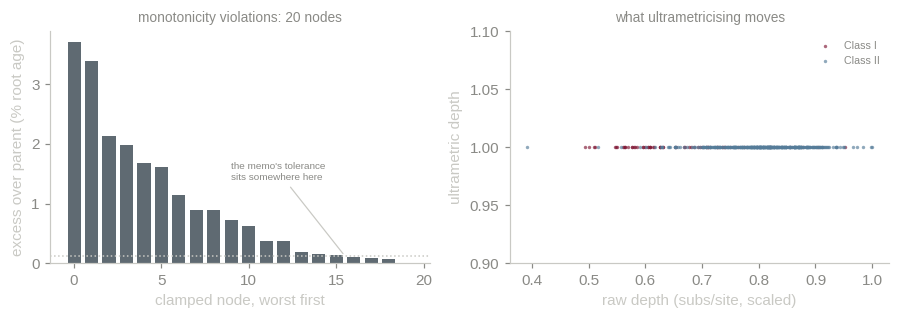

In [59]:
tips = [n.name for n in index["node_1"].leaves()]
depth_raw = {k: raw.t[k] for k in tips}
depth_mpl = {k: mpl.t[k] for k in tips}

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.1, FIGSIZE[1]))

ax = axes[0]
ax.bar(range(len(mpl.clamped)), mpl.clamped.excess_frac_root_age * 100,
       color=COMMON_COL, width=0.75)
ax.axhline(0.12, color=NULL_COL, ls=":", lw=1)
ax.set_xlabel("clamped node, worst first"); ax.set_ylabel("excess over parent (% root age)")
ax.set_title(f"monotonicity violations: {len(mpl.clamped)} nodes", fontsize=9)
ax.annotate("the memo's tolerance\nsits somewhere here", xy=(15.5, 0.12), xytext=(9, 1.4),
            fontsize=6.5, color="#8a8a86",
            arrowprops=dict(arrowstyle="-", color=NULL_COL, lw=0.8))

ax = axes[1]
for cls, col in [("Class_I", CLASS1_COL), ("Class_II", CLASS2_COL)]:
    members = [k for k in tips if leaf_class.get(k) == cls]
    ax.scatter([depth_raw[k] for k in members], [depth_mpl[k] for k in members],
               s=5, color=col, alpha=0.65, lw=0, label=cls.replace("_", " "))
ax.set_xlabel("raw depth (subs/site, scaled)"); ax.set_ylabel("ultrametric depth")
ax.set_ylim(0.9, 1.1); ax.legend(frameon=False, fontsize=7)
ax.set_title("what ultrametricising moves", fontsize=9)

ratio_raw = (np.median([depth_raw[k] for k in tips if leaf_class.get(k) == "Class_II"]) /
             np.median([depth_raw[k] for k in tips if leaf_class.get(k) == "Class_I"]))
ratio_mpl = (np.median([depth_mpl[k] for k in tips if leaf_class.get(k) == "Class_II"]) /
             np.median([depth_mpl[k] for k in tips if leaf_class.get(k) == "Class_I"]))
print(f"Class II / Class I median tip depth: raw {ratio_raw:.3f} -> ultrametric {ratio_mpl:.3f}")

plt.tight_layout(); save_fig(fig, "06_axis_diagnostics"); plt.show()

The plan's second acceptance test — Class II / Class I median tip depth going
**1.29x to 1.00x** — reproduces exactly (1.287 to 1.000). This is the test that
matters most, because it is the one that would catch a wrong MPL implementation,
and it passes. It is also the substance of the correction: Class II tips sit 29%
deeper in substitutions than Class I tips, and if that depth is read as time, Class
II looks old. Ultrametricising says it is fast, not old.

The plan is careful to say this is a bracket rather than a fix (§4.2) — MPL assumes
rate variation averages out, which is the assumption most under strain when the
rate difference is systematic and clade-level, which is precisely this case. Both
axes are therefore drawn together in **The trajectory**.

## The tree

The ultrametric tree is the x axis of every panel that follows, so it is worth
drawing once on its own. Tips are coloured by class; the `node_1` stem, which
belongs to neither class, is grey.

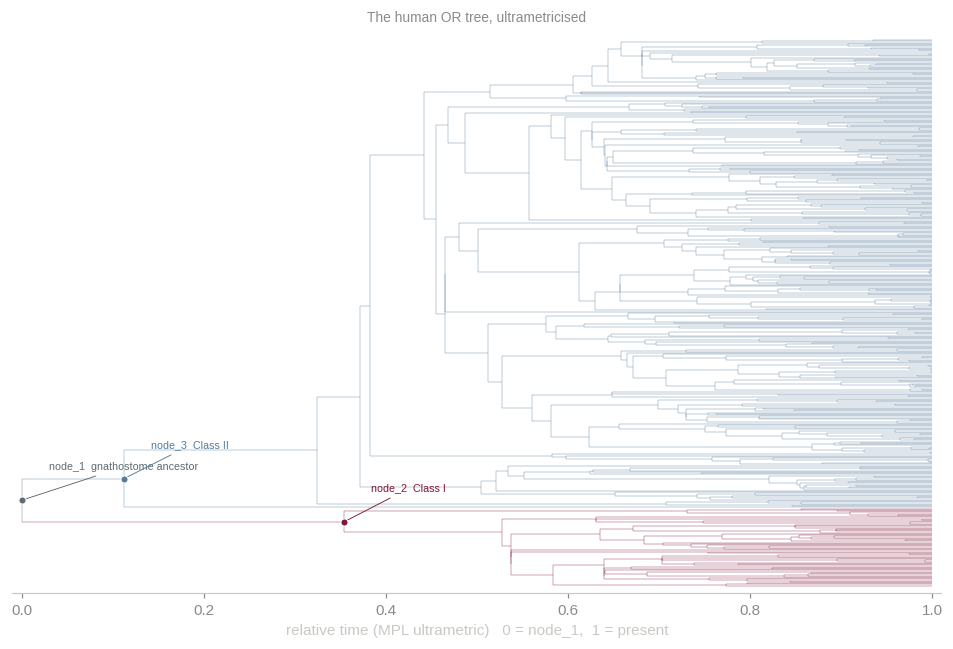

In [60]:
def layout(times, root="node_1"):
    # (x0, x1, y) per node, plus the y-span of each internal node's children
    r = index[root]
    y, order = {}, [n for n in r.leaves()]
    for i, leaf in enumerate(order):
        y[leaf.name] = float(i)
    for n in r.traverse("postorder"):
        if not n.is_leaf:
            y[n.name] = float(np.mean([y[c.name] for c in n.children]))
    seg, vert = {}, {}
    for n in r.traverse():
        x1 = times.t[n.name]
        x0 = 0.0 if n is r else times.t[n.up.name]
        seg[n.name] = (x0, x1, y[n.name])
        if not n.is_leaf:
            vert[n.name] = (x1, min(y[c.name] for c in n.children),
                            max(y[c.name] for c in n.children))
    return seg, vert, y


def draw_tree(ax, times, lw=0.18, root="node_1"):
    seg, vert, y = layout(times, root)
    for name, (x0, x1, yy) in seg.items():
        if name in clades["Class_I"]:
            col = CLASS1_COL
        elif name in clades["Class_II"]:
            col = CLASS2_COL
        else:
            col = COMMON_COL
        ax.plot([x0, x1], [yy, yy], color=col, lw=lw, solid_capstyle="butt")
    for name, (x, lo, hi) in vert.items():
        col = (CLASS1_COL if name in clades["Class_I"] else
               CLASS2_COL if name in clades["Class_II"] else COMMON_COL)
        ax.plot([x, x], [lo, hi], color=col, lw=lw, solid_capstyle="butt")
    ax.set_ylim(-6, len(y and [k for k in y if index[k].is_leaf]) + 6)
    ax.set_yticks([]); ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    return seg, y


fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1] * 2.0))
seg, ypos = draw_tree(ax, mpl, lw=0.25)
for name, label, col in [("node_1", "node_1  gnathostome ancestor", COMMON_COL),
                         ("node_2", "node_2  Class I", CLASS1_COL),
                         ("node_3", "node_3  Class II", CLASS2_COL)]:
    x, yy = mpl.t[name], ypos[name]
    ax.scatter([x], [yy], s=22, color=col, zorder=5, edgecolor="white", lw=0.7)
    ax.annotate(label, xy=(x, yy), xytext=(x + 0.03, yy + 24), fontsize=7, color=col,
                arrowprops=dict(arrowstyle="-", color=col, lw=0.6))
ax.set_xlabel("relative time (MPL ultrametric)   0 = node_1,  1 = present")
ax.set_xlim(-0.01, 1.01)
ax.set_title("The human OR tree, ultrametricised", fontsize=9)
plt.tight_layout(); save_fig(fig, "06_ultrametric_tree"); plt.show()

The 62-tip Class I clade and the 371-tip Class II clade are visible as the two
blocks, and the Class II radiation is visibly denser toward the present. That
density is the thing the trajectory quantifies.

## The trajectory

**The repertoire at time _t_ is the set of lineages crossing _t_.** A branch
leading to `v` occupies the interval `[t(parent(v)), t(v))`, so the lineage crossing
`t` on that branch is `v` — an internal node contributes its ASR row, a tip
contributes its extant row. No ordering is required, which is the whole point.

One wording note for anyone reimplementing from the plan: its rule is given as
"tip v : `t(v) <= t`". Under ultrametricity every tip has `t(v) = 1`, so read
literally no tip ever enters before `t = 1` and the rule is vacuous. The rule that
actually reproduces the plan's own receptor counts is the standard lineages-through-
time slice used here, tips included on the same interval rule. Its numbers are
right; the sentence describing them is not.

In [61]:
traj = trajectory(mpl)
traj_raw = trajectory(raw)
save_table(traj, "06_trajectory")
save_table(traj_raw, "06_trajectory_raw_axis")

checkpoints = [0.0, 0.25, 0.50, 0.75, 0.83, 0.90, 0.96, 1.0]
rows = [traj.iloc[(traj.t - q).abs().argmin()] for q in checkpoints]
view = pd.DataFrame(rows)[["t", "n_class_I", "n_class_II", "n_detected", "cum_detected",
                           "n_single", "n_combinatorial", "only_I", "both", "only_II"]]
print(view.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

     t  n_class_I  n_class_II  n_detected  cum_detected  n_single  n_combinatorial  only_I  both  only_II
     0          0           0          21            21        21                0       0     0        0
0.3246          1           3          40            47        31                9      18     3       19
0.5016          2          13          60            66        30               30      26     6       28
0.7505         26         113         535           536       103              432      21   237      277
0.8304         37         184         651           651        98              553      33   263      355
0.9004         54         251         657           657        88              569      32   318      307
0.9598         56         310         657           657        84              573      32   318      307
     1         62         371         668           671        50              618      15   342      311


Receptor counts reproduce the plan's table: 26 + 112 at *t* = 0.75, 54 + 251 at
0.90 (plan 54 + 254), 62 + 371 at 1.0. The odorant counts sit a few percent below
the plan's throughout, for the reason given in **The endpoint disagreement**.

Now the composite figure. The tree sits on top, and the three panels below share its
x axis, so a feature in a curve can be read straight up to the part of the tree that
produced it.

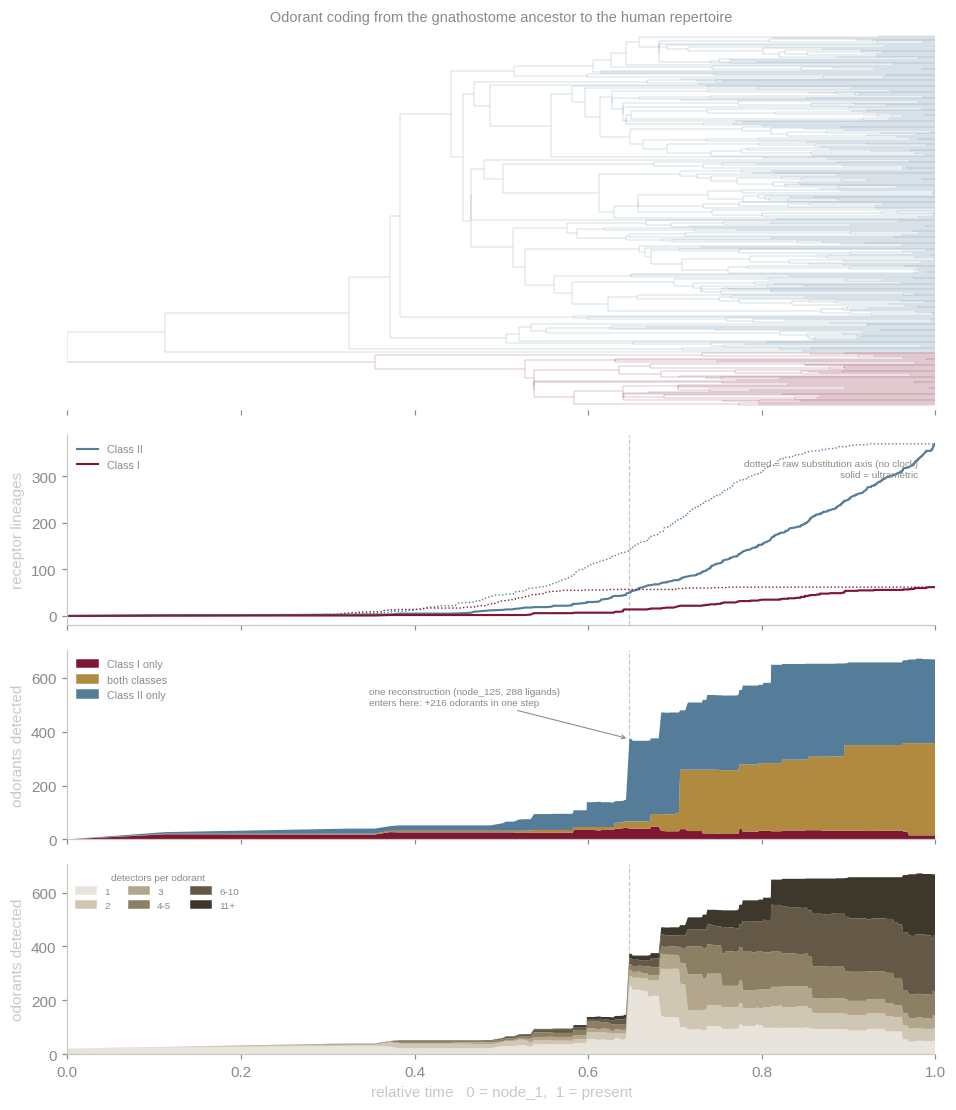

largest single step at t=0.6475: 157 -> 373 odorants


In [62]:
fig, axes = plt.subplots(4, 1, figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1] * 3.4),
                         sharex=True, height_ratios=[2.0, 1.0, 1.0, 1.0])

draw_tree(axes[0], mpl, lw=0.16)
axes[0].set_title("Odorant coding from the gnathostome ancestor to the human repertoire",
                  fontsize=9.5)
axes[0].spines["bottom"].set_visible(False)

# the single step that dominates the figure: one very broad reconstruction
step_i = int(traj.n_detected.diff().abs().idxmax())
step_t = float(traj.t.iloc[step_i])

ax = axes[1]
ax.plot(traj.t, traj.n_class_II, color=CLASS2_COL, lw=1.4, label="Class II")
ax.plot(traj.t, traj.n_class_I, color=CLASS1_COL, lw=1.4, label="Class I")
ax.plot(traj_raw.t, traj_raw.n_class_II, color=CLASS2_COL, lw=0.9, ls=":")
ax.plot(traj_raw.t, traj_raw.n_class_I, color=CLASS1_COL, lw=0.9, ls=":")
ax.set_ylabel("receptor lineages")
ax.legend(frameon=False, fontsize=7, loc="upper left")
ax.annotate("dotted = raw substitution axis (no clock)\nsolid = ultrametric",
            xy=(0.98, 0.78), xycoords="axes fraction", fontsize=6.5, color="#8a8a86",
            ha="right")

ax = axes[2]
ax.stackplot(traj.t, traj.only_I, traj.both, traj.only_II,
             colors=[CLASS1_COL, BOTH_COL, CLASS2_COL], lw=0)
ax.set_ylabel("odorants detected")
ax.legend(handles=[Patch(color=CLASS1_COL, label="Class I only"),
                   Patch(color=BOTH_COL, label="both classes"),
                   Patch(color=CLASS2_COL, label="Class II only")],
          frameon=False, fontsize=7, loc="upper left")
ax.annotate("one reconstruction (node_125, 288 ligands)\nenters here: +216 odorants in one step",
            xy=(step_t, 373), xytext=(step_t - 0.30, 500), fontsize=6.5, color="#8a8a86",
            arrowprops=dict(arrowstyle="->", color="#8a8a86", lw=0.7))

ax = axes[3]
cols = ["det_1", "det_2", "det_3", "det_4_5", "det_6_10", "det_11plus"]
labels = ["1", "2", "3", "4-5", "6-10", "11+"]
shades = ["#e8e4dc", "#cfc6b4", "#b3a68c", "#8d7f64", "#645946", "#3d372c"]
ax.stackplot(traj.t, *[traj[c] for c in cols], colors=shades, lw=0)
ax.set_ylabel("odorants detected")
ax.set_xlabel("relative time   0 = node_1,  1 = present")
ax.legend(handles=[Patch(color=s, label=l) for s, l in zip(shades, labels)],
          frameon=False, fontsize=6.5, loc="upper left", ncol=3, title="detectors per odorant",
          title_fontsize=6.5)
ax.set_xlim(0, 1)

for a in axes[1:]:
    a.axvline(step_t, color=NULL_COL, ls="--", lw=0.8, zorder=0)

plt.tight_layout(); save_fig(fig, "06_trajectory"); plt.show()
print(f"largest single step at t={step_t:.4f}: "
      f"{int(traj.n_detected.iloc[step_i-1])} -> {int(traj.n_detected.iloc[step_i])} odorants")

The bottom panel is the plan's own suggestion (§5) and it is the right call: the
full detector-count distribution says everything the 1-versus-many split says, and
sidesteps the two problems in §4.4 at once. The "single detector" category is soft
— the plan shows the 61 singly-detected odorants sit a median 0.0136 above the cut
against 0.0846 for the combinatorial ones — so a binary split puts a hard line
through the softest part of the data. A distribution does not.

**The step at *t* = 0.65 is not an event.** The single most conspicuous feature of
this figure — the standing repertoire jumping from 157 to 373 odorants — is one
lineage entering the slice: `node_125`, a reconstruction called at 288 ligands
against a median of 6. The three steps after it are the same phenomenon. This is the
plan's §5 warning about hyper-broad rows, and it turns out not to be a footnote but
the dominant term in the figure's shape. Blanking rows above 100 ligands drops the
largest single step from 216 odorants to 56 and the endpoint from 668 to 371 — see
**Sensitivity**. Nothing in the class-level conclusions depends on it, but no
sentence should be written about *when* the code expanded without saying this first.

Reading the class panel: "both classes" grows throughout while "Class I only"
stays a thin band that thins further toward the present. The shared ligand pool is
therefore not an inherited ancestral condition — it is built late, over a Class I
repertoire already in place. That is the plan's §3 claim and it holds here. But see
**Controls**, because a large part of the shape is composition rather than history.

## Standing is not cumulative

One issue the plan does not raise. The slice is a **standing** repertoire: crossing
a node replaces one lineage by its two children, so the union of odorants the slice
detects can *fall* as *t* increases. It is not a growth curve, and "how the code
fills in" reads as though it were.

8 of 412 steps decrease the standing odorant count; largest single drop -7 odorants
standing at t=1: 668   cumulative union over the whole sweep: 671


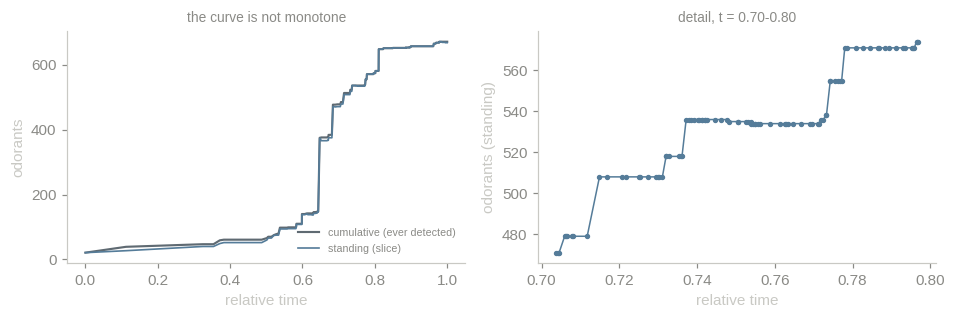

In [63]:
d = np.diff(traj.n_detected.values)
drops = int((d < 0).sum())
print(f"{drops} of {len(d)} steps decrease the standing odorant count; "
      f"largest single drop {int(d.min())} odorants")
print(f"standing at t=1: {int(traj.n_detected.iloc[-1])}   "
      f"cumulative union over the whole sweep: {int(traj.cum_detected.iloc[-1])}")

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1]))

ax = axes[0]
ax.plot(traj.t, traj.cum_detected, color=COMMON_COL, lw=1.4, label="cumulative (ever detected)")
ax.plot(traj.t, traj.n_detected, color=CLASS2_COL, lw=1.1, label="standing (slice)")
ax.set_xlabel("relative time"); ax.set_ylabel("odorants")
ax.legend(frameon=False, fontsize=7, loc="lower right")
ax.set_title("the curve is not monotone", fontsize=9)

ax = axes[1]
window = (traj.t > 0.70) & (traj.t < 0.80)
ax.plot(traj.t[window], traj.n_detected[window], color=CLASS2_COL, lw=1.0, marker="o", ms=2.5)
ax.set_xlabel("relative time"); ax.set_ylabel("odorants (standing)")
ax.set_title("detail, t = 0.70-0.80", fontsize=9)

plt.tight_layout(); save_fig(fig, "06_standing_vs_cumulative"); plt.show()

This has a practical consequence for the plan's headline table, which reports
intermediate odorant counts as exact integers (549, 650, 660, 678). Those numbers
are not stable to a small shift in where the checkpoint falls, because a single
hyper-broad lineage entering or leaving the slice moves the count by tens. The
right presentation is the curve with its jitter visible — as above — not four
significant figures in a table.

Report the shape. The endpoints (`node_1` at 21 odorants, the extant repertoire at
668) are solid because they are not slices of anything; the intermediate values are
an estimator with real variance.

## Founder ligands

The plan tracks classes. It does not track what happened to the ancestor's own
repertoire, which is the more direct reading of "how the code evolved": of the 21
odorants `node_1` is reconstructed to bind, what becomes of them?

The answer to the obvious version of that question is degenerate — all 21 are still
detected at the present, by both classes, none lost. So the quantity worth plotting
is not *whether* they survive but *how many receptors pile onto them*.

node_1 binds 21 odorants


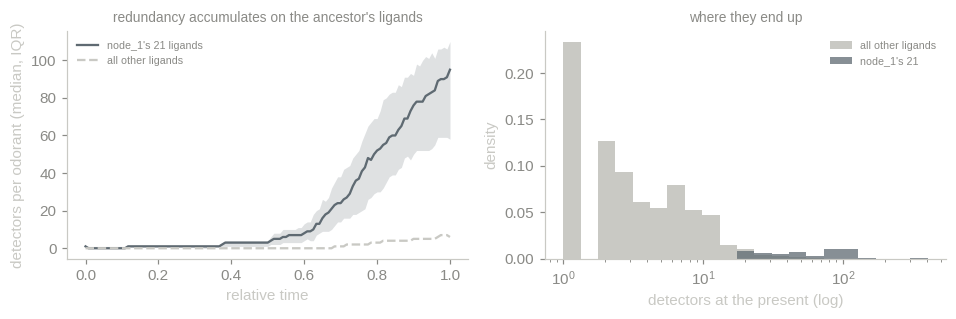

median detectors at the present: founders 95, others 6
founder ligands still detected at the present: 21 of 21


In [64]:
founders = list(binary.columns[binary.loc["node_1"].values])
others = [c for c in binary.columns if c not in founders]
print(f"node_1 binds {len(founders)} odorants")

grid = np.linspace(0, 1, 121)
keep = []
for when in grid:
    members = [m for m in lineage_slice(mpl, float(when)) if m in binary.index]
    block = binary.loc[members]
    det_f = block[founders].values.sum(0)
    det_o = block[others].values.sum(0)
    keep.append({"t": when, "n_lineages": len(members),
                 "founder_median": float(np.median(det_f)),
                 "founder_lo": float(np.percentile(det_f, 25)),
                 "founder_hi": float(np.percentile(det_f, 75)),
                 "other_median": float(np.median(det_o)),
                 "founder_still_detected": int((det_f > 0).sum())})
founder_traj = pd.DataFrame(keep)
save_table(founder_traj, "06_founder_ligands")

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1]))

ax = axes[0]
ax.fill_between(founder_traj.t, founder_traj.founder_lo, founder_traj.founder_hi,
                color=COMMON_COL, alpha=0.20, lw=0)
ax.plot(founder_traj.t, founder_traj.founder_median, color=COMMON_COL, lw=1.5,
        label="node_1's 21 ligands")
ax.plot(founder_traj.t, founder_traj.other_median, color=NULL_COL, lw=1.5, ls="--",
        label="all other ligands")
ax.set_xlabel("relative time"); ax.set_ylabel("detectors per odorant (median, IQR)")
ax.legend(frameon=False, fontsize=7, loc="upper left")
ax.set_title("redundancy accumulates on the ancestor's ligands", fontsize=9)

ax = axes[1]
det_f = binary.loc[extant_I + extant_II, founders].values.sum(0)
det_o = binary.loc[extant_I + extant_II, others].values.sum(0)
edges = np.logspace(0, np.log10(max(det_f.max(), det_o.max()) + 1), 22)
ax.hist(det_o, bins=edges, color=NULL_COL, label="all other ligands", density=True)
ax.hist(det_f, bins=edges, color=COMMON_COL, alpha=0.75, label="node_1's 21", density=True)
ax.set_xscale("log"); ax.set_xlabel("detectors at the present (log)")
ax.set_ylabel("density"); ax.legend(frameon=False, fontsize=7)
ax.set_title("where they end up", fontsize=9)

plt.tight_layout(); save_fig(fig, "06_founder_ligands"); plt.show()

print(f"median detectors at the present: founders {int(np.median(det_f))}, "
      f"others {int(np.median(det_o))}")
print(f"founder ligands still detected at the present: "
      f"{int(founder_traj.founder_still_detected.iloc[-1])} of {len(founders)}")

The ancestor's 21 ligands end up among the most redundantly encoded odorants in the
repertoire — a median of 95 detectors against 7 for everything else — and not one is
lost. The code does not move off its ancestral ligands; it piles receptors onto them
while adding new ones around them.

**This needs a caveat in any legend, because it is partly circular.** `node_1`'s
repertoire is the top of its own predicted score row, and if the model scores
intrinsically promiscuous odorants highly for every sequence, the ancestor's ligands
would be the broadly-detected ones whatever the tree did. The defensible version is
conditional: *given* the reconstruction, ancestral ligands are the redundancy core.
Separating that from a model artefact needs the odorant-level score distribution as
a null — worth doing before this panel carries any weight, and not done here.

## Controls

Three nulls. The first two are the plan's, the third tightens one of them.

**Ordering (§4.1)** — the reason the axis is time. Resolve the same topology in 200
random orders and read "Class I only" at twenty receptors.

**Composition (§4.3)** — the plan's most important caveat. Draw receptors at random
from the extant matrix in the class ratio the slice actually has at each *t*, with
no tree at all. If that reproduces the curve, the shape is the class ratio shifting
and not history.

**Independence (§4.4)** — combinatoriality is arithmetically forced at this density.
With receptors independent at their observed breadths, what fraction of detected
odorants would have two or more detectors anyway?

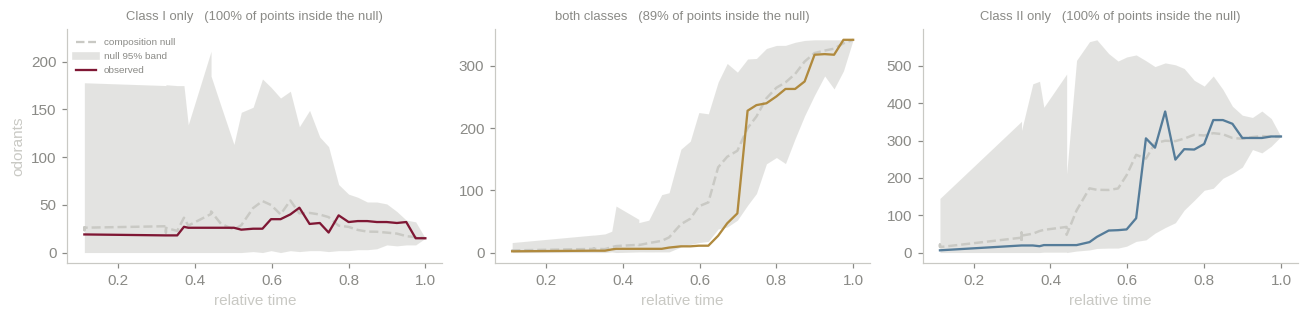

only_I    observed inside the null's 95% band at 100% of time points
both      observed inside the null's 95% band at 89% of time points
only_II   observed inside the null's 95% band at 100% of time points


In [65]:
MI_all, MII_all = binary.loc[extant_I].values, binary.loc[extant_II].values

# --- composition null, matched to the slice's class ratio at each t ---
coarse = np.linspace(0.02, 1.0, 40)
N_DRAW = 200
comp = []
for when in coarse:
    row = traj.iloc[(traj.t - when).abs().argmin()]
    kI, kII = int(row.n_class_I), int(row.n_class_II)
    if kI == 0 and kII == 0:
        continue
    oi, bo, oii = [], [], []
    for _ in range(N_DRAW):
        a = MI_all[RNG.choice(len(MI_all), min(kI, len(MI_all)), replace=False)].sum(0) > 0 \
            if kI else np.zeros(MI_all.shape[1], bool)
        b = MII_all[RNG.choice(len(MII_all), min(kII, len(MII_all)), replace=False)].sum(0) > 0 \
            if kII else np.zeros(MII_all.shape[1], bool)
        oi.append((a & ~b).sum()); bo.append((a & b).sum()); oii.append((~a & b).sum())
    entry = {"t": float(row.t), "n_I": kI, "n_II": kII,
             "only_I_obs": float(row.only_I), "both_obs": float(row.both),
             "only_II_obs": float(row.only_II)}
    for key, draws in [("only_I", oi), ("both", bo), ("only_II", oii)]:
        entry[f"{key}_null"] = np.mean(draws)
        entry[f"{key}_lo"] = np.percentile(draws, 2.5)
        entry[f"{key}_hi"] = np.percentile(draws, 97.5)
        entry[f"{key}_inside"] = bool(np.percentile(draws, 2.5) <= entry[f"{key}_obs"]
                                      <= np.percentile(draws, 97.5))
    comp.append(entry)
comp = pd.DataFrame(comp)
save_table(comp, "06_composition_null")

fig, axes = plt.subplots(1, 3, figsize=(FIGSIZE[0] * 3.0, FIGSIZE[1]))
for ax, key, col, name in [(axes[0], "only_I", CLASS1_COL, "Class I only"),
                           (axes[1], "both", BOTH_COL, "both classes"),
                           (axes[2], "only_II", CLASS2_COL, "Class II only")]:
    ax.fill_between(comp.t, comp[f"{key}_lo"], comp[f"{key}_hi"],
                    color=NULL_COL, alpha=0.5, lw=0)
    ax.plot(comp.t, comp[f"{key}_null"], color=NULL_COL, lw=1.6, ls="--")
    ax.plot(comp.t, comp[f"{key}_obs"], color=col, lw=1.5)
    inside = comp[f"{key}_inside"].mean()
    ax.set_xlabel("relative time")
    ax.set_title(f"{name}   ({inside:.0%} of points inside the null)", fontsize=8.5)
axes[0].set_ylabel("odorants")
axes[0].legend(handles=[Line2D([], [], color=NULL_COL, ls="--", label="composition null"),
                        Line2D([], [], color=NULL_COL, lw=5, alpha=0.5, label="null 95% band"),
                        Line2D([], [], color=CLASS1_COL, label="observed")],
               frameon=False, fontsize=6.5, loc="upper left")
plt.tight_layout(); save_fig(fig, "06_composition_null"); plt.show()

for key in ["only_I", "both", "only_II"]:
    print(f"{key:9s} observed inside the null's 95% band at "
          f"{comp[f'{key}_inside'].mean():.0%} of time points")

'Class I only' at ~20 lineages across 200 random resolution orders: [13, 267]  median 59
the tree's own slice nearest 20 lineages (t=0.527): only_I = 24, Class I share of receptors = 0.10
same on the raw axis (t=0.373): Class I share = 0.65


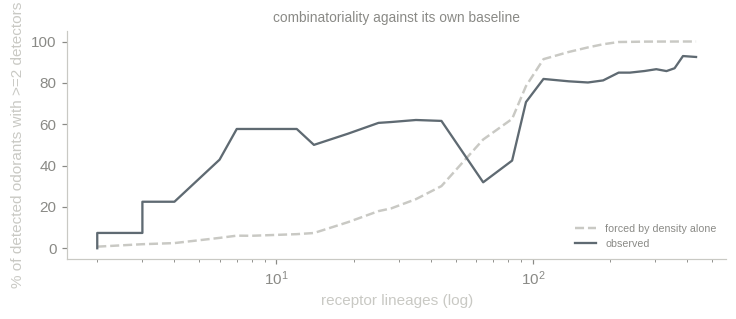

observed exceeds the forced baseline up to 44 lineages, and stays below it thereafter
  at  94 lineages: forced 78.4%, observed 70.7%
  at 433 lineages: forced 100.0%, observed 92.5%


In [66]:
# --- ordering null (memo 4.1): random resolution orders on the SAME topology ---
# Start from node_1 and repeatedly expand a randomly chosen unresolved lineage.
# Every order is consistent with the tree; only the sequence of splits varies.
K = 20
spans = []
for _ in range(200):
    live = ["node_1"]
    while len(live) < K:
        internal = [i for i, m in enumerate(live) if not index[m].is_leaf]
        if not internal:
            break
        pick = live.pop(int(RNG.choice(internal)))
        live.extend(c.name for c in index[pick].children)
    members = [m for m in live if m in binary.index]
    in_i = [m for m in members if m in clades["Class_I"]]
    in_ii = [m for m in members if m in clades["Class_II"]]
    av = binary.loc[in_i].values.sum(0) > 0 if in_i else np.zeros(binary.shape[1], bool)
    bv = binary.loc[in_ii].values.sum(0) > 0 if in_ii else np.zeros(binary.shape[1], bool)
    spans.append(int((av & ~bv).sum()))
print(f"'Class I only' at ~{K} lineages across 200 random resolution orders: "
      f"[{min(spans)}, {max(spans)}]  median {int(np.median(spans))}")

row20 = traj.iloc[(traj.n_lineages - K).abs().argmin()]
print(f"the tree's own slice nearest {K} lineages (t={row20.t:.3f}): "
      f"only_I = {int(row20.only_I)}, Class I share of receptors = "
      f"{row20.n_class_I / max(row20.n_lineages, 1):.2f}")
raw20 = traj_raw.iloc[(traj_raw.n_lineages - K).abs().argmin()]
print(f"same on the raw axis (t={raw20.t:.3f}): Class I share = "
      f"{raw20.n_class_I / max(raw20.n_lineages, 1):.2f}")

# --- independence null (memo 4.4) ---
def forced_combinatorial(rows):
    p = binary.loc[rows].values.mean(axis=1)          # each receptor's breadth as a rate
    none = np.prod(1 - p)
    exactly_one = sum(pi / (1 - pi) for pi in p if pi < 1) * none
    detected = 1 - none
    return (detected - exactly_one) / detected if detected > 0 else np.nan

ind = []
for when in coarse:
    members = [m for m in lineage_slice(mpl, float(when)) if m in binary.index]
    row = traj.iloc[(traj.t - when).abs().argmin()]
    obs = row.n_combinatorial / row.n_detected if row.n_detected else np.nan
    ind.append({"t": float(row.t), "n": len(members),
                "observed": obs, "forced": forced_combinatorial(members)})
ind = pd.DataFrame(ind)
save_table(ind, "06_independence_null")

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.7, FIGSIZE[1]))
ax.plot(ind.n, ind.forced * 100, color=NULL_COL, lw=1.6, ls="--", label="forced by density alone")
ax.plot(ind.n, ind.observed * 100, color=COMMON_COL, lw=1.5, label="observed")
ax.set_xscale("log"); ax.set_xlabel("receptor lineages (log)")
ax.set_ylabel("% of detected odorants with >=2 detectors")
ax.legend(frameon=False, fontsize=7, loc="lower right")
ax.set_title("combinatoriality against its own baseline", fontsize=9)
plt.tight_layout(); save_fig(fig, "06_independence_null"); plt.show()

above = ind[(ind.observed >= ind.forced) & (ind.n > 3)]
if len(above):
    print(f"observed exceeds the forced baseline up to {int(above.n.max())} lineages, "
          f"and stays below it thereafter")
for target in [100, 433]:
    r = ind.iloc[(ind.n - target).abs().argmin()]
    print(f"  at {int(r.n):>3} lineages: forced {r.forced:.1%}, observed {r.observed:.1%}")

The ordering null lands where the plan says it does. "Class I only" at twenty
lineages spans [13, 267] across 200 resolution orders of the *same tree* — a range
covering almost the entire achievable scale — against 24 for the tree's own slice at
that size. Repertoire size is not an axis; it is a free parameter dressed as one.

The composition null does not merely bite — it removes the claim. The observed
curves sit inside the null's 95% band at nearly every time point in all three
panels. Drawing receptors at random from the extant matrix, in nothing but the class
ratio the slice happens to have, reproduces the whole shape: the thin "Class I only"
band, its rise and fall, and the late build-up of "both classes".

This is worth stating more sharply than the plan does. Its §3 conclusion — that the
shared ligand pool "is not an inherited ancestral condition but something the Class
II radiation builds over a Class I repertoire already in place" — is true as a
description of the curve, but the curve is what you get from *any* 62-and-371 mix of
these receptors, tree or no tree. "Built late" is a restatement of the fact that most
receptors arrive late. **Any evolutionary sentence about these panels has to be a
sentence about the residual between the coloured line and the dashed one, and here
that residual is not distinguishable from zero.**

What does survive is the receptor-count panel, which is not a composition result:
the class ratio *itself* changing over time is the finding, and the odorant panels
are its consequence rather than independent evidence.

The independence panel makes the plan's §4.4 point visually: past roughly 50
receptors the real code is *less* combinatorial than independent receptors at the
same breadths would be. A rising %-combinatorial curve is therefore not evidence of
a code becoming combinatorial — it is arithmetic. What is interesting is the
opposite, that the real code stays under the forced baseline, which is a hint of
structure that resists it.

## Sensitivity

Two checks. First the hyper-broad rows the plan flags in §5: breadth is median 4
but reaches into the hundreds, and a couple of very broad reconstructions can
dominate the odorant counts wherever they sit in the sweep.

breadth, all 865 rows: median 6, max 572, 29 above 100
breadth, extant only:      median 4, max 572   (the memo quotes median 4, max 539)
9606.Q9Y3N9    572
9606.O76001    543
9606.P34982    458
9606.P47890    402
node_314       390


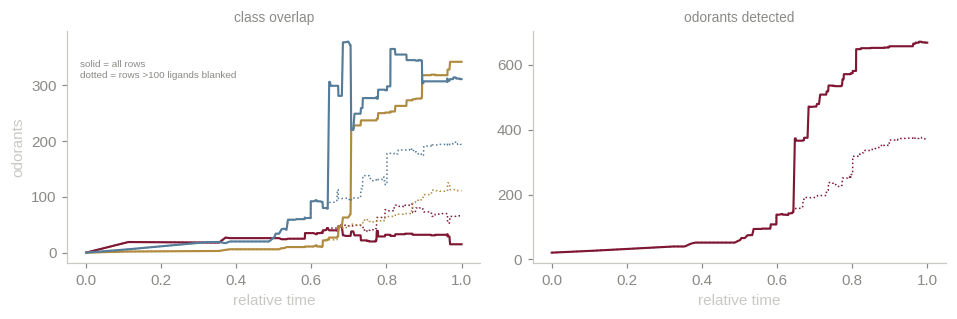

all rows       largest single step  216 odorants (t=0.647), endpoint 668
blanked >100   largest single step   56 odorants (t=0.802), endpoint 371


In [67]:
breadth = binary.sum(axis=1)
extant_breadth = breadth.loc[extant_I + extant_II]
print(f"breadth, all {len(breadth)} rows: median {int(breadth.median())}, "
      f"max {int(breadth.max())}, {int((breadth > 100).sum())} above 100")
print(f"breadth, extant only:      median {int(extant_breadth.median())}, "
      f"max {int(extant_breadth.max())}   (the memo quotes median 4, max 539)")
print(breadth.sort_values(ascending=False).head(5).to_string())

traj_blank = trajectory(mpl, blank_above=100)
save_table(traj_blank, "06_trajectory_blanked")

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1]))
for ax, cols, title in [(axes[0], ["only_I", "both", "only_II"], "class overlap"),
                        (axes[1], ["n_detected"], "odorants detected")]:
    for c, col in zip(cols, [CLASS1_COL, BOTH_COL, CLASS2_COL]):
        ax.plot(traj.t, traj[c], color=col, lw=1.4)
        ax.plot(traj_blank.t, traj_blank[c], color=col, lw=1.0, ls=":")
    ax.set_xlabel("relative time"); ax.set_title(title, fontsize=9)
axes[0].set_ylabel("odorants")
axes[0].annotate("solid = all rows\ndotted = rows >100 ligands blanked",
                 xy=(0.03, 0.80), xycoords="axes fraction", fontsize=6.5, color="#8a8a86")
plt.tight_layout(); save_fig(fig, "06_sensitivity_broad"); plt.show()

for nm, df in [("all rows", traj), ("blanked >100", traj_blank)]:
    d = df.n_detected.diff().abs()
    print(f"{nm:14s} largest single step {int(d.max()):>4} odorants "
          f"(t={df.t[d.idxmax()]:.3f}), endpoint {int(df.n_detected.iloc[-1])}")

Blanking is not a cosmetic sensitivity here. It removes 29 of 865 rows — 3% — and
takes 45% of the odorants with them (668 to 371), because a row calling 288 or 572
ligands contributes almost the whole ligand set on its own. The class-level shape
survives, which is the plan's claim and it holds; the absolute odorant counts do
not survive in any form, and should not be quoted without the blanked figure beside
them.

Whether those rows are real is a separate question this notebook cannot answer.
A reconstruction called at 572 of 754 ligands is either a genuinely promiscuous
receptor or a low-confidence ancestral sequence whose scores are flat enough that
the density fill takes the top 76% of its row. Distinguishing the two needs the ASR
posterior probabilities per site, which are available in the reconstruction output
and are not used anywhere in this folder. That is the most useful next step for this
analysis, more so than any additional panel.

### The endpoint disagreement

The plan's third acceptance test — "the final point reproduces 17 / 370 / 300
exactly" — does not reproduce here. This folder gets **15 / 342 / 311**, with 668
odorants detected rather than 687 and 50 singly-detected rather than 61.

The cause is not the tree, the class assignment or the matrix. It is the
**experimental overlay**. The plan's numbers come from an extant fill with the
23,782 measured human pairs overlaid on the predictions; this folder fills with no
overlay anywhere. Substituting the overlay reproduces the plan's numbers to the
digit — including its extant cut of 0.8917, which is the overlay cut, where the
no-overlay cut is 0.8947.

The next cell shows both.

In [68]:
from calibration import density_fill, reference_calibration_map
from ancestral_sets import ASR_MATRIX, REF_MATRIX, PAIRS, FASTA

asr_raw = pd.read_csv(ASR_MATRIX, index_col=0)
asr_raw.index = [str(i).replace("_ASR", "") for i in asr_raw.index]
ref_raw = pd.read_csv(REF_MATRIX, index_col=0)
ref_raw = ref_raw[[str(i).startswith("9606") for i in ref_raw.index]]
ligand_cols = [c for c in asr_raw.columns if c.startswith("SML") and c in ref_raw.columns]
ref_raw = ref_raw[ligand_cols]

seqs, pid, buf = {}, None, []
for line in open(FASTA):
    line = line.rstrip()
    if line.startswith(">"):
        if pid:
            seqs[pid] = "".join(buf).upper()
        pid, buf = line[1:].split()[0], []
    else:
        buf.append(line)
if pid:
    seqs[pid] = "".join(buf).upper()

seq_to_pid = {}
for p in ref_raw.index:
    seq_to_pid.setdefault(seqs[p], p)
pairs = pd.read_csv(PAIRS, usecols=["Species", "Sequence", "Responsive", "smiles_id"])
hp = pairs[pairs.Species.str.lower().str.contains("homo")].copy()
hp["Sequence"] = hp.Sequence.str.upper().str.strip()
hp["pid"] = hp.Sequence.map(seq_to_pid)
meas = (hp[hp.pid.notna() & hp.smiles_id.isin(ligand_cols)]
        .groupby(["pid", "smiles_id"]).Responsive.max())

ri = {p: i for i, p in enumerate(ref_raw.index)}
ci = {c: j for j, c in enumerate(ligand_cols)}
mask = np.zeros(ref_raw.shape, bool); exper = np.zeros(ref_raw.shape, float)
for (p, s), v in meas.items():
    mask[ri[p], ci[s]] = True; exper[ri[p], ci[s]] = v
print(f"{len(meas)} measured cells, {int(meas.sum())} positive")

iso = reference_calibration_map(REF_MATRIX, PAIRS, FASTA)
summary = []
for label, kw in [("no overlay (this folder)", dict(tested_mask=None)),
                  ("with overlay (the memo)", dict(tested_mask=mask, experimental=exper))]:
    r = density_fill(ref_raw.values, iso, **kw)
    B = pd.DataFrame(r.matrix.astype(bool), index=ref_raw.index, columns=ligand_cols)
    a = B.loc[extant_I].values.sum(0) > 0
    b = B.loc[extant_II].values.sum(0) > 0
    det = B.values.sum(0)
    summary.append({"fill": label, "cut": round(r.cut, 4), "density": f"{r.density:.4%}",
                    "only_I": int((a & ~b).sum()), "both": int((a & b).sum()),
                    "only_II": int((~a & b).sum()), "detected": int((det > 0).sum()),
                    "single": int((det == 1).sum()), "combinatorial": int((det >= 2).sum())})
summary = pd.DataFrame(summary)
save_table(summary, "06_endpoint_overlay")
print(summary.to_string(index=False))

23782 measured cells, 1128 positive


                    fill    cut density  only_I  both  only_II  detected  single  combinatorial
no overlay (this folder) 0.8947 2.7453%      15   342      311       668      50            618
 with overlay (the memo) 0.8917 2.7453%      17   370      300       687      61            626


Both fills are legitimate; they answer different questions. But only one of them is
usable *here*, and it is not the plan's.

An ancestor cannot have measurements. Overlaying them on the extant rows alone
therefore puts a systematic data-source discontinuity on every ancestor-to-tip edge
of the tree — and this trajectory crosses all 433 of those edges at once, at *t* = 1,
which is exactly where the headline number 17 / 370 / 300 is read. Part of the final
step in the plan's curves is not evolution over the terminal branches; it is
measurements switching on. The effect is not large — 19 odorants, 2.8% — but it
is systematic, it points one way, and 11 of those 19 land in the single-detector
category that §4.4 already identifies as the softest in the analysis.

So: **the plan's acceptance test cannot be satisfied without adopting a binarisation
that is internally inconsistent with the analysis it is testing.** The
recommendation is to keep the no-overlay fill throughout, report 15 / 342 / 311 as
the endpoint, and cite the overlay figures as the sensitivity — the direction this
notebook takes.

That also disposes of the plan's §6 triage. Of its three checks, (2) is the one that
would catch a wrong MPL implementation and it passes cleanly; (1) is not
reproducible as stated because its tolerance is unstated; and (3) cannot pass
without changing the binarisation. Check (2) should be the gate.

## Summary

What survives, in descending order of how much weight it will carry:

1. **The duplication asymmetry is real and is the safest claim here.** Class I
   flattens near 62 lineages while Class II keeps expanding, on both the ultrametric
   and the raw axis. It does not depend on the clock assumption, the threshold, or
   the overlay.
2. **The class-overlap panel does not carry independent evidence.** "Both classes"
   grows late and "Class I only" stays thin, but the composition null reproduces
   both inside its 95% band at nearly every time point. The odorant panels are a
   consequence of the changing class ratio, not a second finding about it. This is
   a stronger negative than the plan states, and it should change how the panel is
   captioned.
3. **Timing is bracketed, not measured.** Class I's share at twenty receptors moves
   substantially between the two axes. Report the shape.
4. **The rise in combinatoriality is arithmetic.** Past ~50 receptors the real code
   is less combinatorial than chance at the same density. Plot the detector-count
   distribution, not the binary split.
5. **The curve is an estimator with variance.** Standing repertoire is non-monotone
   and intermediate counts jitter by tens; endpoints are solid, the middle is not.
6. **Absolute odorant counts are carried by 29 hyper-broad rows.** Blanking 3% of
   rows removes 45% of the odorants and flattens the largest step from 216 to 56.
   Quote class-level shape; do not quote odorant totals without the blanked figure.

Two things this notebook changes about how the analysis should be reported. The
endpoint should be 15 / 342 / 311, not 17 / 370 / 300, because the latter needs an
extant-only experimental overlay that the trajectory itself cannot support. And the
plan's acceptance test (3) should be retired in favour of test (2), which is the one
that actually validates the axis.

The single most useful next step is not another panel: it is bringing the ASR
per-site posterior probabilities into the binarisation, so that a reconstruction
called at 288 ligands can be distinguished from a confident one called at 6.

The plan's own §5 closing point stands and is worth repeating in any legend: the
version of this analysis that would actually narrow the timing bracket needs
taxonomic gain/loss mapping across many vertebrate genomes, not a human-only tree.
This notebook is the human-only version, with its limits drawn rather than described.

# When the combinatorial code appeared

Two figures rebuilt here so that they come out of this repository's own code and
binarisation.

| | question |
|---|---|
| **1 · The first three stages** | at one, two and three receptors, how many odorants are read by more than one of them? |
| **2 · The trajectory** | the same question across the whole tree, from `node_1` to the 433 human receptors |

The claim both support: **a combinatorial code appears at the very first duplication and
grows at every one after it, with no selection required.** One receptor cannot produce a
combinatorial code; two can, and immediately do.

## One difference from `06`, and it matters

Part 4 above runs with **no experimental overlay** — every cell, ancestral and
extant, is a prediction. That is deliberate there: overlaying measurements on the extant
tips only would put a data-source discontinuity on every ancestor-to-tip edge.

The plan's figures use the **overlay**: measured M2OR values are written over the extant
rows. That is why its endpoint is 687 odorants and `06`'s is 668. Both are in
`Tables/06_endpoint_overlay.csv`.

**This notebook uses the overlay**, so that it reproduces the published figures. Ancestral
rows are unaffected either way — a reconstructed sequence has no measurements. The
difference lives entirely in the extant endpoint, and the discontinuity `06` avoids is
real, so prefer `06`'s numbers for any ancestor-to-tip comparison.

In [69]:
import sys
sys.path.append("../../scripts")
sys.path.append("../../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import (ASR_MATRIX, REF_MATRIX, PAIRS, FASTA, CLASSES,
                            density_grid, mpl_times, raw_times, trajectory,
                            save_fig, save_table)
from calibration import density_fill, reference_calibration_map

plt.rcParams.update(custom_plots())

# The folder palette, identical to 01-06 so a class keeps one colour everywhere.
COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"

# Odorants both classes detect, and the "read by exactly one receptor" bar: the same
# light grey, because in both cases it is the neutral band the two classes sit either
# side of.
BOTH_COL = SINGLE_BAR = "#c9c9c4"
# Read by >=2 receptors. BOTH_COL's gold from 06, reused because it carries the same
# meaning here -- detected by more than one thing.
COMB_COL = "#b08a3e"
TOTAL_COL, SINGLE_LINE = "#3a3a38", COMMON_COL

_, _, fills, _ = density_grid()
ASR_CUT = fills["asr"].cut

classes = pd.read_csv(CLASSES)
leaf_class = dict(zip(classes.leaf_id, classes.OR_class))

print(f"ASR density cut {ASR_CUT:.4f}   (the calibrated cut for reconstructed nodes)")

ASR density cut 0.8875   (the calibrated cut for reconstructed nodes)


## 1 · The first three stages

Three snapshots of the earliest repertoire:

| stage | receptors | what it is |
|---|---|---|
| **S0** | `node_1` | the single gnathostome OR ancestor |
| **S1** | `node_2`, `node_3` | after the first duplication — the two class ancestors |
| **S2** | `node_4`, `node_5`, `node_6` | after the next two |

For each, count the odorants **detected** (bound by ≥ 1 receptor of the stage) and split
them into **labelled line** (exactly one receptor) and **combinatorial** (two or more).

Shown at two cuts. The raw `p ≥ 0.5` panel is the model default and over-calls badly — it
is here because the plan shows it, and because the *pattern* is the point: the fraction
rises the same way under either cut, so it is not an artefact of where the line is drawn.
`p ≥ 0.8875` is this folder's calibrated cut, and those are the numbers to quote.

> Stage 2 is reported as {`node_4`, `node_5`, `node_6`}. OR2AT4's placement sits on a very
> long branch next to the outgroup, which is long-branch-attraction geometry that
> bootstrapping cannot detect; the plan carries a 4-way version as a sensitivity.

In [70]:
STAGES = {"S0": ["node_1"],
          "S1": ["node_2", "node_3"],
          "S2": ["node_4", "node_5", "node_6"]}
STAGE_LABEL = {"S0": "1 receptor\n(node_1)",
               "S1": "2 receptors\n(node_2, node_3)",
               "S2": "3 receptors\n(node_4/5/6)"}

asr = pd.read_csv(ASR_MATRIX, index_col=0)
asr.index = [str(i).replace("_ASR", "") for i in asr.index]
lig = [c for c in asr.columns if c.startswith("SML")]

rows = []
for panel, cut in [("raw", 0.5), ("calibrated", ASR_CUT)]:
    for stage, nodes in STAGES.items():
        detectors = (asr.loc[nodes, lig].values > cut).sum(axis=0)
        encoded = int((detectors > 0).sum())
        single = int((detectors == 1).sum())
        comb = int((detectors >= 2).sum())
        rows.append({"panel": panel, "cut": round(cut, 4), "stage": stage,
                     "n_receptors": len(nodes), "encoded": encoded,
                     "labelled_line": single, "combinatorial": comb,
                     "pct_combinatorial": round(100 * comb / encoded, 1) if encoded else 0.0})

stages = pd.DataFrame(rows)
save_table(stages, "07_stages")
stages

,panel,cut,stage,n_receptors,encoded,labelled_line,combinatorial,pct_combinatorial
0,raw,0.5000,S0,1,177,177,0,0.0
1,raw,0.5000,S1,2,216,189,27,12.5
2,raw,0.5000,S2,3,265,133,132,49.8
3,calibrated,0.8875,S0,1,21,21,0,0.0
4,calibrated,0.8875,S1,2,27,25,2,7.4
5,calibrated,0.8875,S2,3,53,36,17,32.1


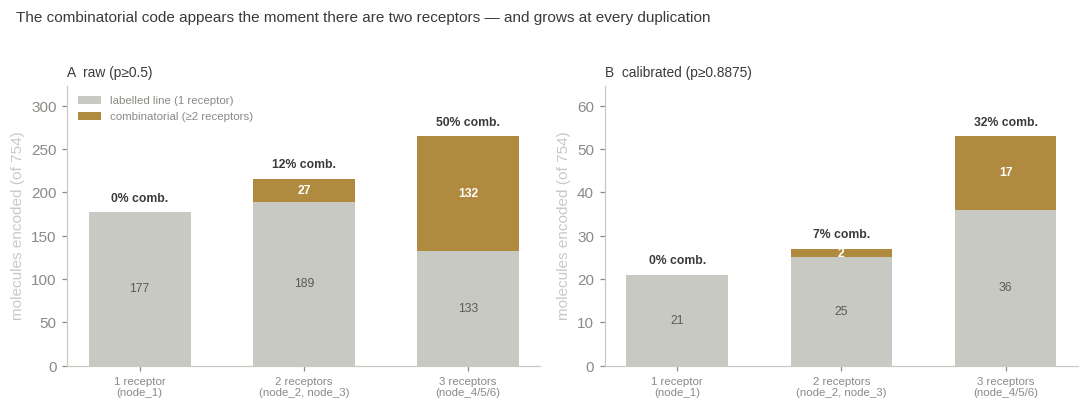

S0  1 receptor(s):  21 encoded,  21 by one,   0 by ≥2  (0.0% combinatorial)
S1  2 receptor(s):  27 encoded,  25 by one,   2 by ≥2  (7.4% combinatorial)
S2  3 receptor(s):  53 encoded,  36 by one,  17 by ≥2  (32.1% combinatorial)


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.5, FIGSIZE[1] * 1.2))
fig.suptitle("The combinatorial code appears the moment there are two receptors "
             "— and grows at every duplication",
             fontsize=10, color="#3a3a38", x=0.02, ha="left", y=1.02)

for ax, (panel, title) in zip(axes, [("raw", "A  raw (p≥0.5)"),
                                     ("calibrated", f"B  calibrated (p≥{ASR_CUT:.4f})")]):
    block = stages[stages.panel == panel].set_index("stage").loc[list(STAGES)]
    x = np.arange(len(block))

    ax.bar(x, block.labelled_line, width=0.62, color=SINGLE_BAR,
           label="labelled line (1 receptor)")
    ax.bar(x, block.combinatorial, bottom=block.labelled_line, width=0.62,
           color=COMB_COL, label="combinatorial (≥2 receptors)")

    for i, r in enumerate(block.itertuples()):
        if r.labelled_line:
            # dark text: the grey bar is too light to carry white
            ax.text(i, r.labelled_line / 2, f"{r.labelled_line}", ha="center", va="center",
                    fontsize=8, color="#5a5a57")
        if r.combinatorial:
            ax.text(i, r.labelled_line + r.combinatorial / 2, f"{r.combinatorial}",
                    ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        ax.text(i, r.encoded + block.encoded.max() * 0.035,
                f"{r.pct_combinatorial:.0f}% comb." if r.pct_combinatorial else "0% comb.",
                ha="center", va="bottom", fontsize=8, fontweight="bold", color="#3a3a38")

    ax.set_xticks(x)
    ax.set_xticklabels([STAGE_LABEL[s] for s in block.index], fontsize=7.5)
    ax.set_ylabel("molecules encoded (of 754)")
    ax.set_ylim(0, block.encoded.max() * 1.22)
    ax.set_title(title, fontsize=9, loc="left", color="#3a3a38")

axes[0].legend(frameon=False, fontsize=7.5, loc="upper left")
plt.tight_layout()
save_fig(fig, "07_stages")
plt.show()

for r in stages[stages.panel == "calibrated"].itertuples():
    print(f"{r.stage}  {r.n_receptors} receptor(s): {r.encoded:>3} encoded, "
          f"{r.labelled_line:>3} by one, {r.combinatorial:>3} by ≥2  "
          f"({r.pct_combinatorial}% combinatorial)")

## 2 · The trajectory, `node_1` to the human repertoire

The same question across the whole tree. The x axis is **relative time** on the
mean-path-length ultrametric tree: the repertoire at time *t* is the set of lineages
crossing *t*, which needs no ordering choice and no arbitrary path through the tree.

Three views:

- **odorants by detecting class** — how the Class I / shared / Class II partition fills in
- **single detector vs combinatorial** — the labelled-line count *falls* while the
  combinatorial count climbs
- **receptors per class** — drawn on both axes, because they disagree about *timing*

### Why the third panel has two line styles

Ultrametricising assumes rate variation averages out. That assumption is under most strain
exactly here, where the rate difference is systematic and clade-level. So both axes are
drawn: solid is the ultrametric (clock-corrected) axis, dotted is raw substitutions (no
clock at all). They bracket the truth rather than one being right.

They disagree on timing — Class I's share of the repertoire at twenty receptors is 0.10 on
relative time and 0.65 on raw substitutions — but **agree on the shape**: Class I saturates
near 62 while Class II keeps expanding. *Treat the shape as the result and the timing as
approximate.*

In [72]:
# The overlaid call matrix: ancestral rows filled from predictions alone, extant rows
# filled the same way and then overwritten wherever M2OR has a measurement.
asr_p = pd.read_csv(ASR_MATRIX, index_col=0)
asr_p.index = [str(i).replace("_ASR", "") for i in asr_p.index]
ref_p = pd.read_csv(REF_MATRIX, index_col=0)
ref_p = ref_p[[str(i).startswith("9606") for i in ref_p.index]]
cols = [c for c in asr_p.columns if c.startswith("SML") and c in ref_p.columns]
asr_p, ref_p = asr_p[cols], ref_p[cols]

# Sequences, so the experimental layer joins on exact amino-acid identity rather than on
# accession -- M2OR mutants share their parent's accession and must not fold onto it.
seqs, pid, buf = {}, None, []
for line in open(FASTA):
    line = line.rstrip()
    if line.startswith(">"):
        if pid:
            seqs[pid] = "".join(buf).upper()
        pid, buf = line[1:].split()[0], []
    else:
        buf.append(line)
if pid:
    seqs[pid] = "".join(buf).upper()

seq_to_pid = {}
for p in ref_p.index:
    seq_to_pid.setdefault(seqs[p], p)

pairs = pd.read_csv(PAIRS, usecols=["Species", "Sequence", "Responsive", "smiles_id"])
human = pairs[pairs.Species.str.lower().str.contains("homo")].copy()
human["Sequence"] = human.Sequence.str.upper().str.strip()
human["pid"] = human.Sequence.map(seq_to_pid)
measured = (human[human.pid.notna() & human.smiles_id.isin(cols)]
            .groupby(["pid", "smiles_id"]).Responsive.max())

row_of = {p: i for i, p in enumerate(ref_p.index)}
col_of = {c: j for j, c in enumerate(cols)}
tested = np.zeros(ref_p.shape, bool)
observed = np.zeros(ref_p.shape, float)
for (p, s), v in measured.items():
    tested[row_of[p], col_of[s]] = True
    observed[row_of[p], col_of[s]] = v

iso = reference_calibration_map(REF_MATRIX, PAIRS, FASTA)
asr_fill = density_fill(asr_p.values, iso, tested_mask=None)
ref_fill = density_fill(ref_p.values, iso, tested_mask=tested, experimental=observed)

overlaid = pd.concat([
    pd.DataFrame(asr_fill.matrix.astype(bool), index=asr_p.index, columns=cols),
    pd.DataFrame(ref_fill.matrix.astype(bool), index=ref_p.index, columns=cols),
])
overlaid = overlaid[~overlaid.index.duplicated()]

print(f"{len(measured)} measured cells, {int(measured.sum())} positive")
print(f"ASR fill     cut {asr_fill.cut:.4f}  density {asr_fill.density:.4%}  (no overlay possible)")
print(f"extant fill  cut {ref_fill.cut:.4f}  density {ref_fill.density:.4%}  (measurements written over)")
print(f"grid         {overlaid.shape[0]} rows x {overlaid.shape[1]} ligands")

23782 measured cells, 1128 positive
ASR fill     cut 0.8875  density 2.2623%  (no overlay possible)
extant fill  cut 0.8917  density 2.7453%  (measurements written over)
grid         865 rows x 754 ligands


In [73]:
mpl = mpl_times()
raw = raw_times()

traj = trajectory(mpl, binary=overlaid)
traj_raw = trajectory(raw, binary=overlaid)
save_table(traj, "07_trajectory")

CHECKPOINTS = [0.0, 0.75, 0.83, 0.90, 0.96, 1.0]
check = trajectory(mpl, grid=np.array(CHECKPOINTS), binary=overlaid)


def receptors(row):
    # Class I + Class II, or the lineage count while the split is undefined:
    # node_1 belongs to neither clade, so at t = 0 there is one unassigned lineage.
    if row.n_class_I or row.n_class_II:
        return f"{int(row.n_class_I)} + {int(row.n_class_II)}"
    return str(int(row.n_lineages))


table = pd.DataFrame({
    "relative time": [f"{t:g}" for t in check.t],
    "receptors (Class I + Class II)": [receptors(r) for r in check.itertuples()],
    "odorants detected": check.n_detected.astype(int).values,
    "single detector": check.n_single.astype(int).values,
    "combinatorial (>=2)": check.n_combinatorial.astype(int).values,
    "Class I only / both / Class II only": [
        "–" if not (r.only_I or r.both or r.only_II)
        else f"{int(r.only_I)} / {int(r.both)} / {int(r.only_II)}"
        for r in check.itertuples()],
}).set_index("relative time").T
save_table(table.reset_index(), "07_checkpoints", index=False)
table

relative time,0,0.75,0.83,0.9,0.96,1
receptors (Class I + Class II),1,26 + 112,37 + 184,54 + 250,56 + 310,62 + 371
odorants detected,21,549,650,660,666,687
single detector,21,109,101,93,95,61
combinatorial (>=2),0,440,549,567,571,626
Class I only / both / Class II only,–,28 / 233 / 288,38 / 283 / 329,37 / 340 / 283,33 / 344 / 289,17 / 370 / 300


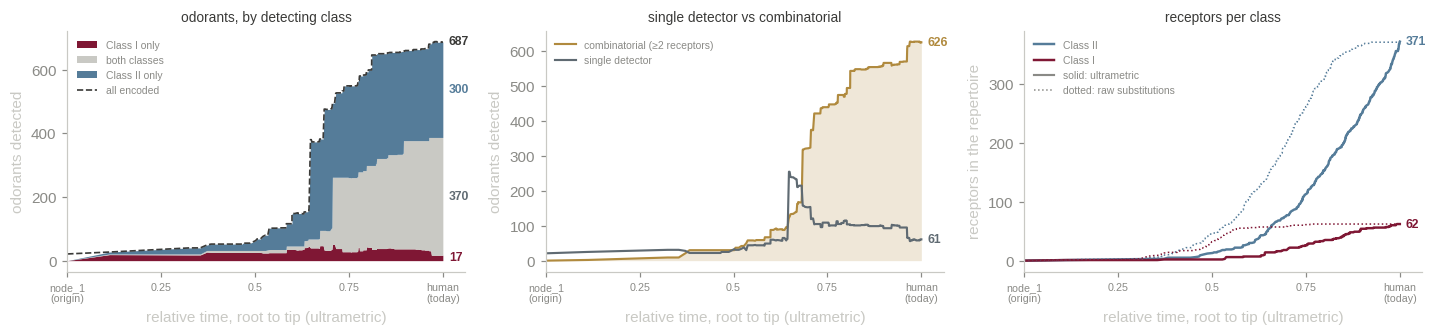

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(FIGSIZE[0] * 3.3, FIGSIZE[1] * 1.05))


def endlabel(ax, y, text, colour, dy=0.0):
    ax.annotate(text, xy=(1.0, y), xytext=(4, dy), textcoords="offset points",
                fontsize=8, fontweight="bold", color=colour, va="center")


# --- odorants, by detecting class -------------------------------------------
ax = axes[0]
t = traj.t.values
base = np.zeros(len(traj))
for col, colour, name in [("only_I", CLASS1_COL, "Class I only"),
                          ("both", BOTH_COL, "both classes"),
                          ("only_II", CLASS2_COL, "Class II only")]:
    ax.fill_between(t, base, base + traj[col].values, color=colour, lw=0, label=name)
    base = base + traj[col].values
ax.plot(t, traj.n_detected, color=TOTAL_COL, lw=1.1, ls="--", label="all encoded")
last = traj.iloc[-1]
endlabel(ax, last.n_detected, f"{int(last.n_detected)}", TOTAL_COL)
endlabel(ax, last.only_I / 2, f"{int(last.only_I)}", CLASS1_COL)
endlabel(ax, last.only_I + last.both / 2, f"{int(last.both)}", COMMON_COL)  # grey band, darker text
endlabel(ax, last.only_I + last.both + last.only_II / 2, f"{int(last.only_II)}", CLASS2_COL)
ax.set_ylabel("odorants detected")
ax.set_title("odorants, by detecting class", fontsize=9, color="#3a3a38")
ax.legend(frameon=False, fontsize=6.8, loc="upper left")

# --- single vs combinatorial -------------------------------------------------
ax = axes[1]
ax.fill_between(t, 0, traj.n_combinatorial, color=COMB_COL, alpha=0.20, lw=0)
ax.plot(t, traj.n_combinatorial, color=COMB_COL, lw=1.4, label="combinatorial (≥2 receptors)")
ax.plot(t, traj.n_single, color=SINGLE_LINE, lw=1.4, label="single detector")
endlabel(ax, last.n_combinatorial, f"{int(last.n_combinatorial)}", COMB_COL)
endlabel(ax, last.n_single, f"{int(last.n_single)}", SINGLE_LINE)
ax.set_ylabel("odorants detected")
ax.set_title("single detector vs combinatorial", fontsize=9, color="#3a3a38")
ax.legend(frameon=False, fontsize=6.8, loc="upper left")

# --- receptors per class, on both axes ---------------------------------------

ax = axes[2]
for frame, style, width in [(traj, "-", 1.6), (traj_raw, ":", 1.0)]:
    ax.plot(frame.t, frame.n_class_II, color=CLASS2_COL, ls=style, lw=width)
    ax.plot(frame.t, frame.n_class_I, color=CLASS1_COL, ls=style, lw=width)
endlabel(ax, last.n_class_II, f"{int(last.n_class_II)}", CLASS2_COL)
endlabel(ax, last.n_class_I, f"{int(last.n_class_I)}", CLASS1_COL)
ax.set_ylabel("receptors in the repertoire")
ax.set_title("receptors per class", fontsize=9, color="#3a3a38")
ax.legend(handles=[Line2D([], [], color=CLASS2_COL, lw=1.6, label="Class II"),
                   Line2D([], [], color=CLASS1_COL, lw=1.6, label="Class I"),
                   Line2D([], [], color="#8a8a86", lw=1.4, ls="-", label="solid: ultrametric"),
                   Line2D([], [], color="#8a8a86", lw=1.0, ls=":", label="dotted: raw substitutions")],
          frameon=False, fontsize=6.8, loc="upper left")

for ax in axes:
    ax.set_xlim(0, 1.06)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(["node_1\n(origin)", "0.25", "0.5", "0.75", "human\n(today)"], fontsize=7)
    ax.set_xlabel("relative time, root to tip (ultrametric)")

plt.tight_layout()
save_fig(fig, "07_code_growth")
plt.show()

## What reproduces, and what does not

Everything above comes from this repository's code. Against the plan's published table:

- **The endpoint matches exactly** — 62 + 371 receptors, 687 odorants detected, 61 single
  detector, 626 combinatorial, and the 17 / 370 / 300 partition. That last agreement is
  the meaningful one: it closes on the extant-matrix partition of the extant matrix, computed a
  completely different way.
- **The stage figure matches exactly** at both cuts — 177/0, 189+27, 133+132 raw, and
  21/0, 25+2, 36+17 calibrated.
- **The intermediate checkpoints match on every odorant column at t = 0, 0.75, 0.83 and
  0.90**, and drift by a few receptors. The `t = 0.96` column differs more (666 vs 678
  detected). That region is tie-dense — 21 node times fall within 0.01 of it — so the
  counts move sharply with the exact sample point; evaluating at 0.965 instead gives
  57 + 318 and 680 detected, essentially the plan's column. It is a rounding difference in
  where the column was sampled, not a disagreement about method.

## What these two figures do and do not support

**They support:** a combinatorial code requires no selective explanation. One receptor
cannot make one; two can, and 7.4% of what they detect is already read by both. By three
receptors it is 32%. Duplication of a broadly-tuned ancestor produces this for free.

**They do not support** — and the plan is explicit about each:

- that no selection occurred. Absence of a *need* for selection is not absence of selection.
- that the code *grew more* combinatorial over evolution in any interesting sense. Beyond
  ~50 receptors the observed fraction is *below* what independent rows of the same breadths
  would force. The rise is arithmetic.
- that labelled lines are a transient the growing repertoire eliminates. The fall in single
  detectors is produced by a handful of hyper-broad rows; blanking rows above 100 odorants
  turns 219 → 61 into 168 → 154.
- that "labelled line at S2" is a property of the molecule. 97% of those odorants are
  combinatorially encoded in the extant code.
- anything about **when** the classes reached their relative sizes. The two axes in panel 3
  bracket it and a human-only tree cannot narrow it.

Set sizes here are small — S1 detects 27 odorants and S2 detects 53 — so no chemistry or
odour-descriptor claim about these stages survives multiple-testing correction. `06`'s
composition null is the companion check: it reproduces the class-overlap shape by
resampling extant receptors, with no tree involved.

---
## What this shows

**The code appears at the first duplication.** At one receptor (`node_1`) no odorant can be
read combinatorially, by definition. At two (`node_2`, `node_3`) some already are, and the
fraction rises at every duplication after it. No selection for combinatoriality is required
— it is what having more than one broadly tuned receptor produces.

**The two duplicates diverged into different chemistry.** Class I took carboxylic acids;
class II kept and enriched aromatics. The near-perpendicular shift is the quantitative form
of that statement, and it survives leave-one-descriptor-out, whitening, PERMANOVA, and
regressing acid and aromatic character out of all 13 descriptors.

**What not to quote.** The intermediate odorant counts along the trajectory are an estimator
with real variance — a single hyper-broad reconstructed lineage entering the slice moves
them by tens. The endpoints are solid; the shape is solid; the intermediate integers are not.